# Notebook 7 — Descriptive Analysis

## Purpose

This notebook produces all descriptive statistics and visualisations for the study population, using the final cleaned dataset (`df_final_binaire_imputed.csv`). Outputs are saved to `Results/Description/` and feed directly into the thesis report and scientific poster.

---

## Pipeline Overview

### 1. Setup and data loading
Global matplotlib styling (white background, 150 dpi) is configured. Binary columns (`is_*`, `has_*`, `had_*`) are cast to integer then category; `*_status` columns are normalised to string. Two derived columns are created: `triage_label` (Triage 1–5) and `ekg_label` (EKG / No EKG). Age groups (15–30, 31–45, 46–60, 61–75, 75+) are computed from the continuous `age` variable if not already present.

### 2. Data completeness hierarchy (Great Tables)
A formatted summary table reports, for each clinical parameter (vital signs, lab, imaging, EKG), the proportion of patients with a recorded measurement. Parameters are sorted by decreasing completeness and exported as both HTML and CSV.

### 3. Quantitative variable distributions
For every continuous numeric variable, a paired histogram + boxplot is generated and saved as PNG, enabling visual detection of outliers and distributional assumptions.

### 4. Categorical and status variable distributions
Horizontal bar charts are produced for all `_status`, `is_*`, and key pathway variables (`transport_grouped`, `chief_complaint_en`, `diag`, `disposition`), colour-coded by variable type.

### 5. Clinical validation: triage × disposition
A stacked bar chart cross-tabulates triage level (1 = most urgent) against the harmonised `disposition` outcome, serving as a sanity check that clinical logic is preserved in the final dataset (e.g., Triage 1–2 patients should predominantly be hospitalised).

### 6. Imaging and biology summaries (Great Tables)
Separate formatted tables detail the breakdown of imaging examination types (among patients with `has_imaging_any = 1`) and biological test types (among patients with `is_labo = 1`), with counts and percentages relative to the relevant patient subgroup.

# Descriptive Analysis #


In [80]:
# ==============================================================================
# SETUP — Imports, configuration, output directory
# ==============================================================================
import os
import re
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.graph_objects as go
from IPython.display import display
from great_tables import GT, html, style, loc
from tableone import TableOne

import kaleido
# ── Output directory ──────────────────────────────────────────────────────────
output_dir = "Results/Description"
os.makedirs(output_dir, exist_ok=True)

# ── Global matplotlib style (white background everywhere) ─────────────────────
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'savefig.facecolor': 'white',
    'savefig.dpi'      : 150,
    'savefig.bbox'     : 'tight',
})

# ── Column constants ──────────────────────────────────────────────────────────
CHIEF_COMPLAINT_COL = 'chief_complaint_en'
sex_col             = 'sex'

# ── Shared palettes & orders (used across all cells) ─────────────────────────
age_order      = ['15-30', '31-45', '46-60', '61-75', '75+']
triage_order   = ['Triage 1', 'Triage 2', 'Triage 3', 'Triage 4', 'Triage 5']
palette_age    = ['#3498db', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
palette_triage = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60', '#2980b9']
palette_sex    = ['#e74c3c', '#3498db']   # F=red, M=blue
ekg_col        = 'had_ekg'
ekg_order      = [0, 1]
ekg_label_order = ['No EKG', 'EKG']
palette_ekg    = ['#95a5a6', '#e74c3c']

print(f"✅ Setup done — outputs → {output_dir}")


✅ Setup done — outputs → Results/Description


In [81]:
# ==============================================================================
# LOADING DATA
# ==============================================================================
df = pd.read_csv("Datasets/df_final_binaire_imputed.csv", sep=',', low_memory=False)

# ── Binary columns (is_ / has_ / had) → int then category ───────────────────
binary_patterns = ['is_', 'has_', 'had']
for col in df.columns:
    if any(p in col for p in binary_patterns):
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int).astype('category')

# ── is_*_measured → int (not category) ──────────────────────────────────────
measured_cols = [c for c in df.columns if 'is_' in c.lower() and 'measured' in c.lower()]
for col in measured_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# ── *_status → string, NaN → 'Unknown' ──────────────────────────────────────
status_cols = [c for c in df.columns if '_status' in c.lower()]
for col in status_cols:
    df[col] = df[col].astype(str).replace('nan', 'Unknown')

# ── Derived columns ──────────────────────────────────────────────────────────
df['triage_label'] = 'Triage ' + df['triage'].astype(int).astype(str)
df['ekg_label']    = df['had_ekg'].astype(int).map({0: 'No EKG', 1: 'EKG'})

if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(
        df['age'],
        bins=[14, 30, 45, 60, 75, 120],
        labels=['15-30', '31-45', '46-60', '61-75', '75+'],
        right=True
    )

sex_order = sorted(df[sex_col].dropna().unique().tolist())

print(f"✅ Data loaded: {len(df):,} patients, {df.shape[1]} variables")
print(f"   age_group distribution:\n{df['age_group'].value_counts().sort_index().to_string()}")


✅ Data loaded: 56,784 patients, 191 variables
   age_group distribution:
age_group
15-30    17815
31-45    12116
46-60     9604
61-75     8090
75+       9159


GT(_tbl_data=                   variable             no            yes  total
0   Systolic Blood Pressure  14327 (25.2%)  42457 (74.8%)  56784
1                Heart Rate  14407 (25.4%)  42377 (74.6%)  56784
3             O2 Saturation  14518 (25.6%)  42266 (74.4%)  56784
2               Temperature  15262 (26.9%)  41522 (73.1%)  56784
5        Glasgow Coma Scale  17860 (31.5%)  38924 (68.5%)  56784
6                Pain Score  20058 (35.3%)  36726 (64.7%)  56784
8                 Lab Tests  23023 (40.5%)  33761 (59.5%)  56784
9                   Imaging  27258 (48.0%)  29526 (52.0%)  56784
10                      EKG  40860 (72.0%)  15924 (28.0%)  56784
4          Respiratory Rate  46318 (81.6%)  10466 (18.4%)  56784
7                   Hemocue  55144 (97.1%)    1640 (2.9%)  56784, _body=<great_tables._gt_data.Body object at 0x73598a8d5a90>, _boxhead=Boxhead([ColInfo(var='variable', type=<ColInfoTypeEnum.default: 1>, column_label='variable', column_align='left', column_width=None), ColInfo(var='no', type=<ColInfoTypeEnum.default: 1>, column_label='no', column_align='right', column_width=None), ColInfo(var='yes', type=<ColInfoTypeEnum.default: 1>, column_label='yes', column_align='right', column_width=None), ColInfo(var='total', type=<ColInfoTypeEnum.default: 1>, column_label='total', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7358b7afa1e0>, _spanners=Spanners([]), _heading=Heading(title='Data Completeness Hierarchy', subtitle='Measured Clinical Parameters', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7358b7c6b980>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7358b6b8fd10>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7358b1ac76e0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='white'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', valu

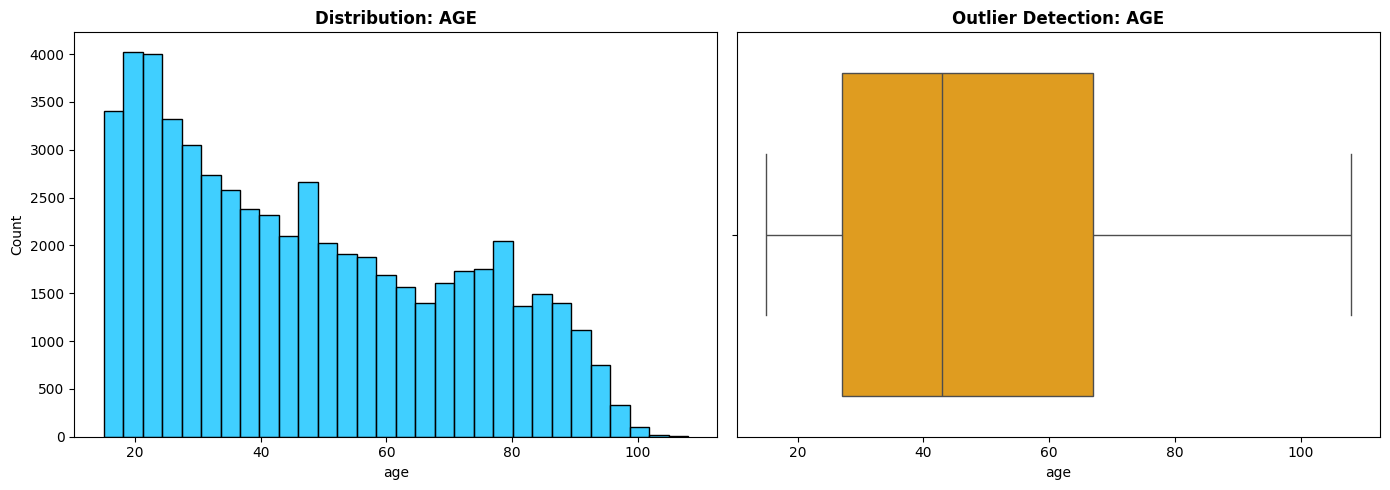

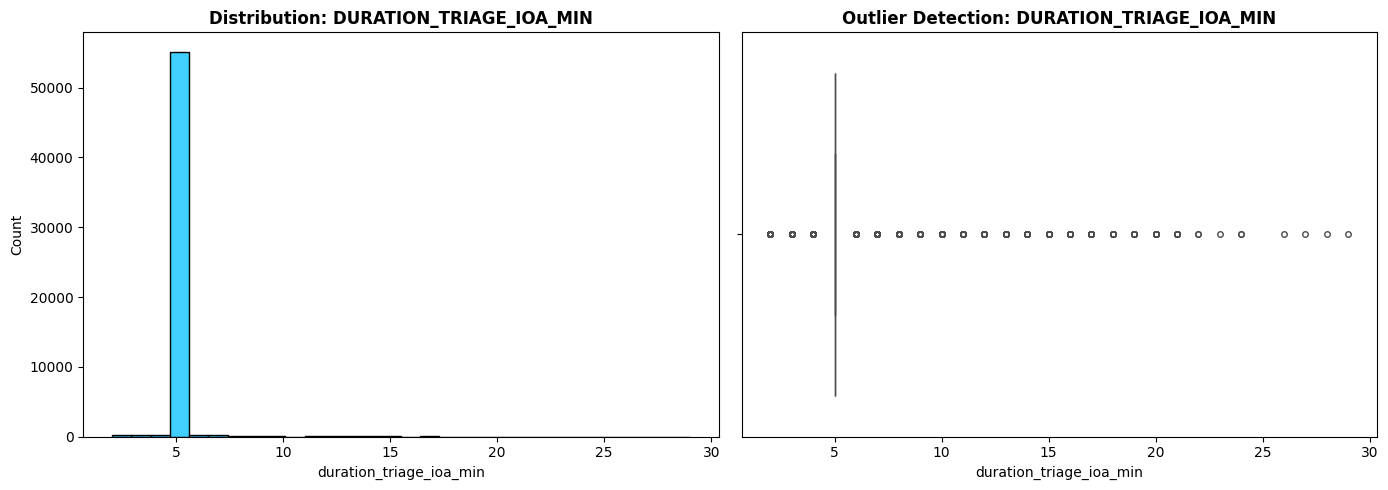

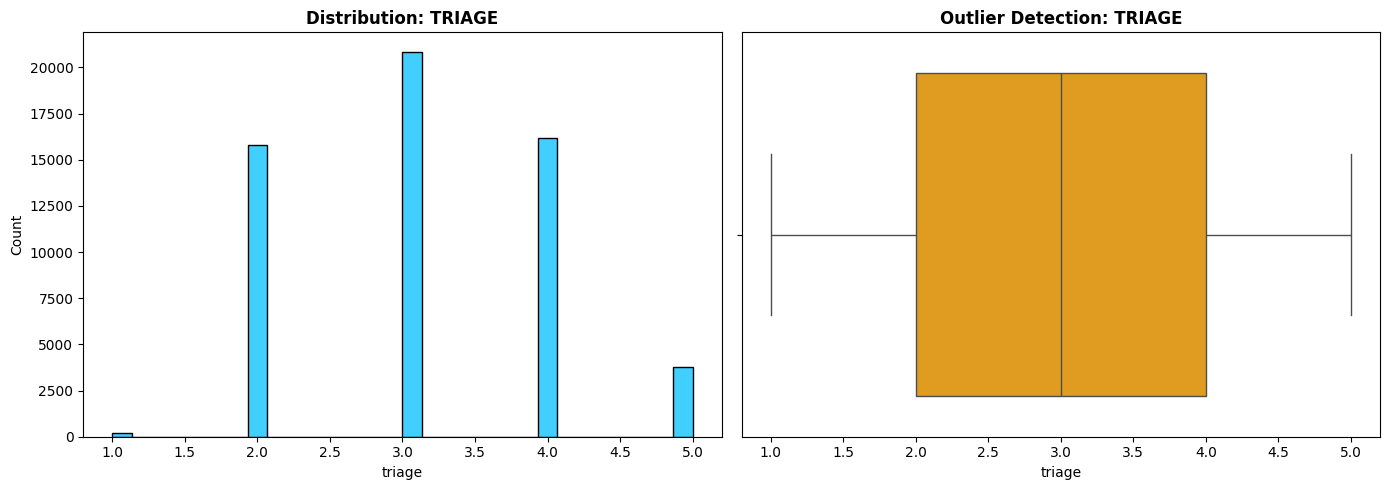

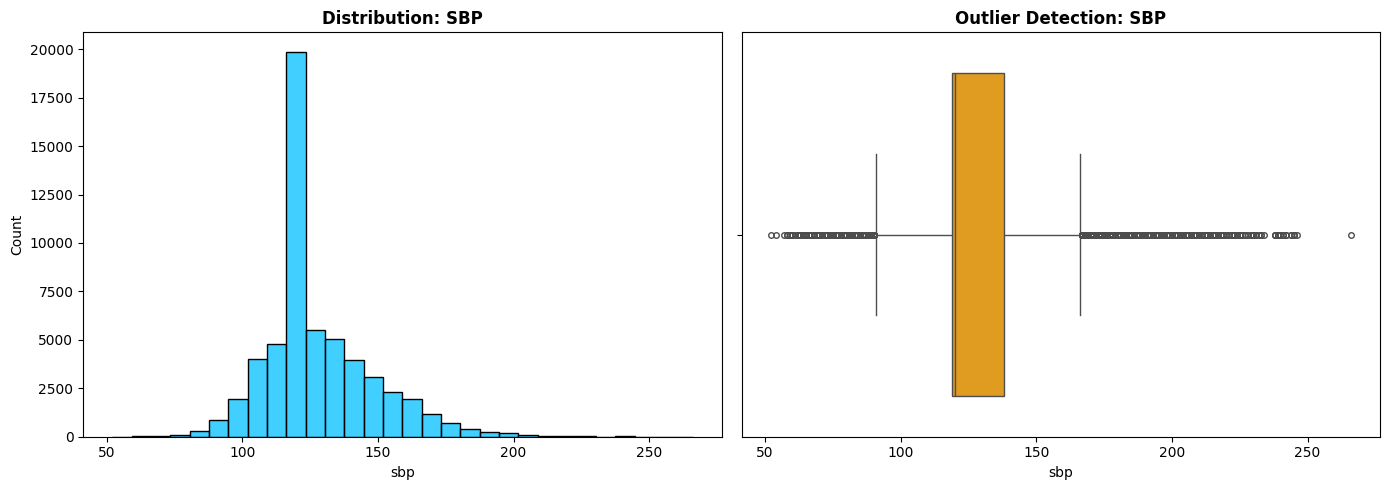

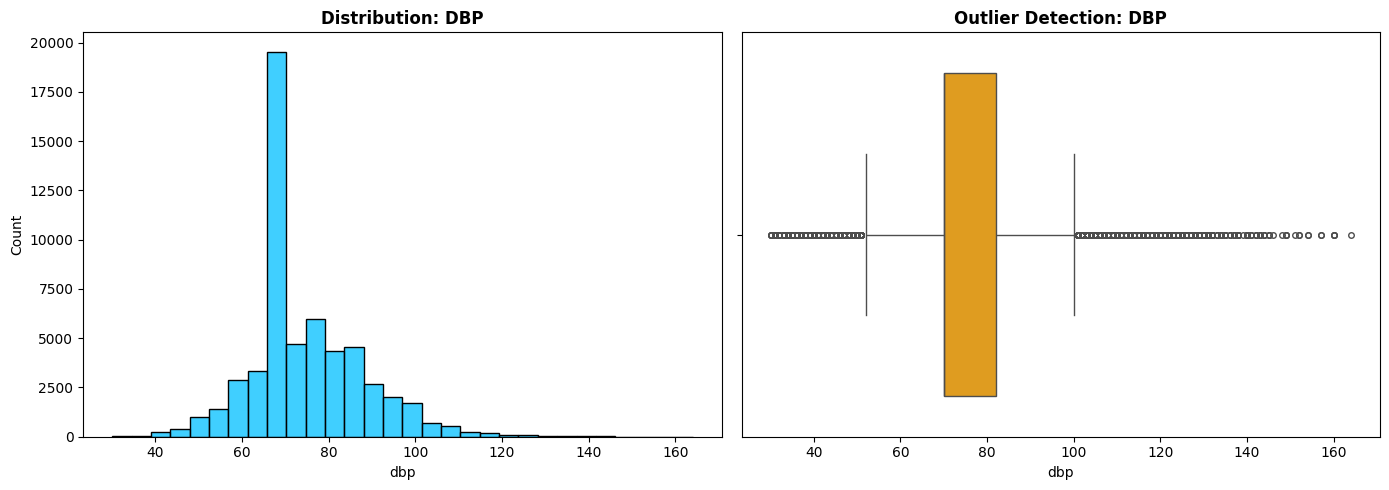

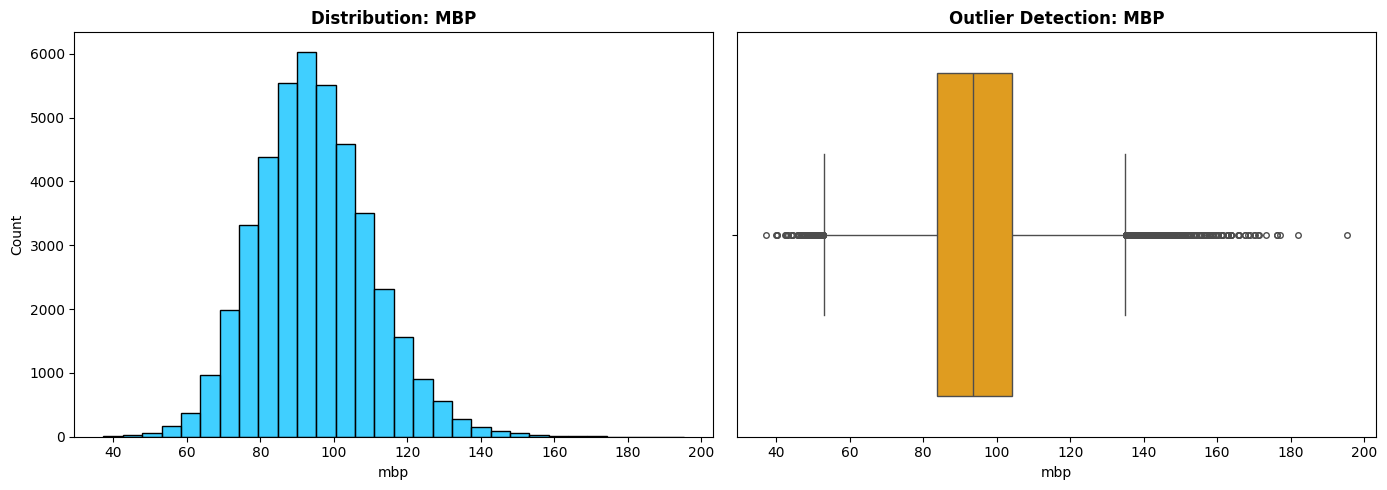

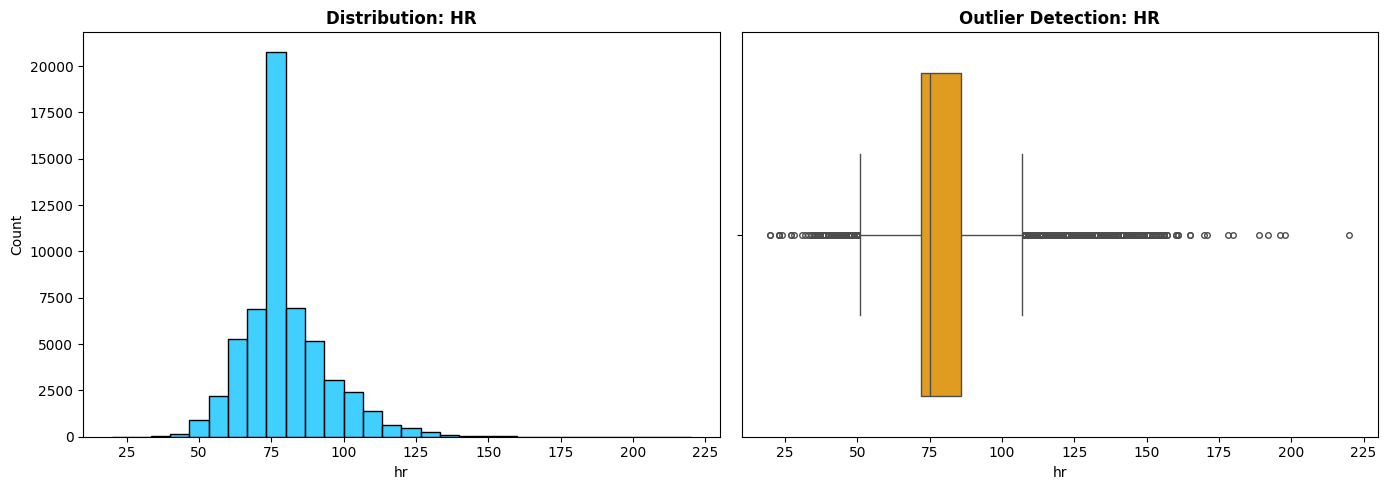

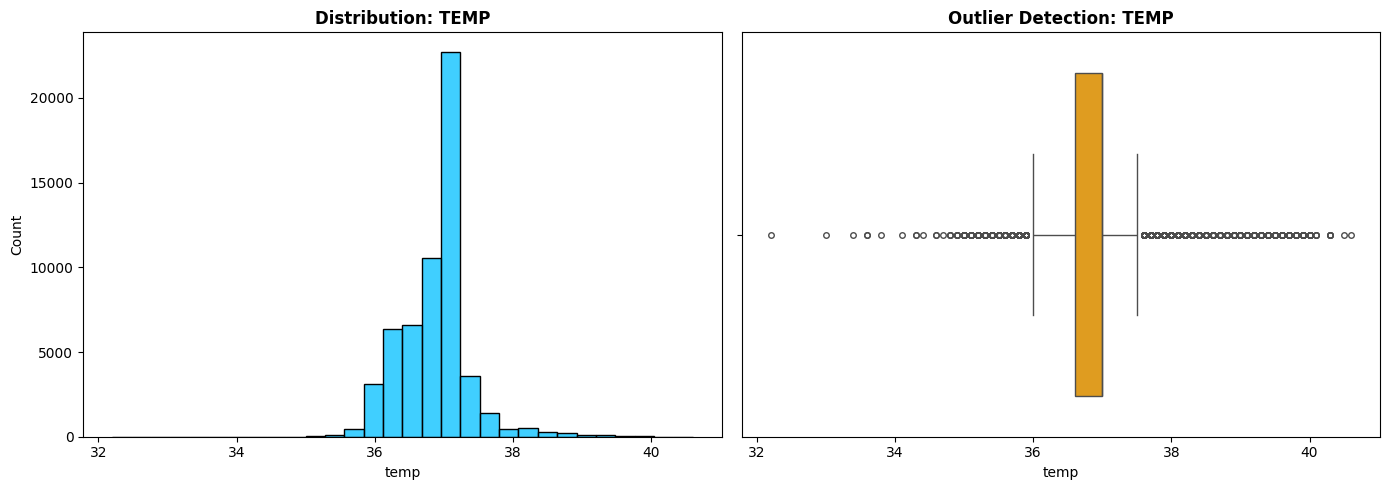

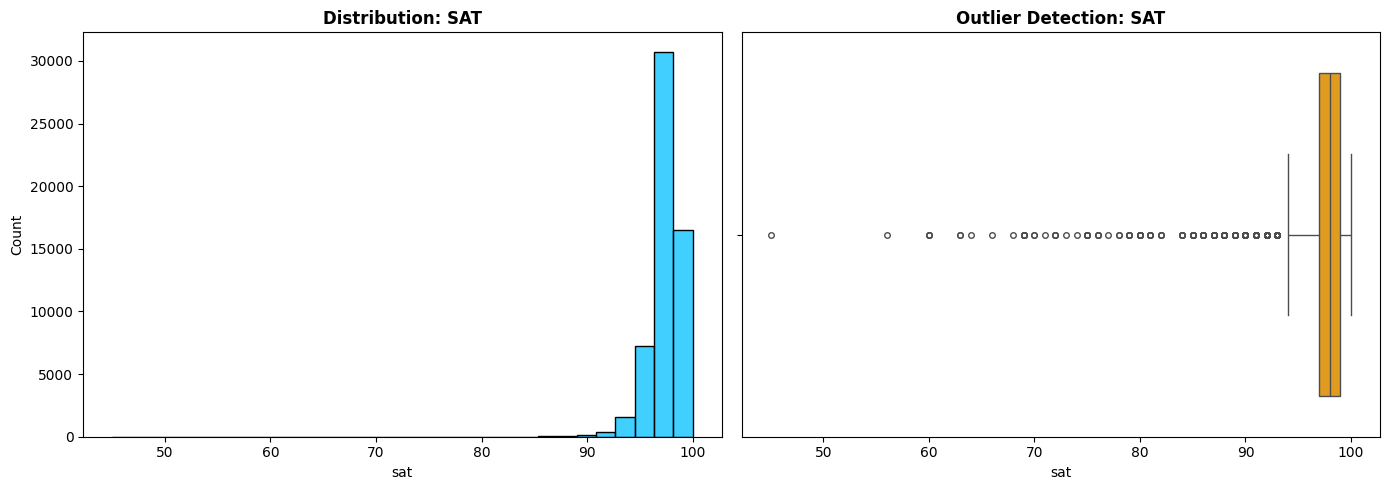

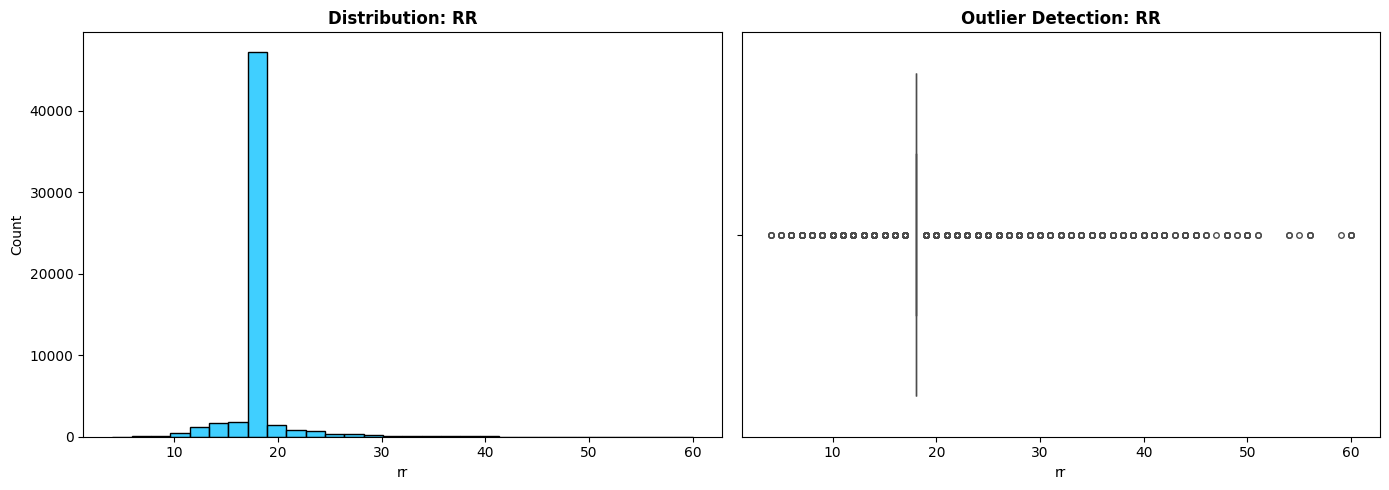

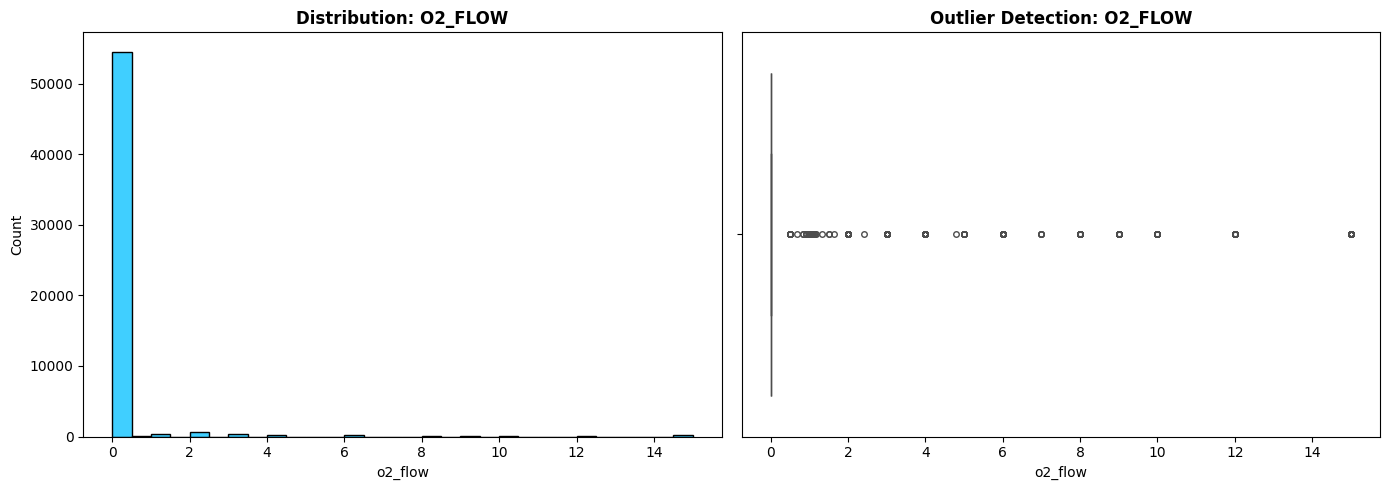

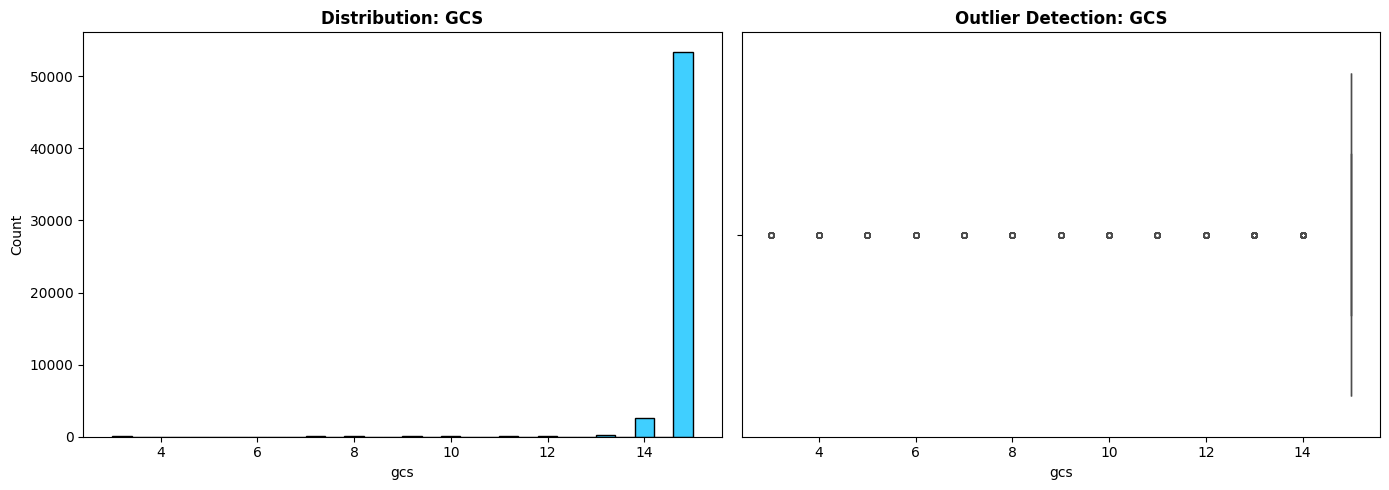

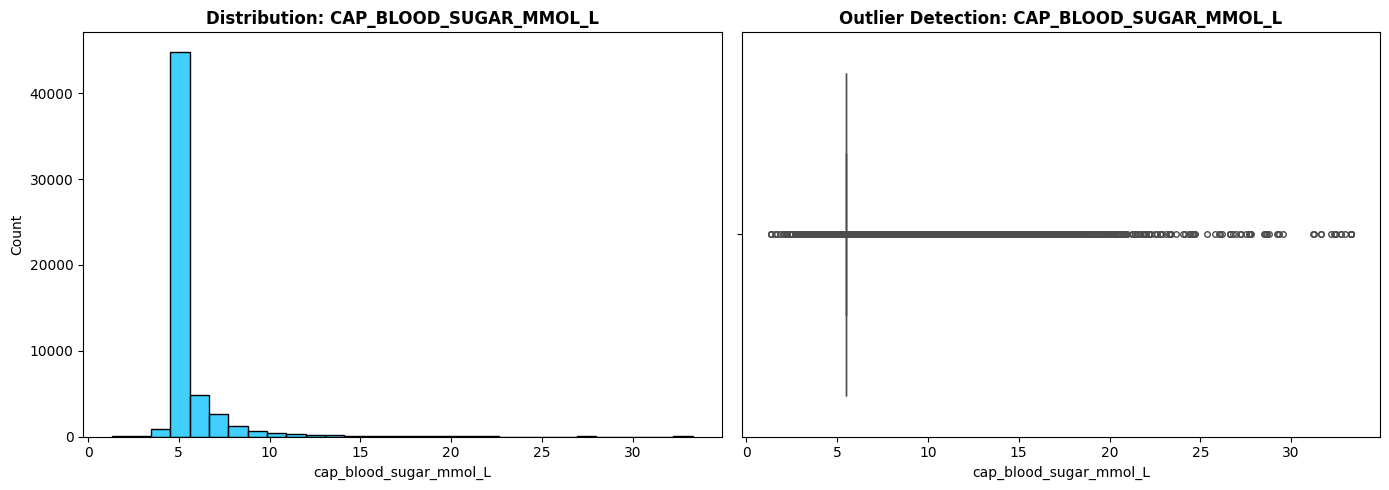

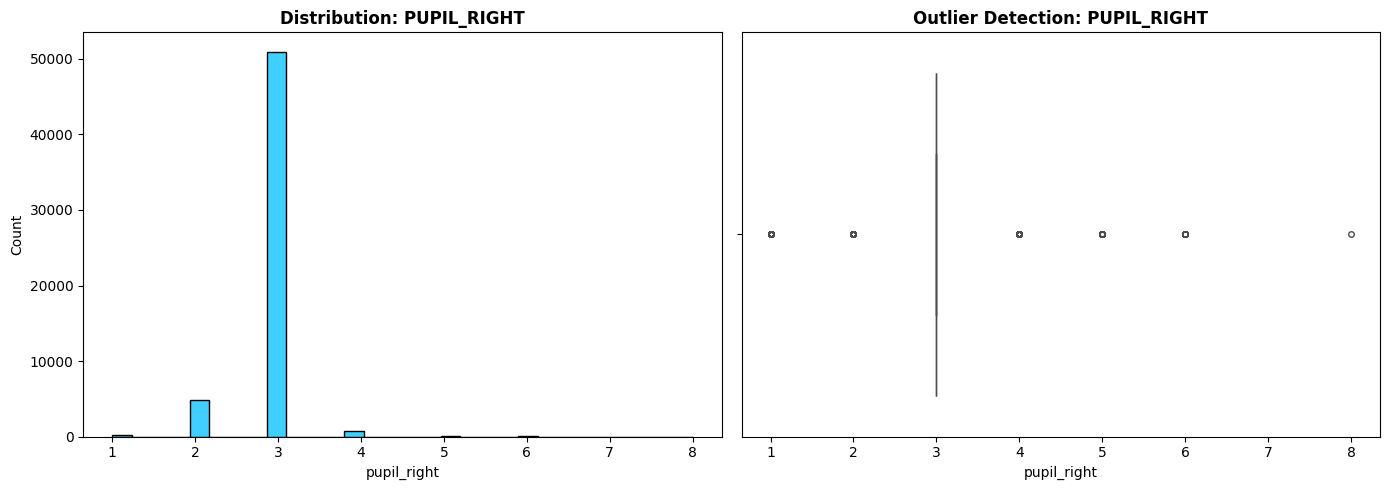

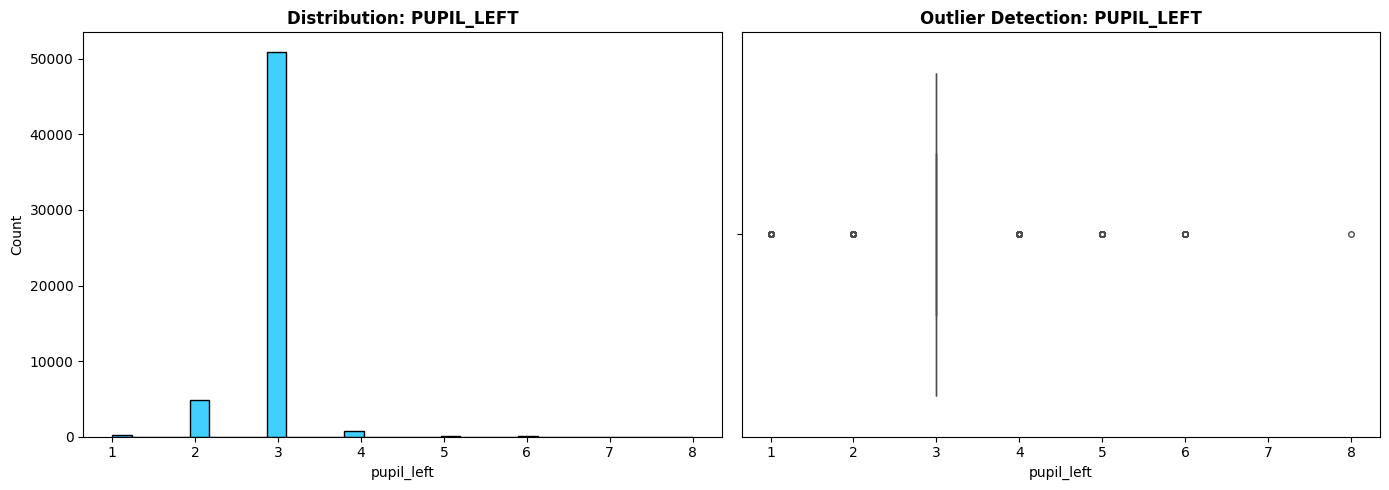

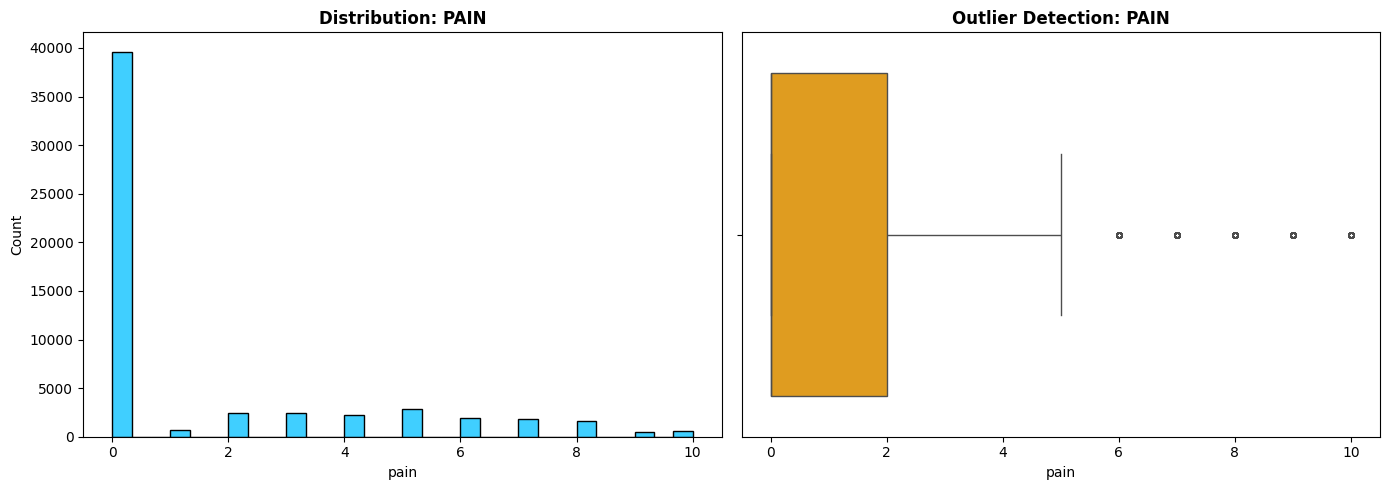

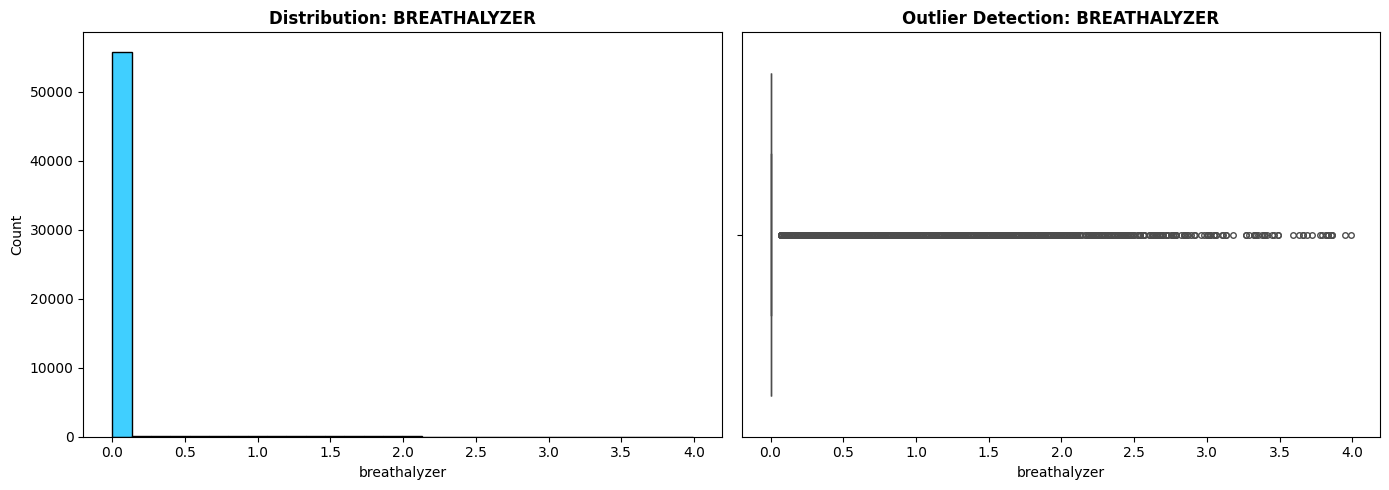

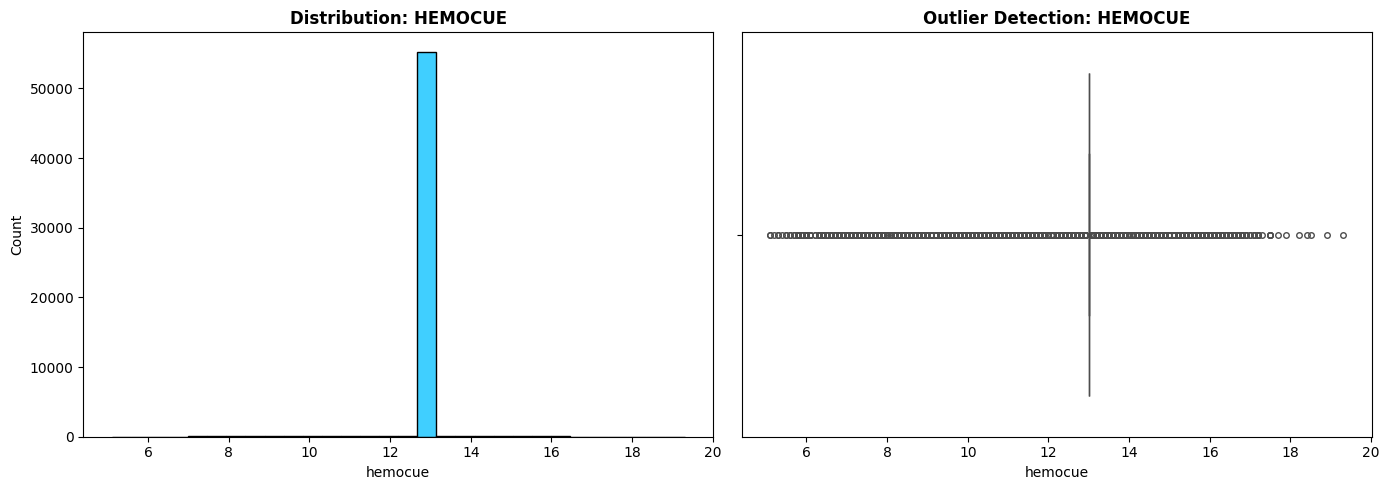

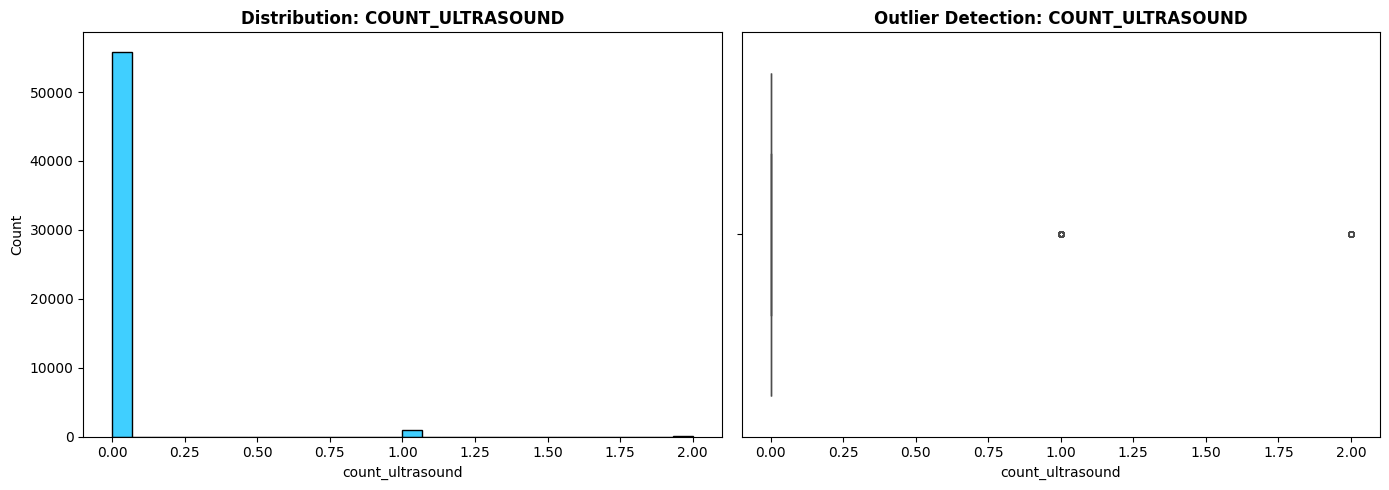

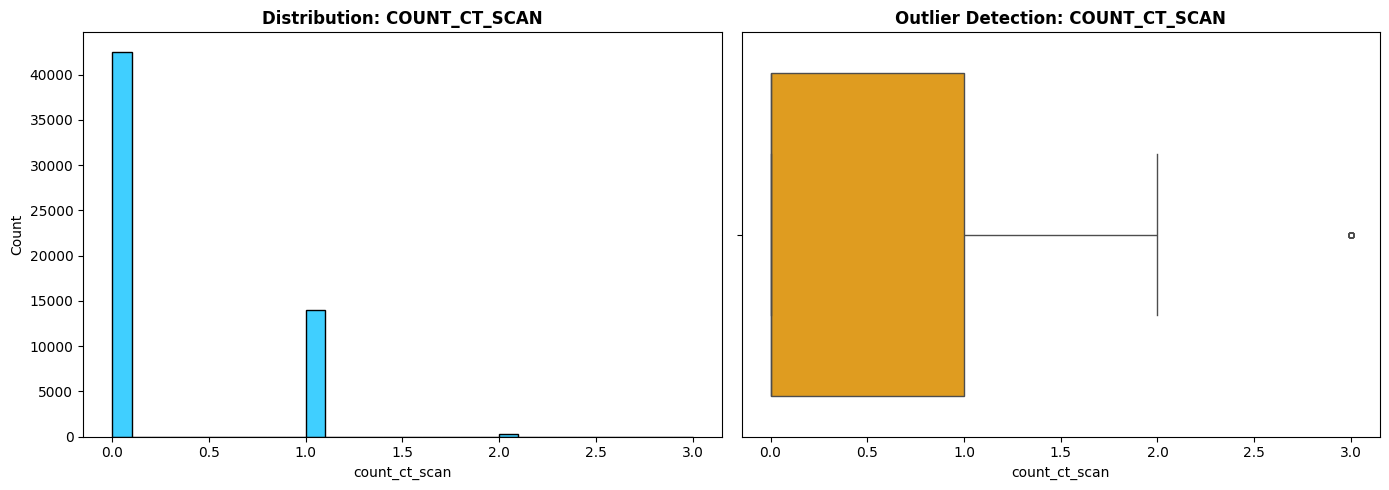

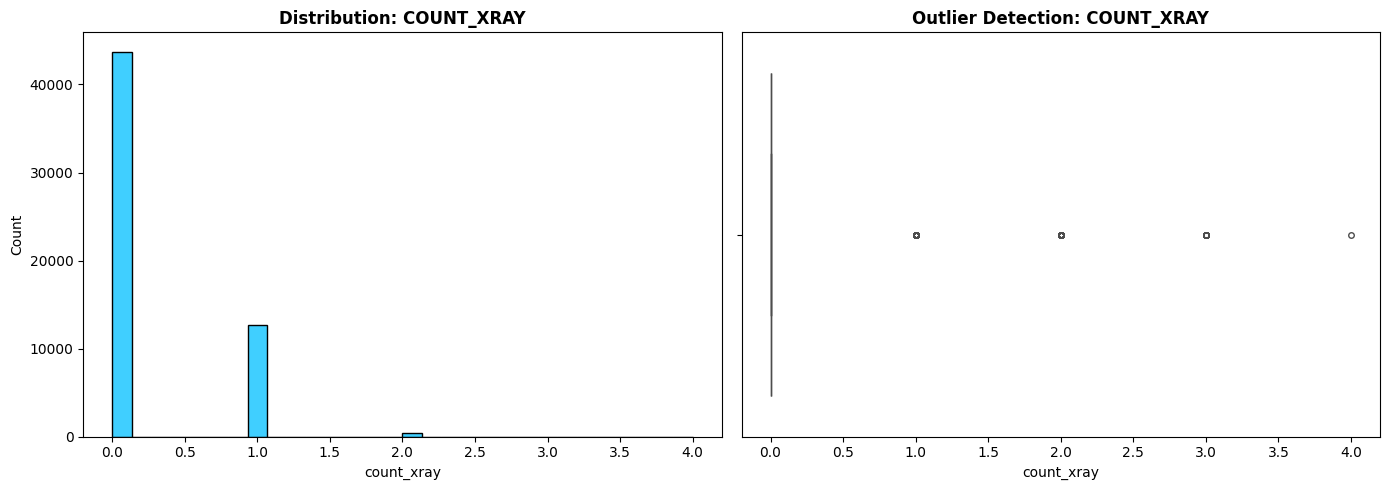

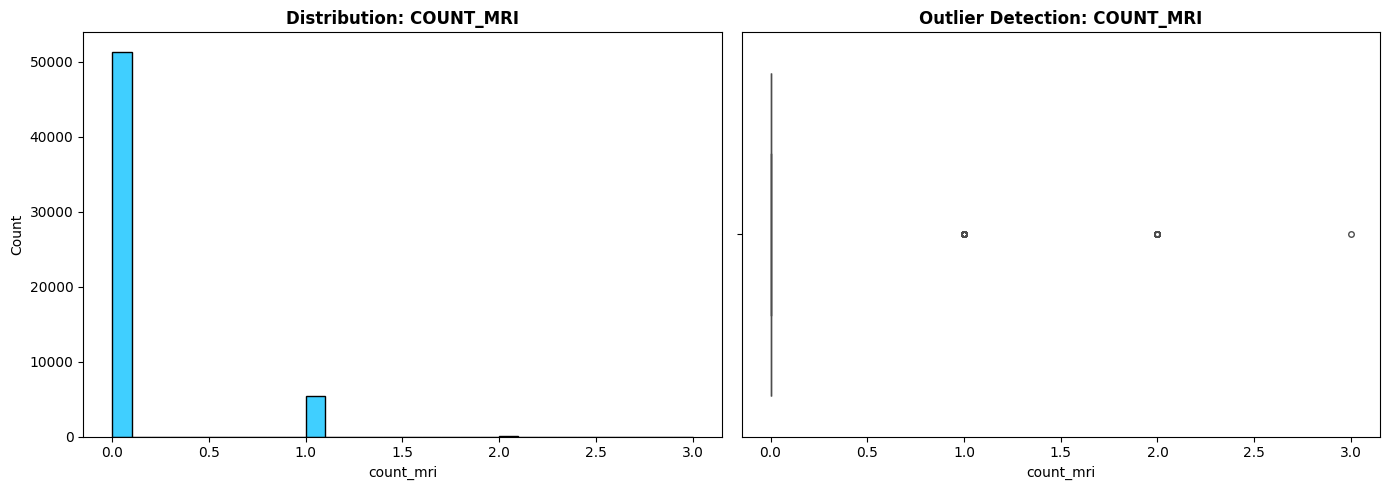

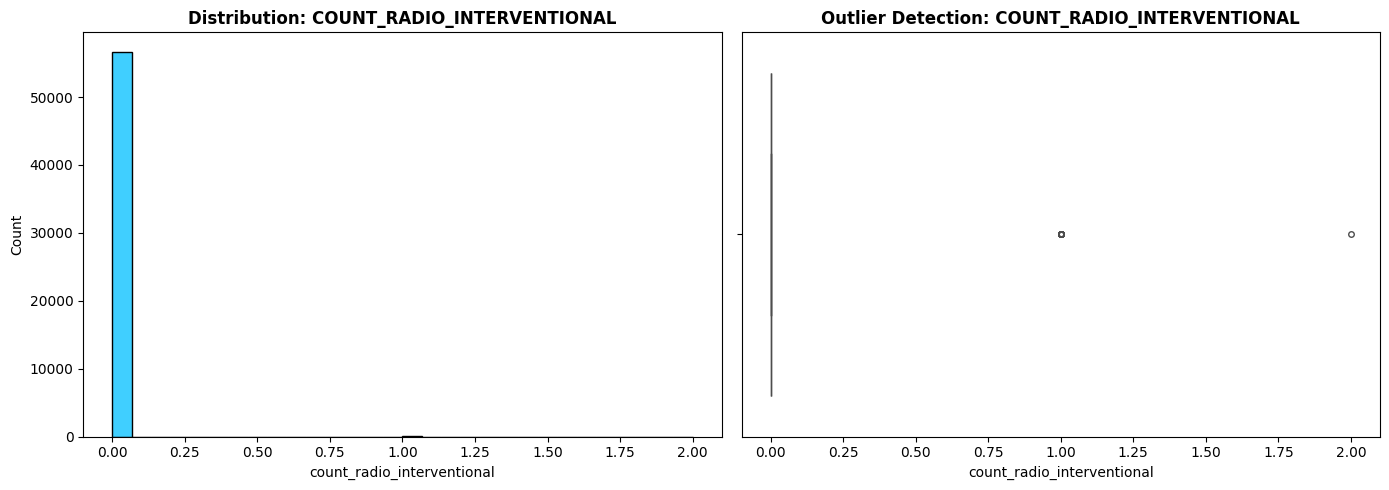

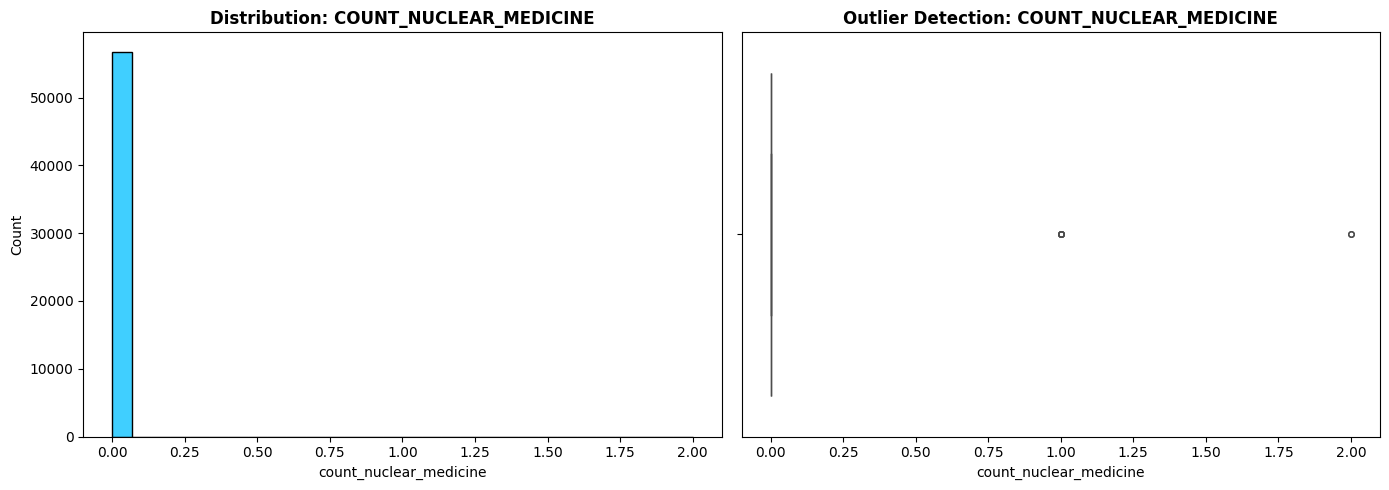

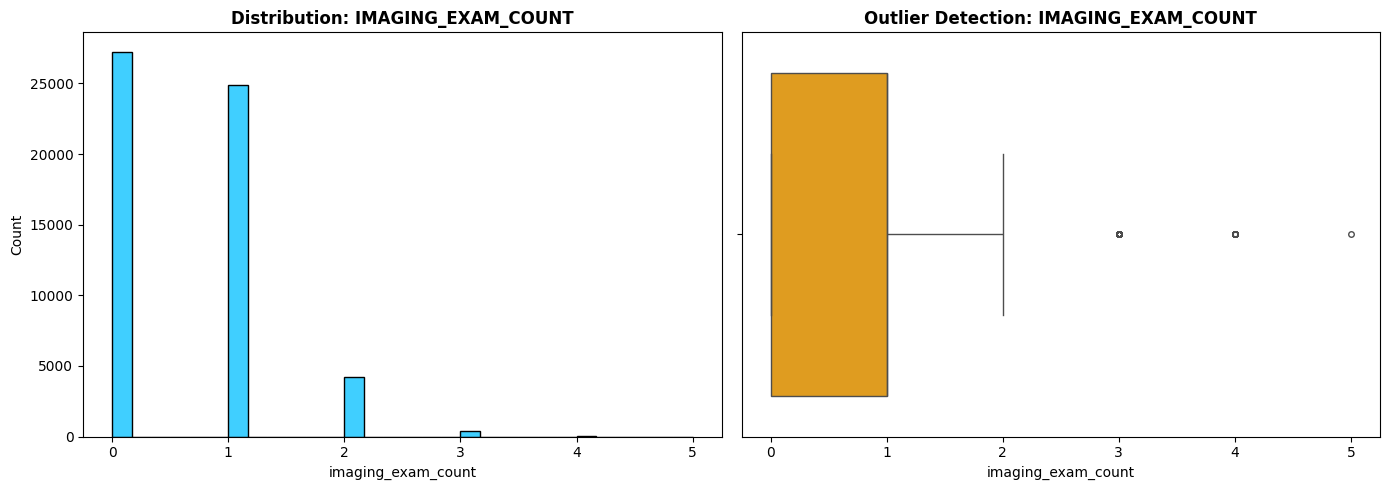

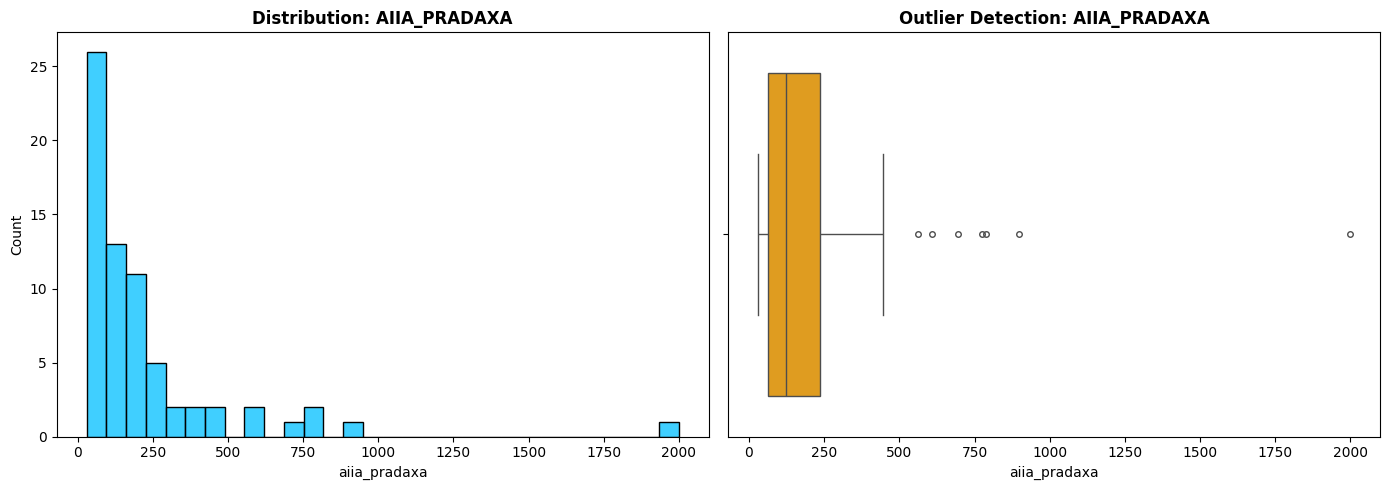

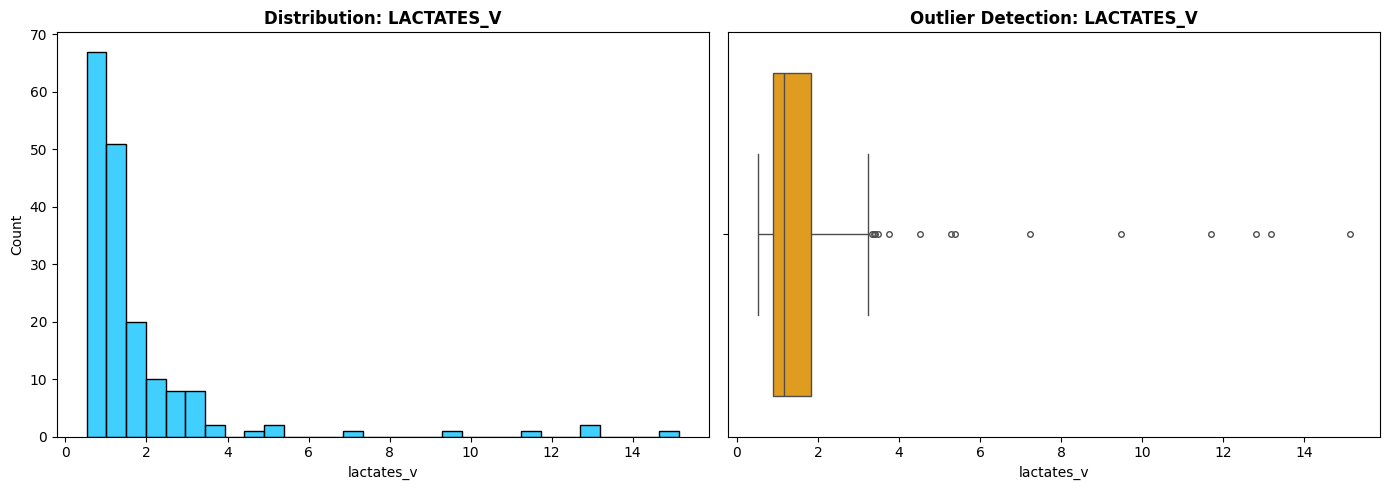

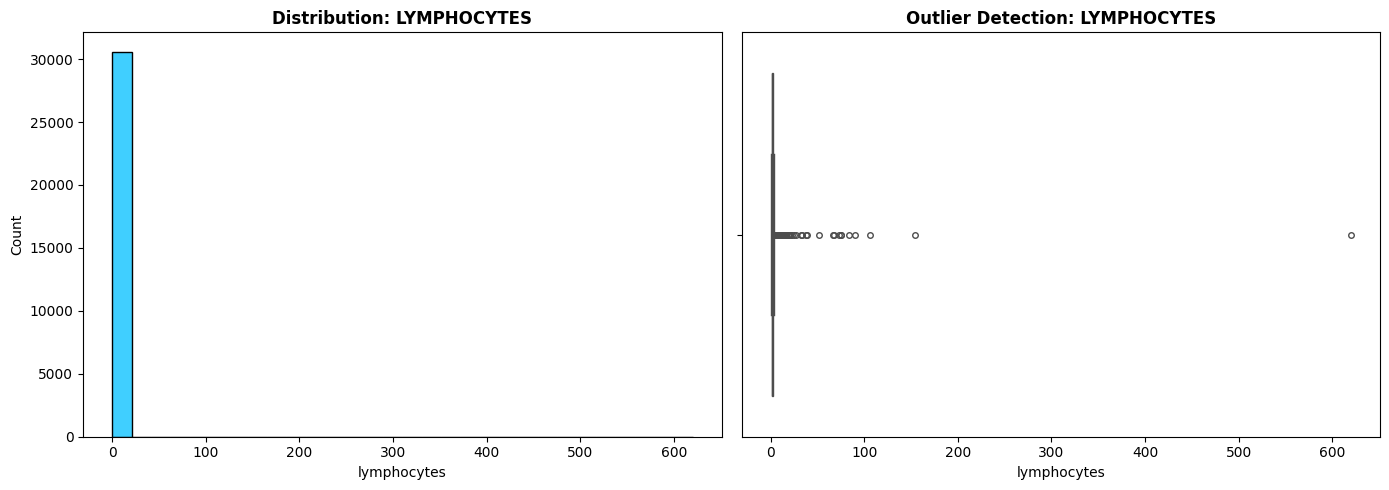

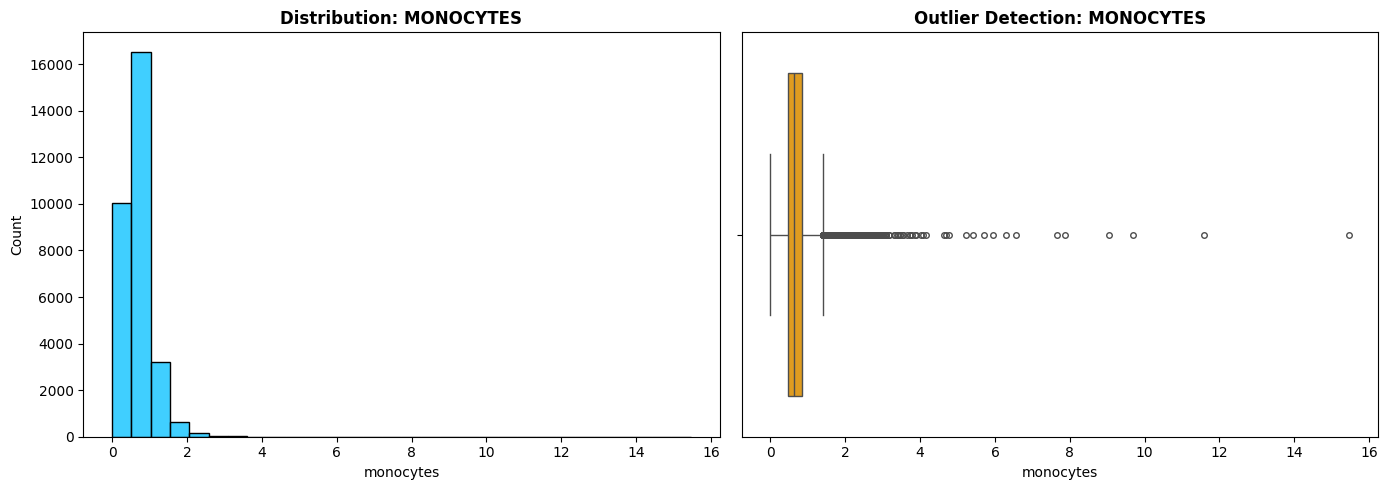

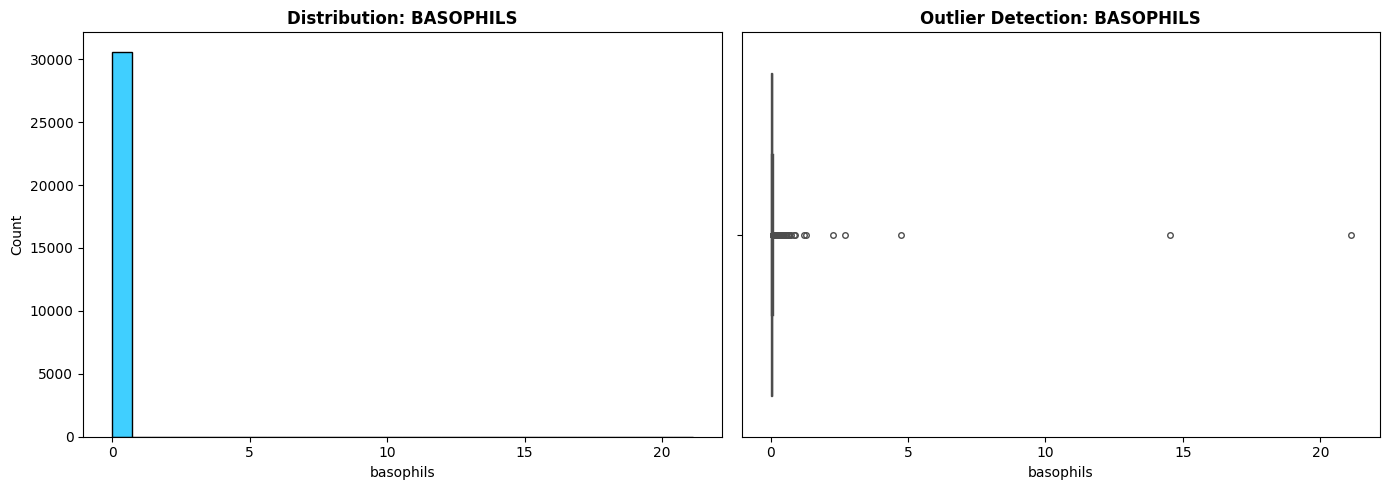

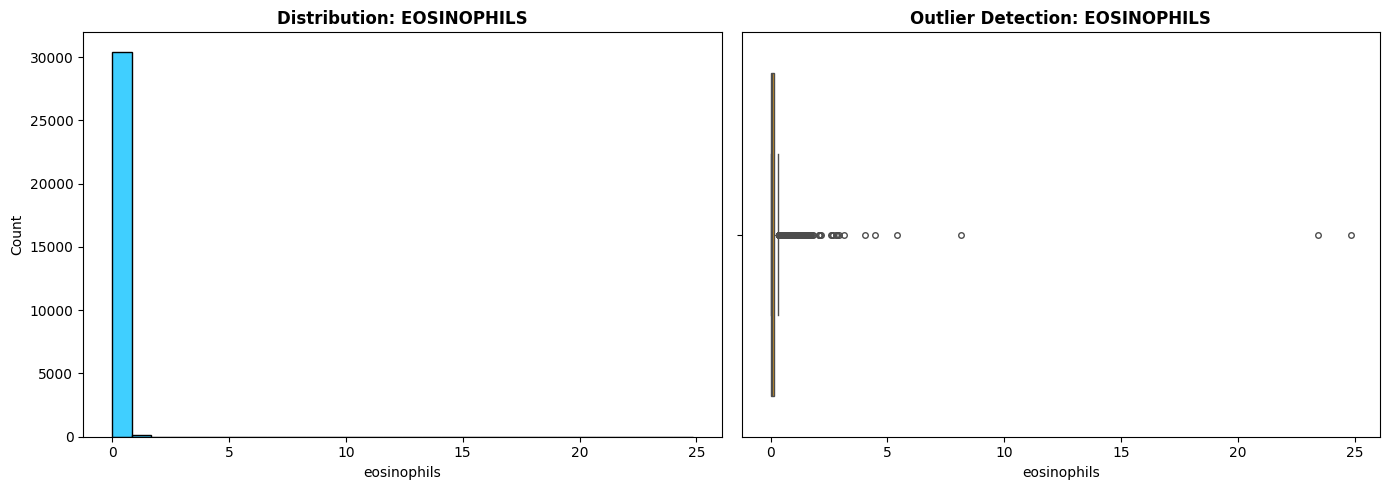

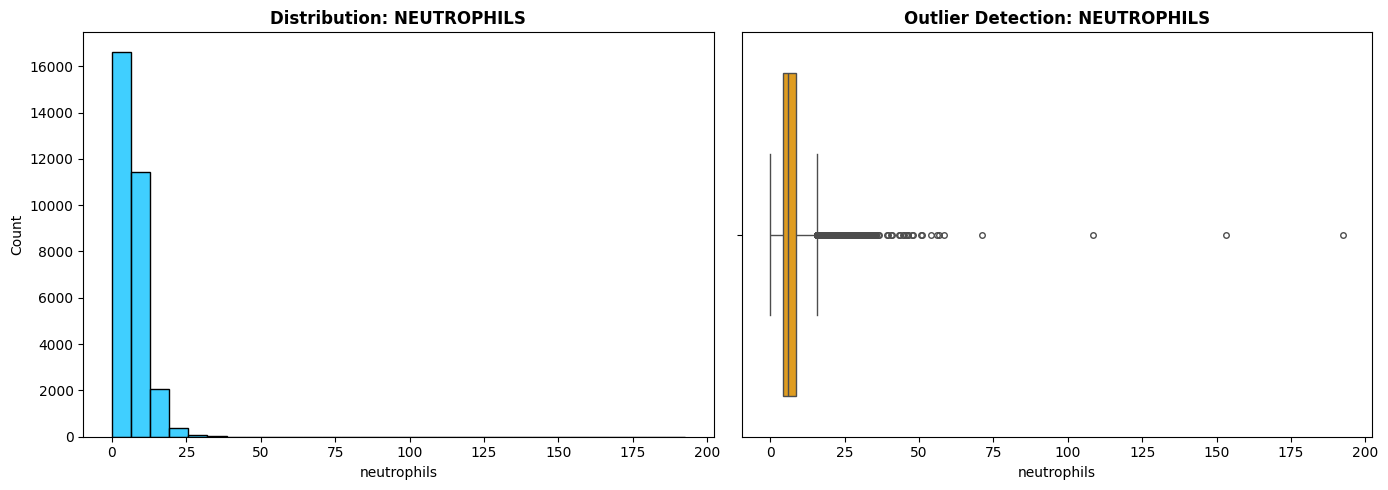

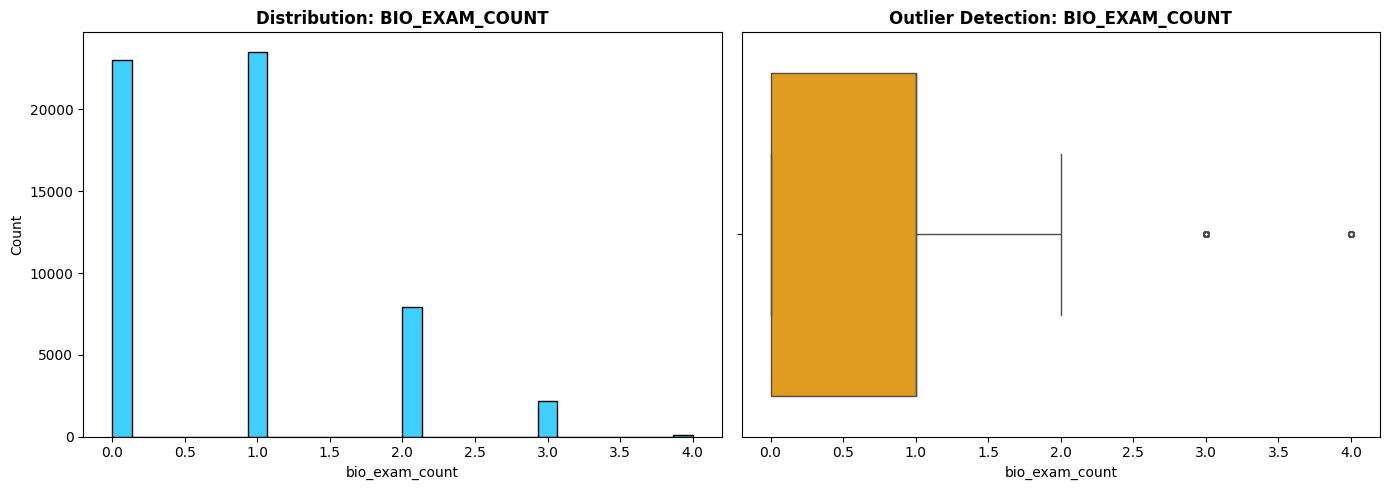

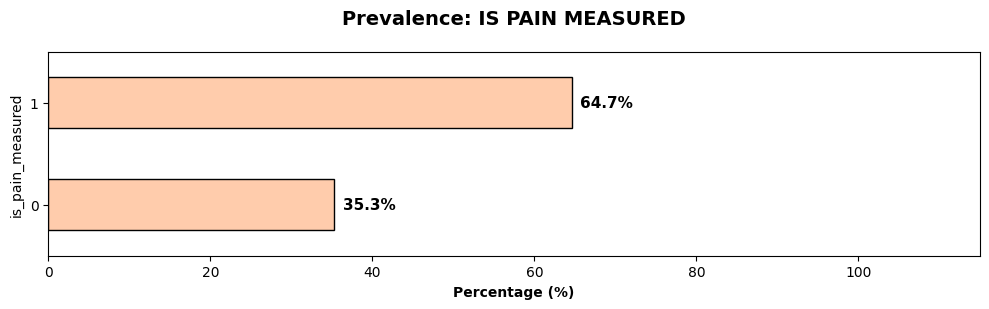

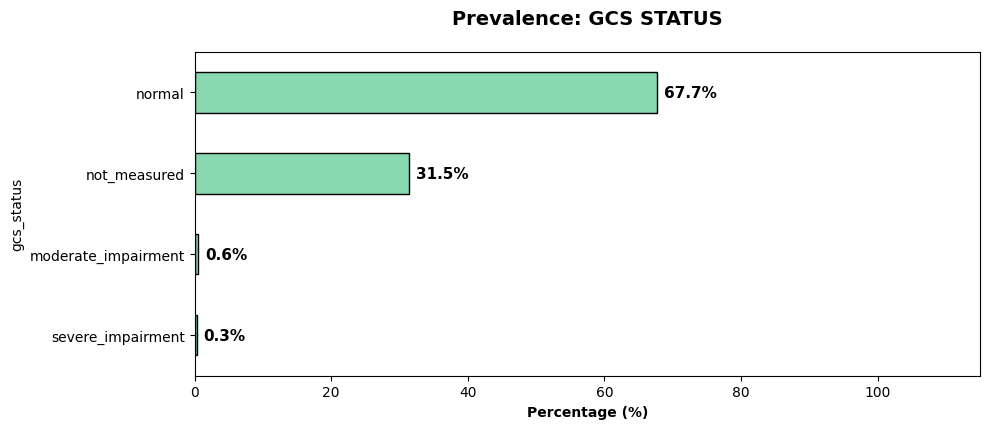

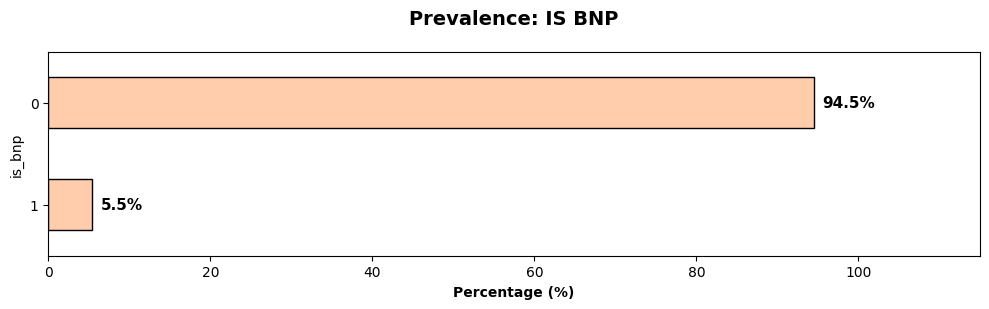

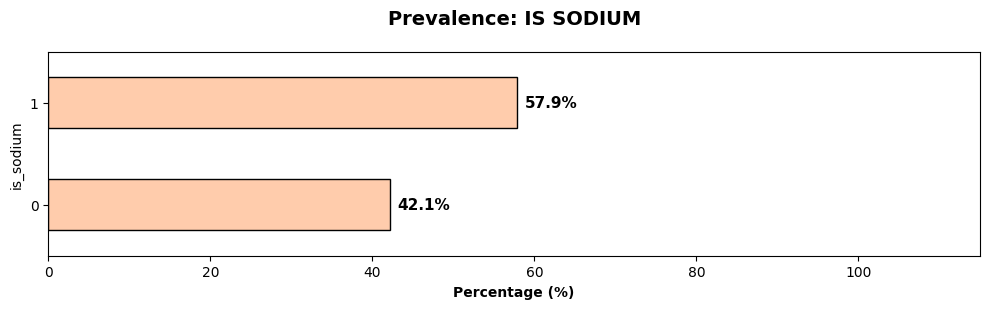

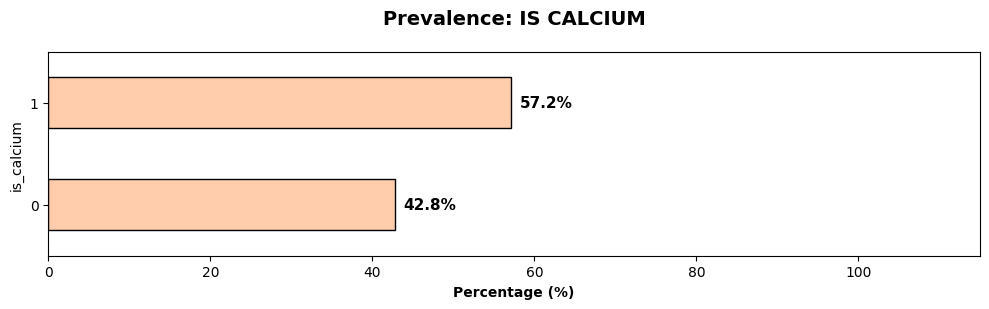

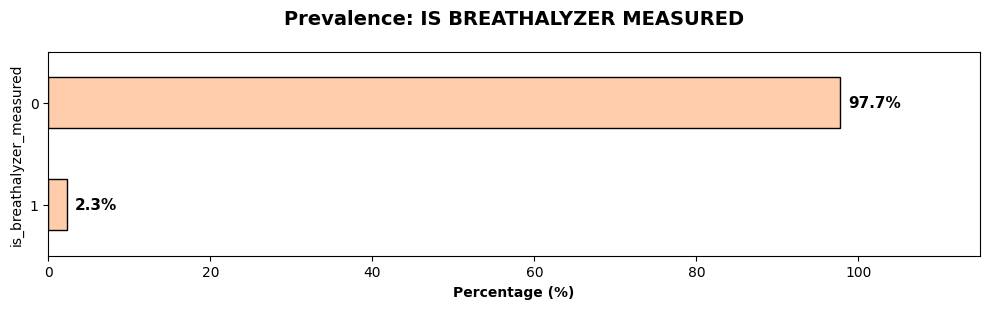

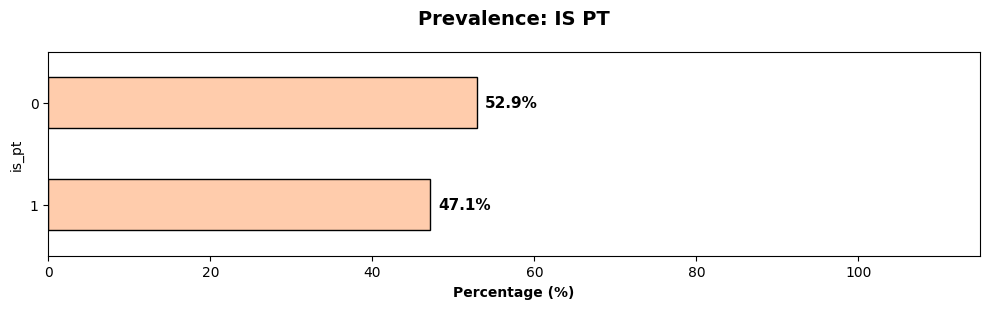

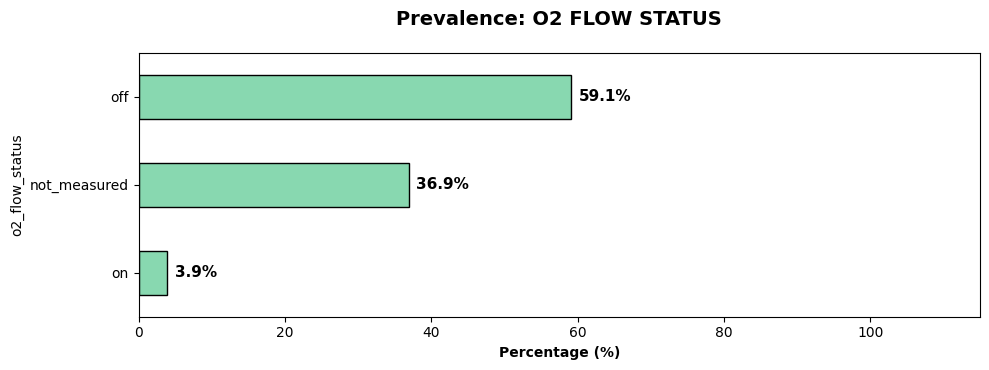

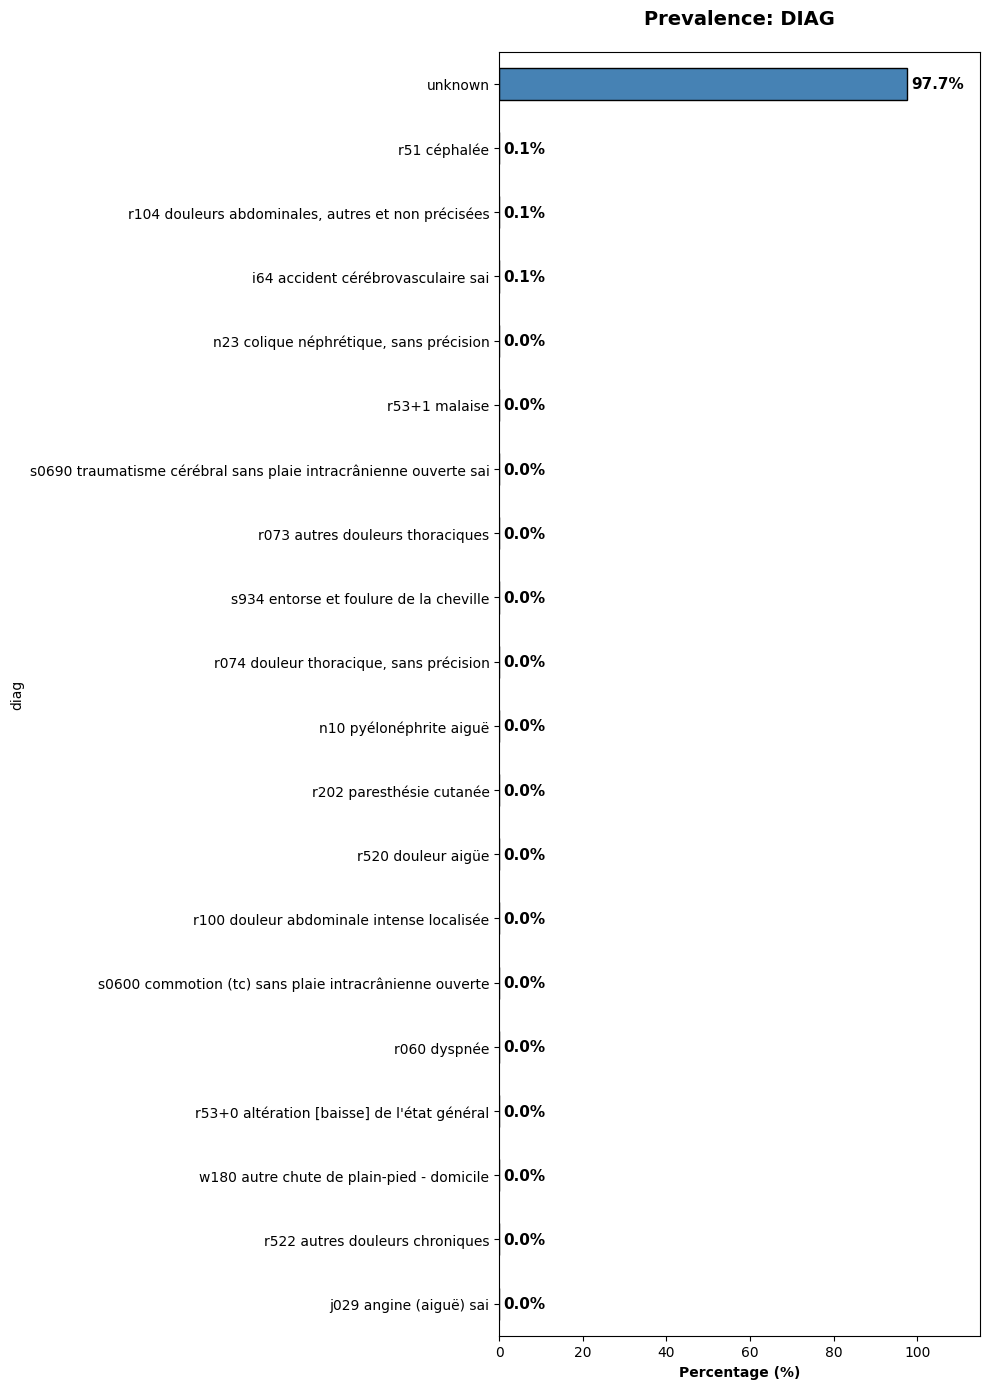

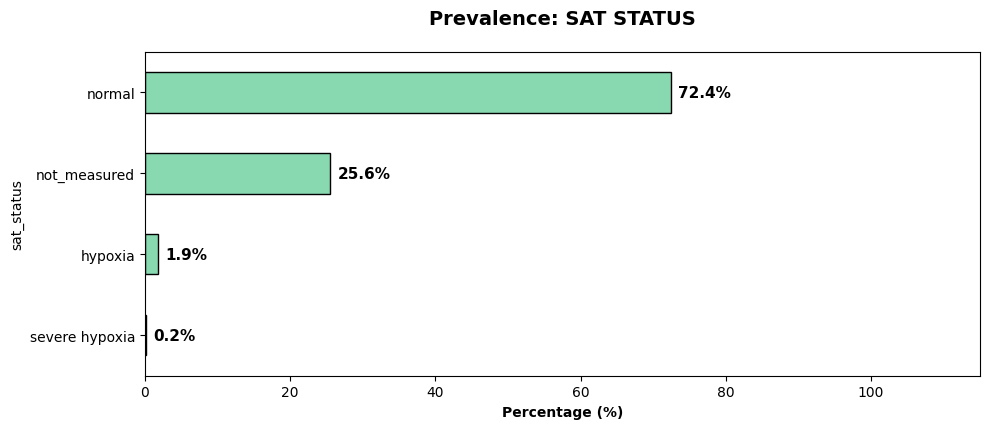

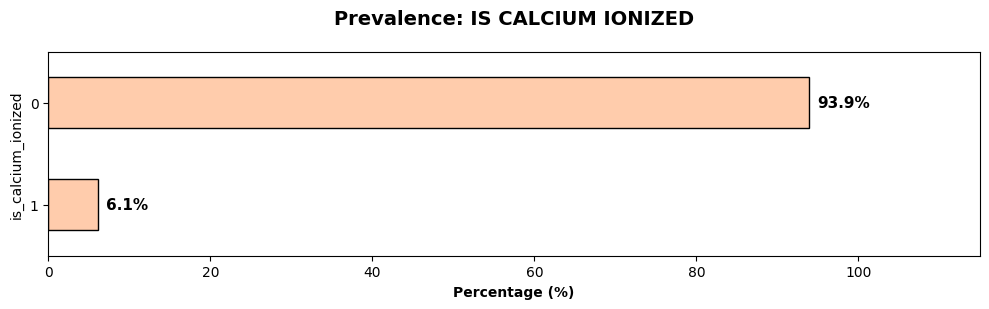

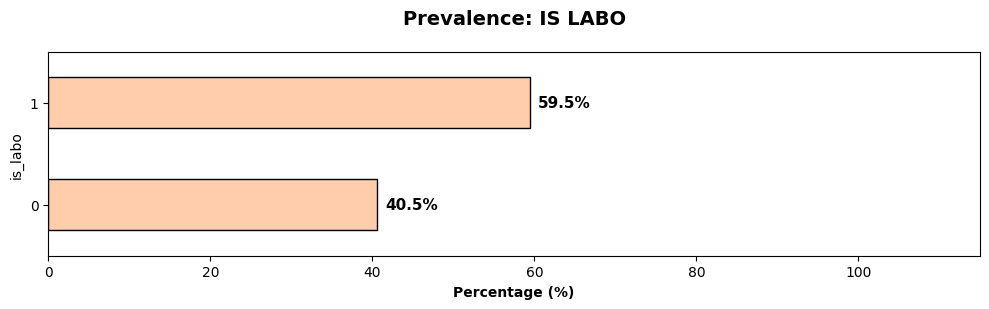

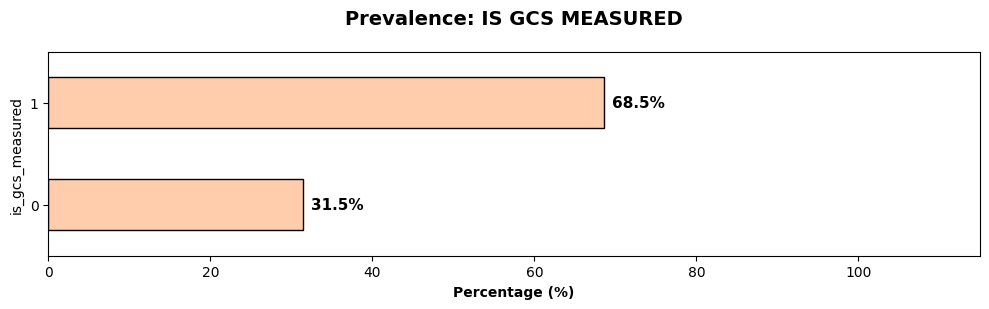

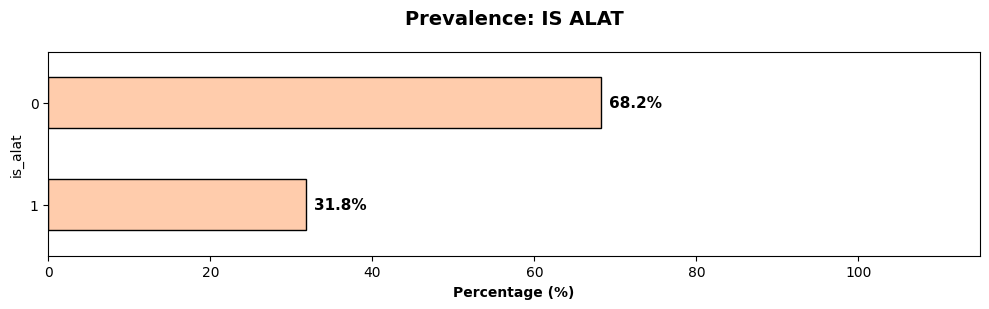

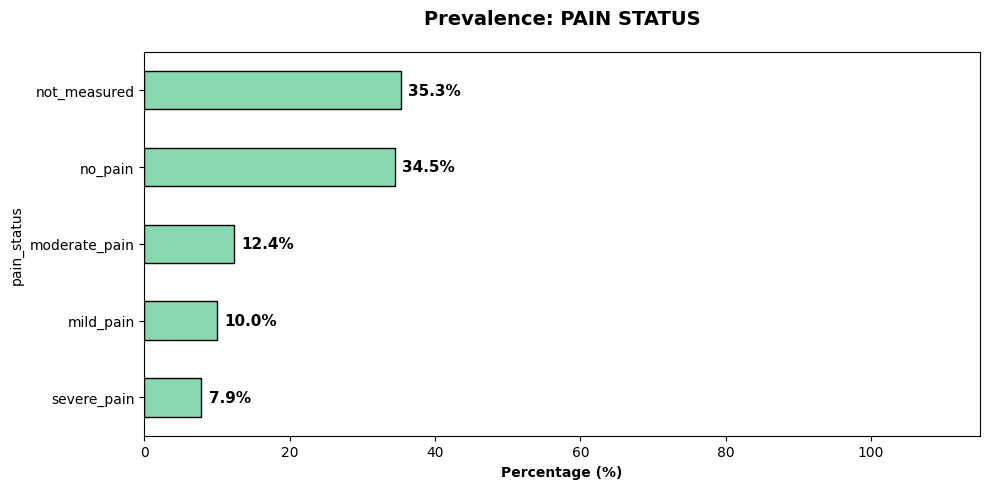

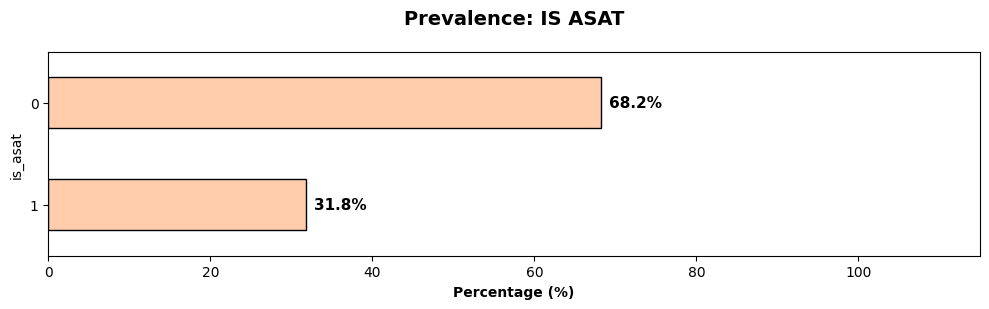

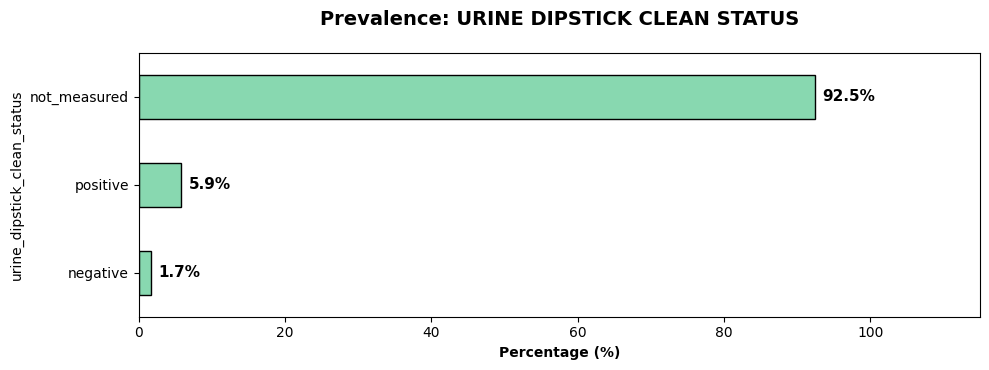

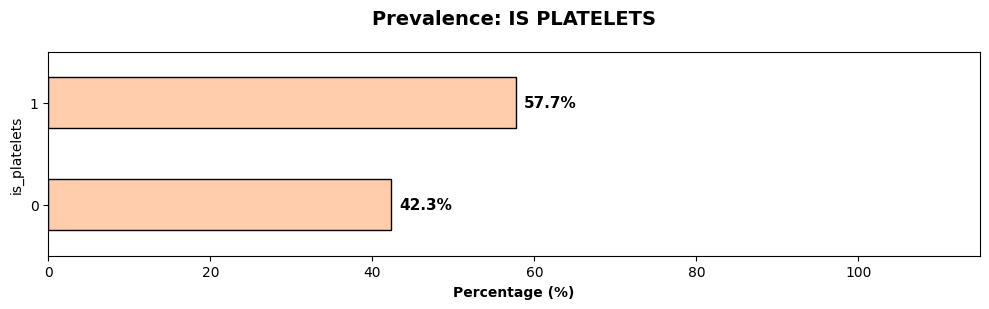

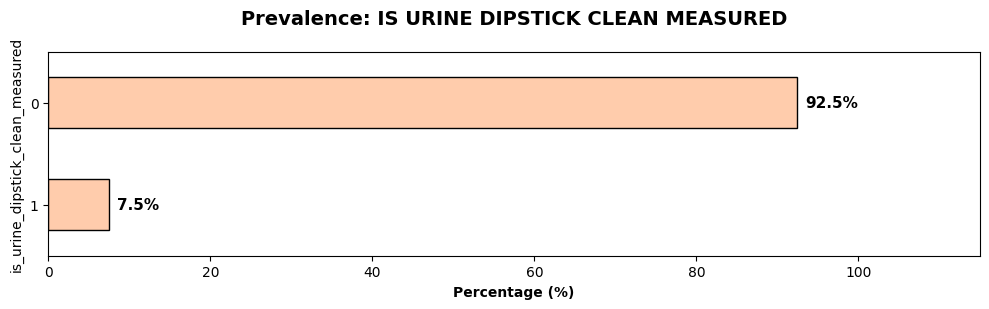

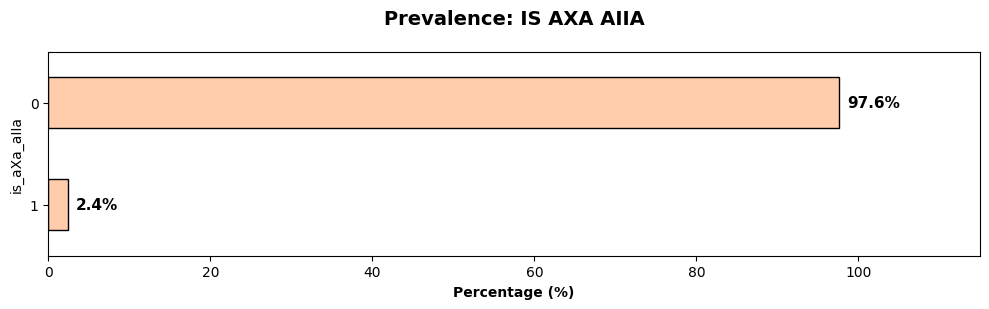

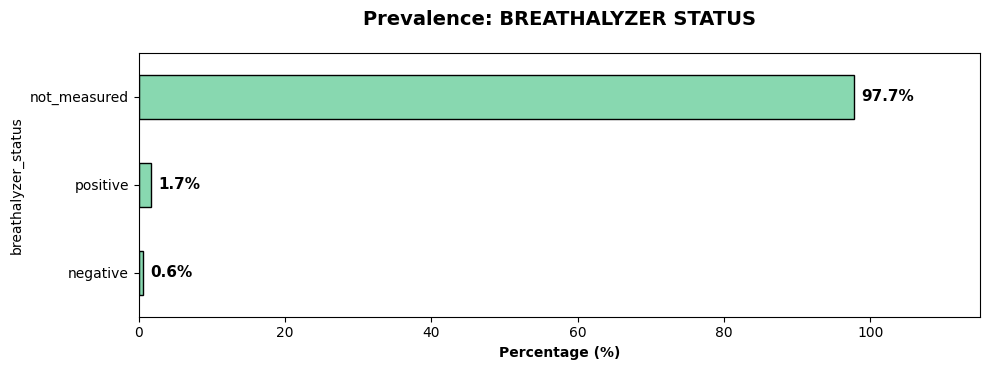

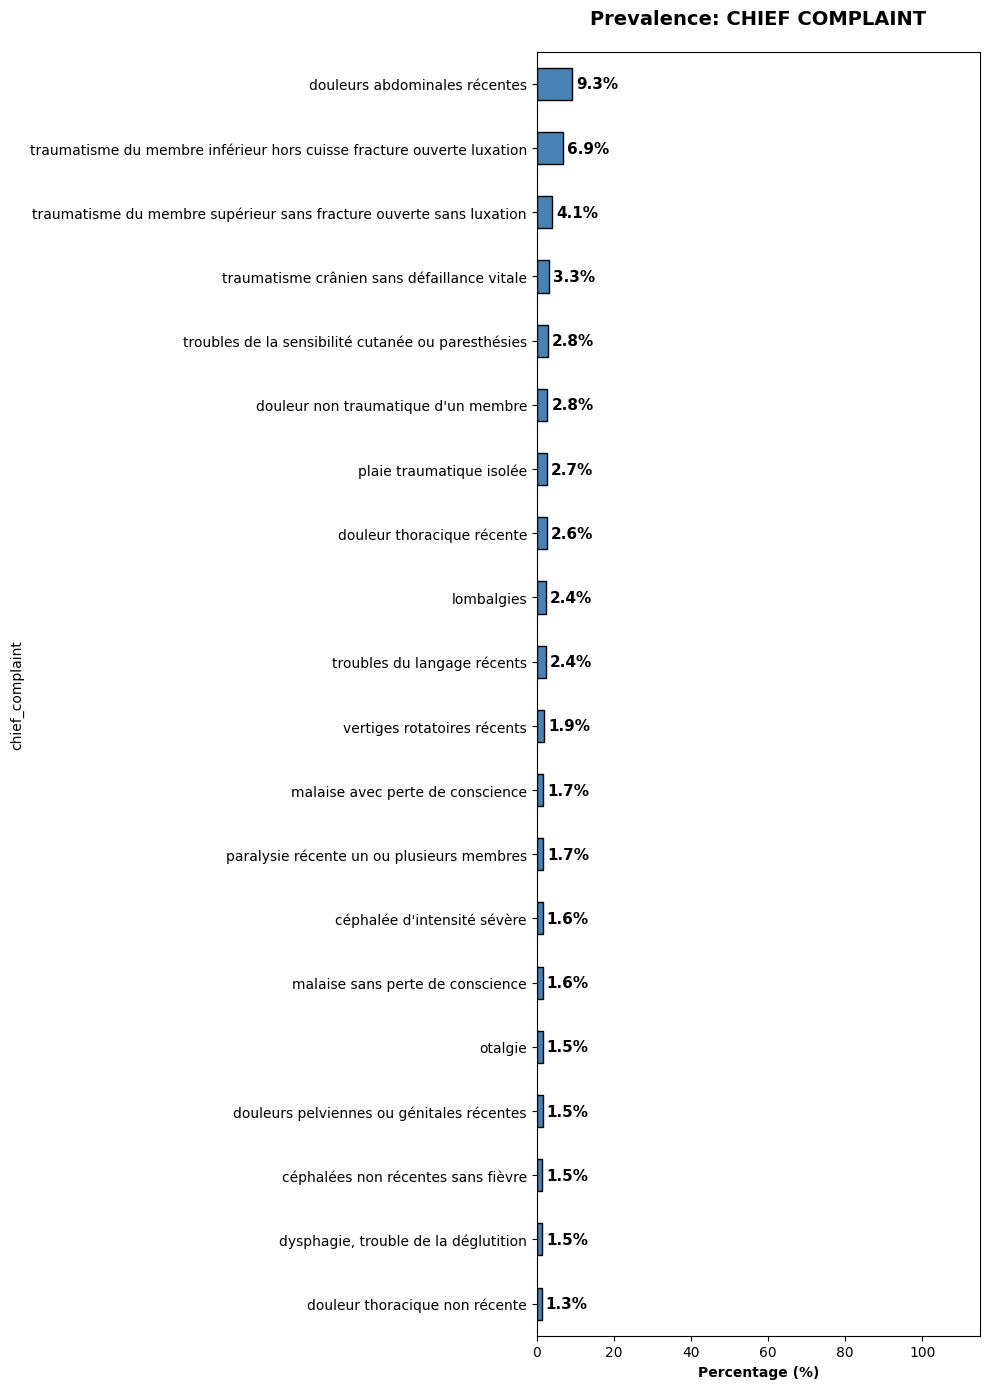

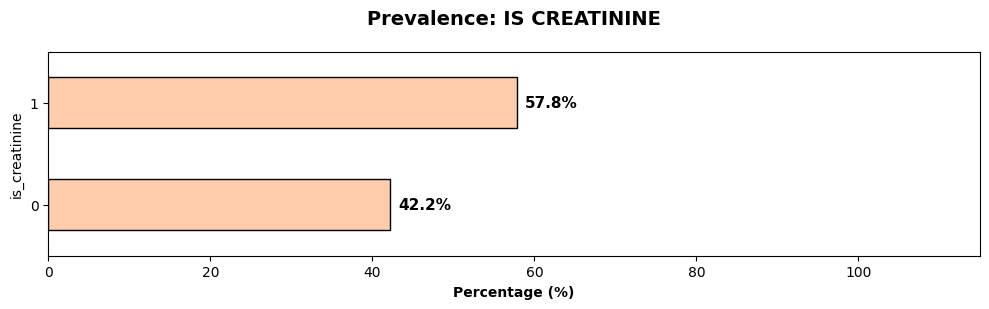

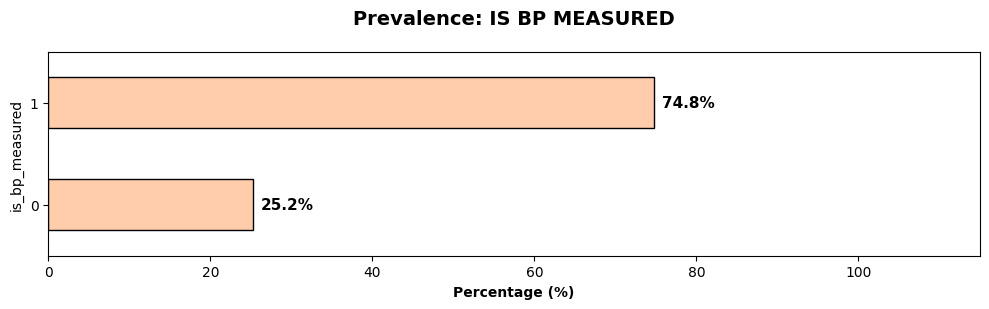

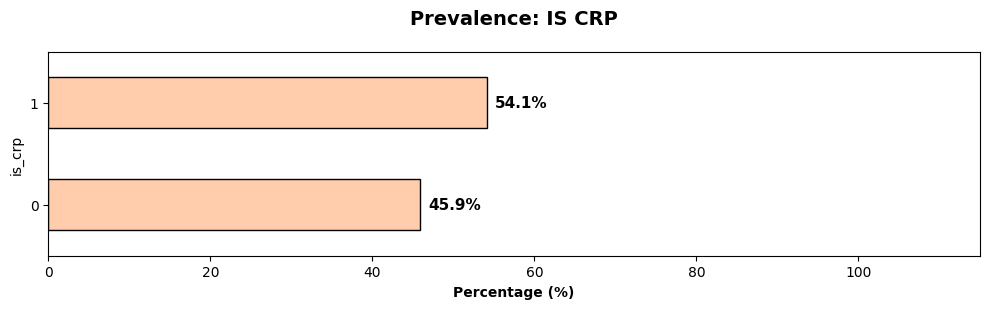

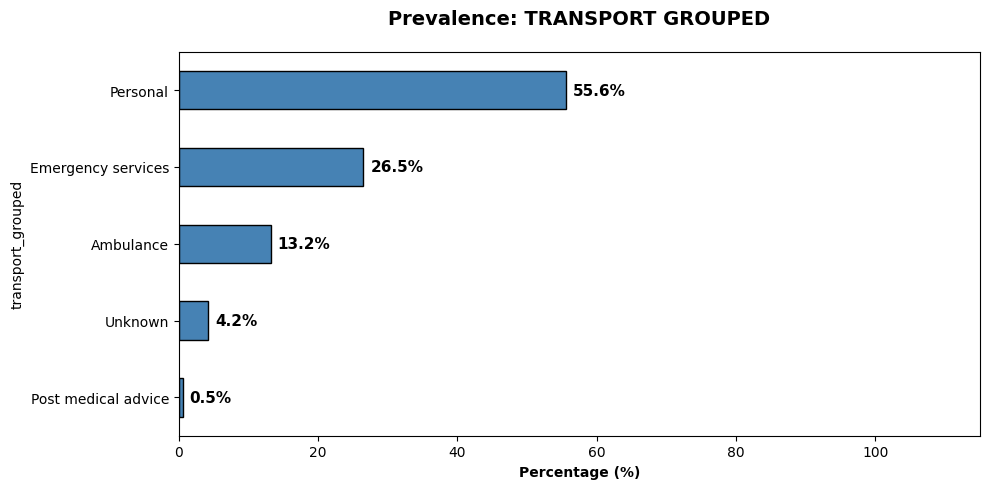

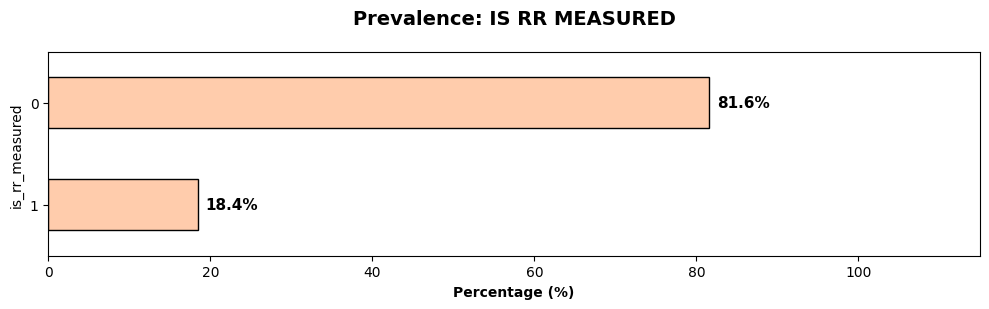

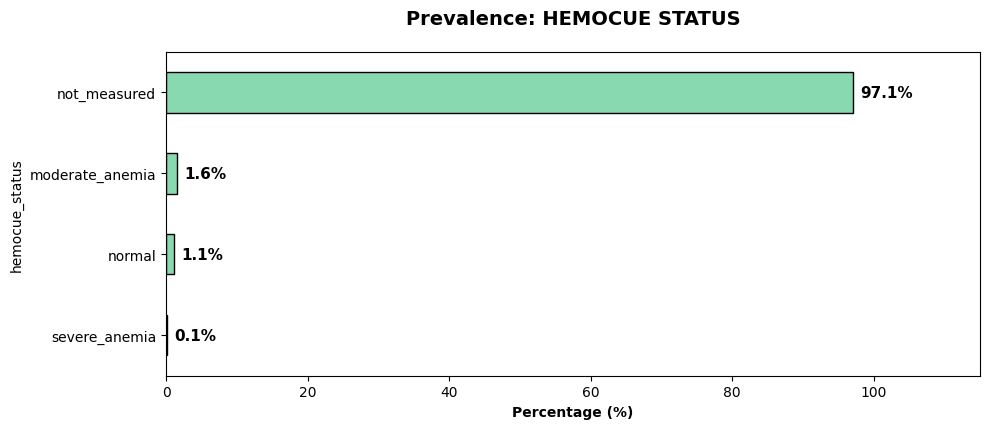

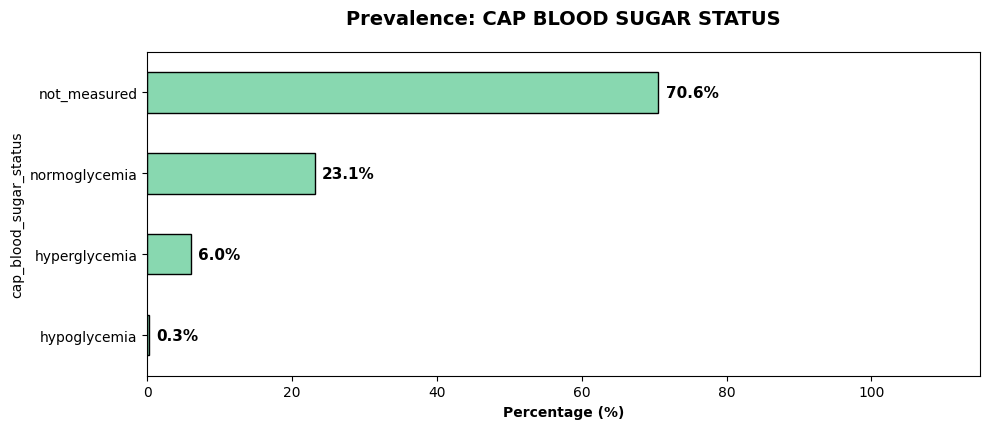

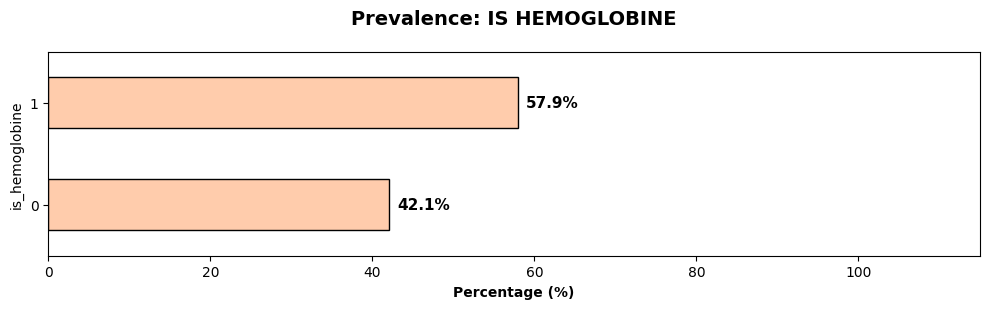

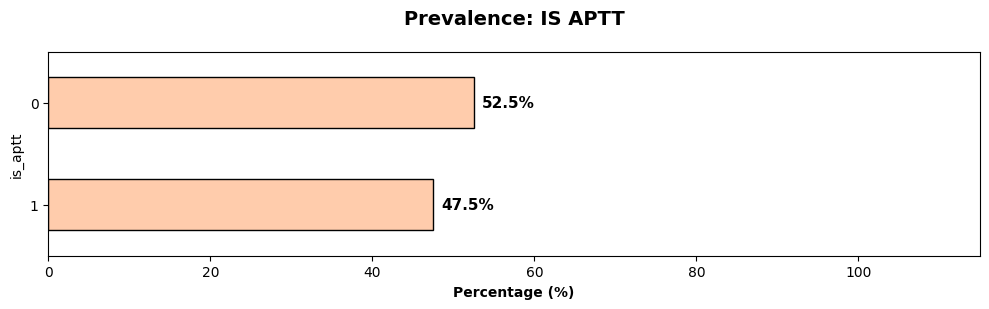

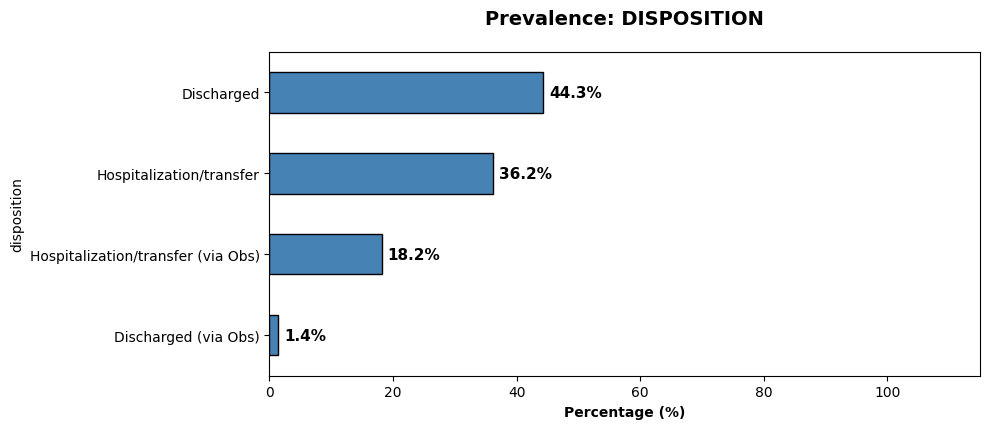

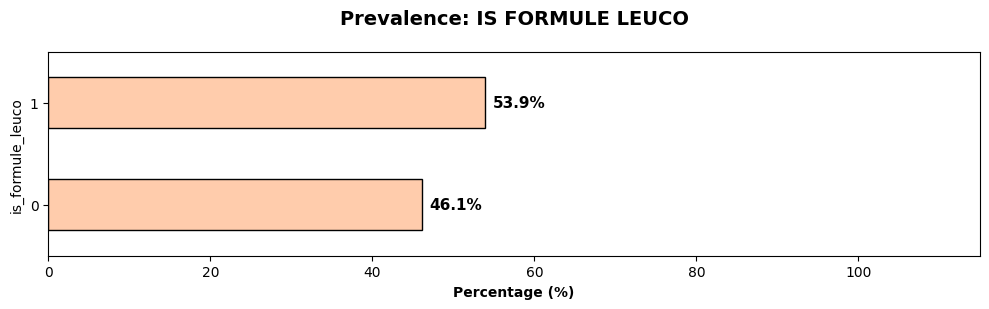

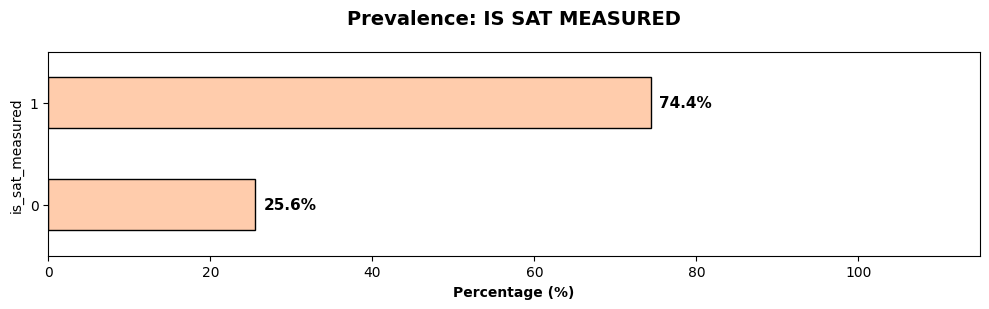

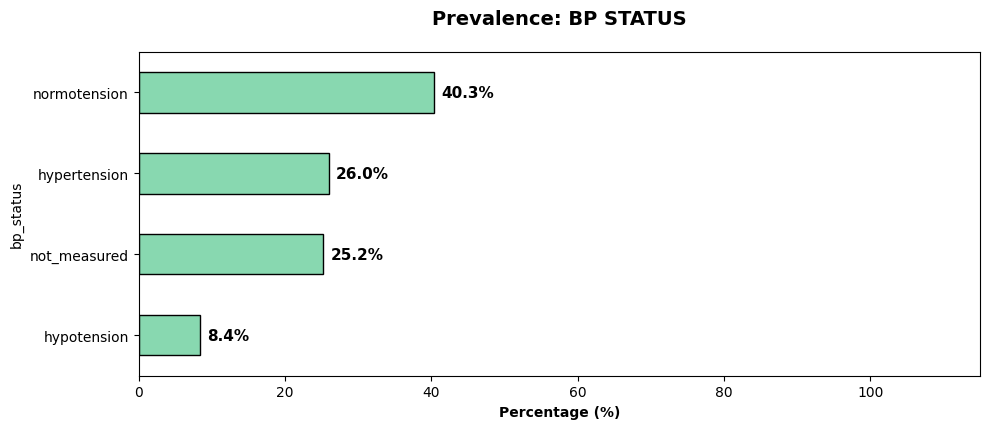

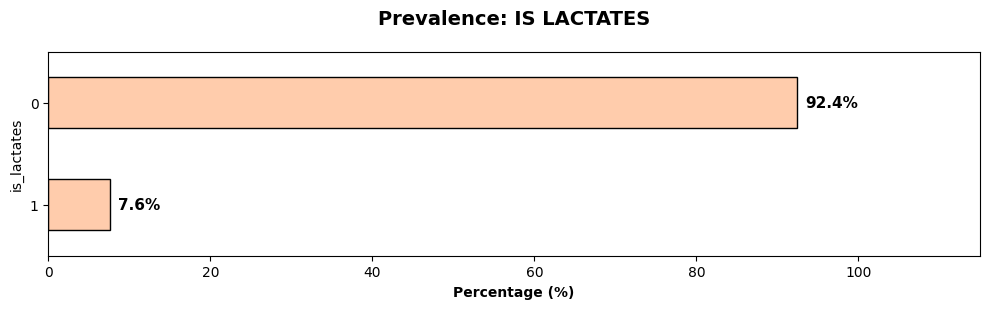

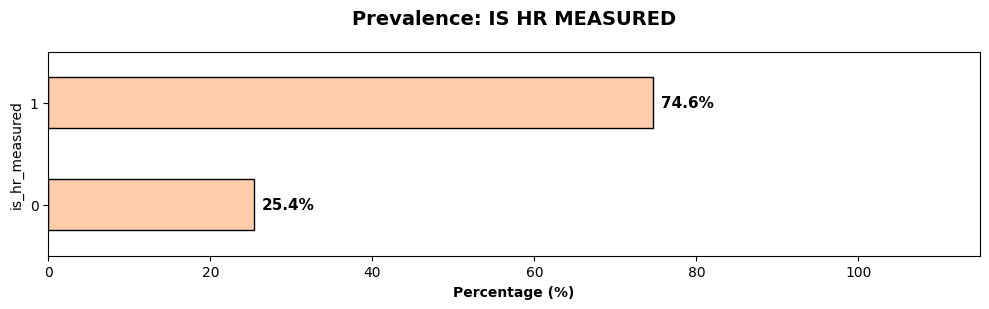

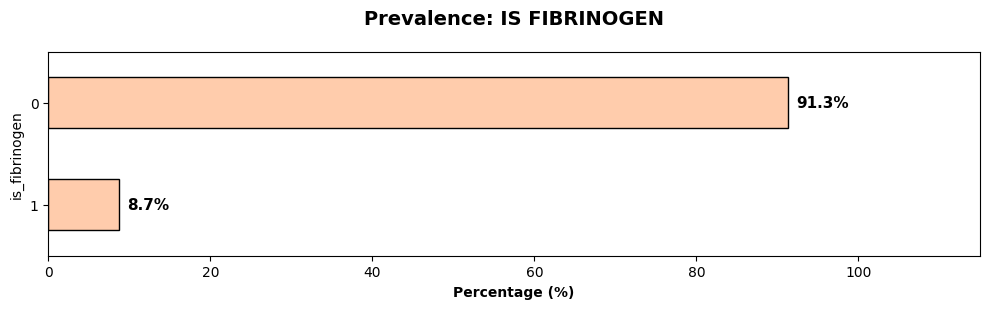

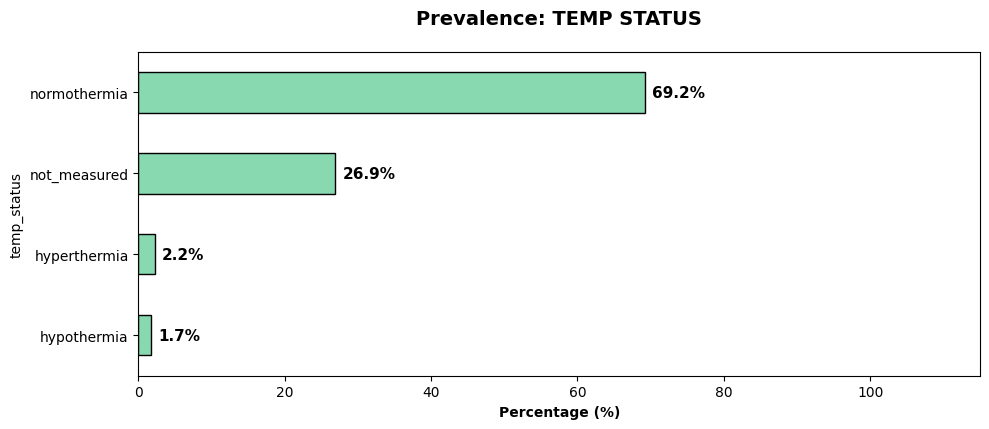

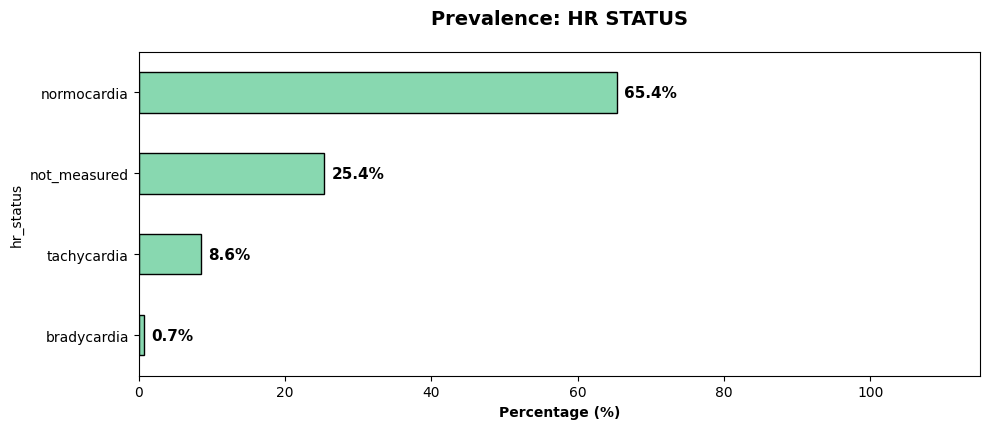

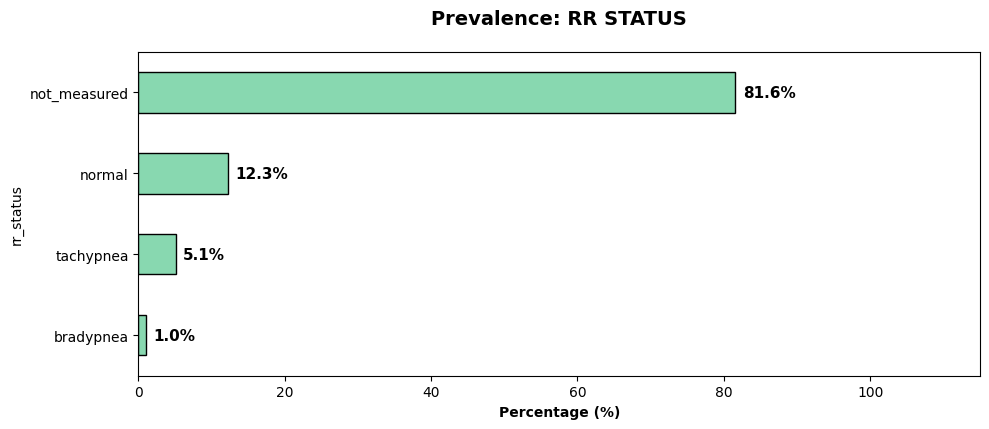

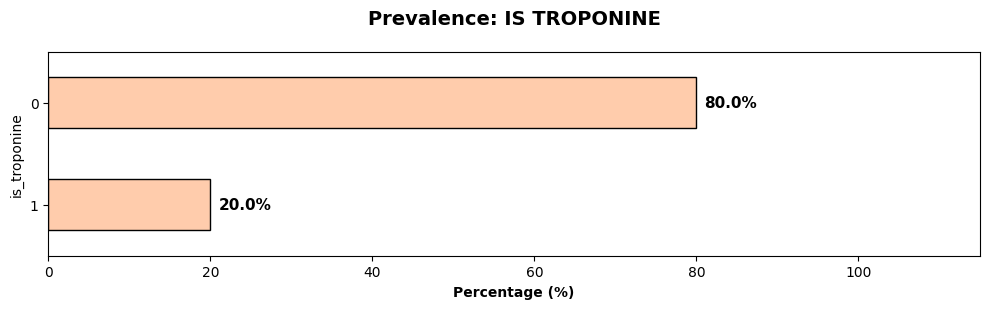

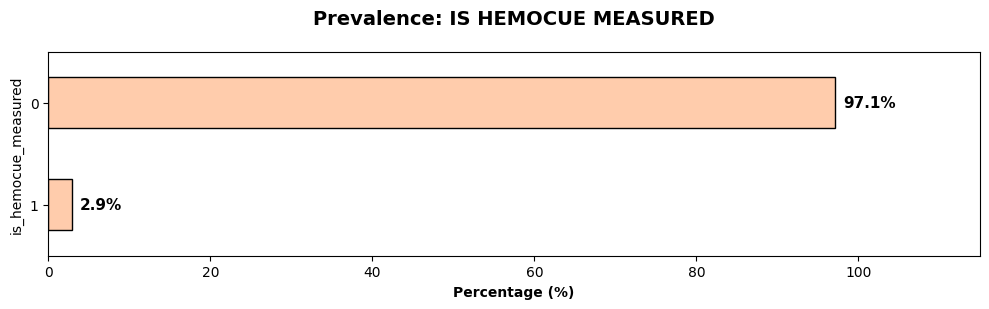

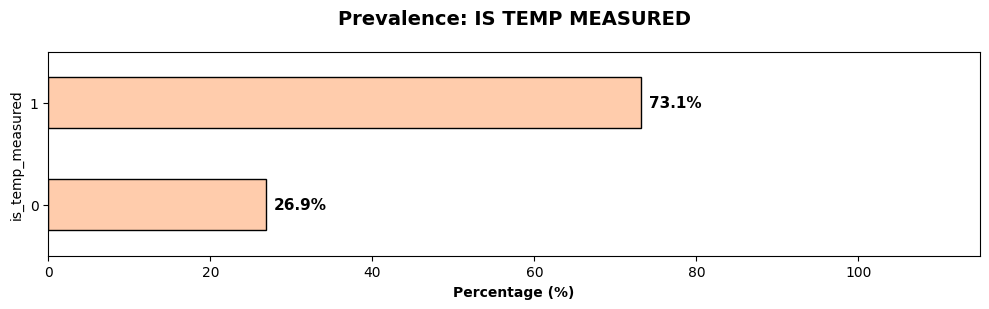

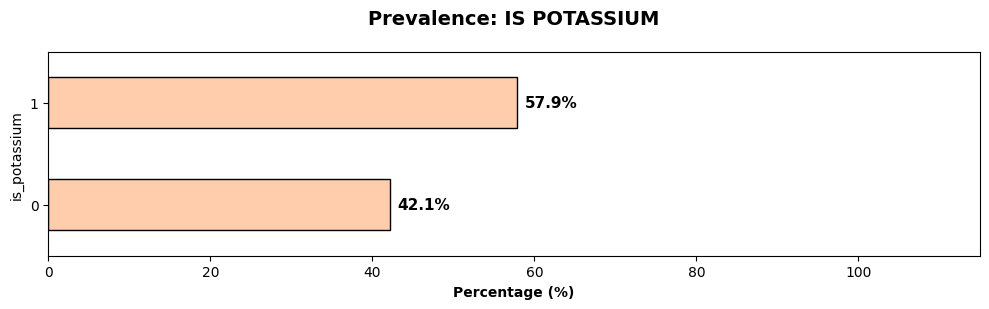

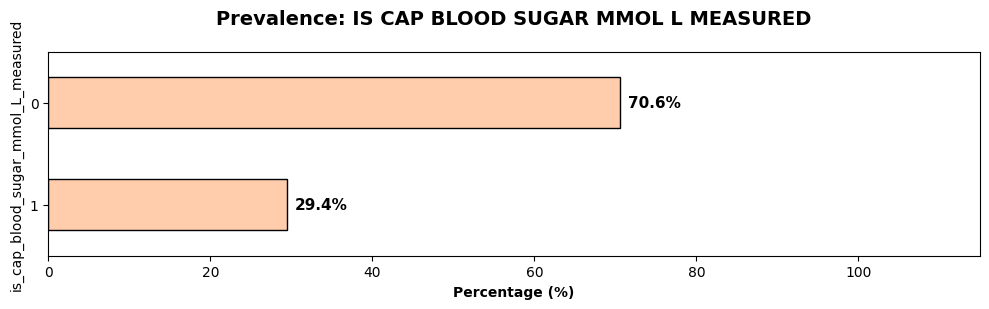

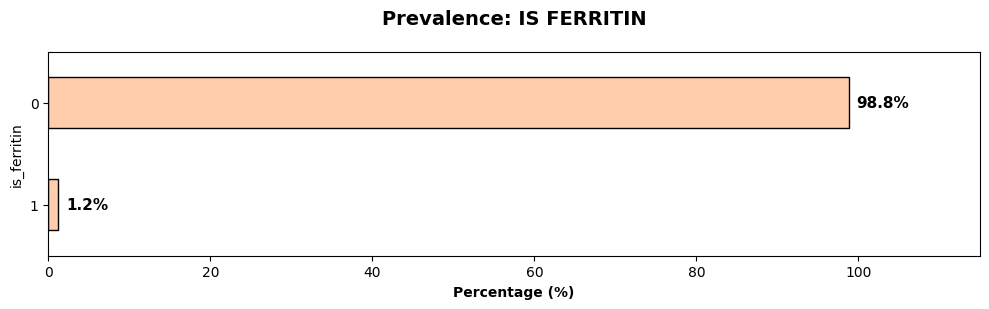

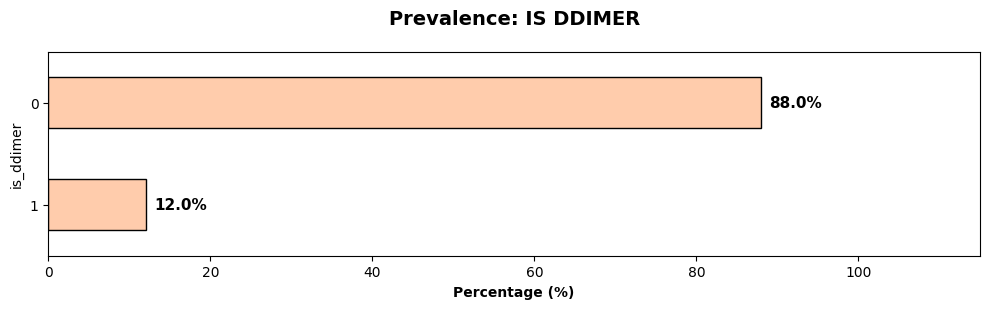

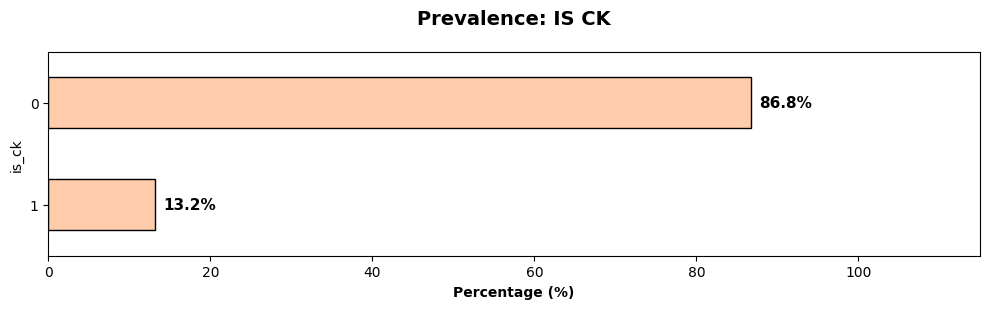

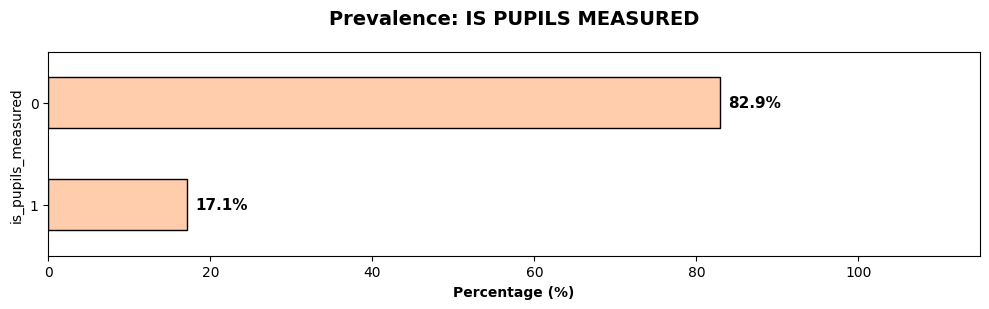

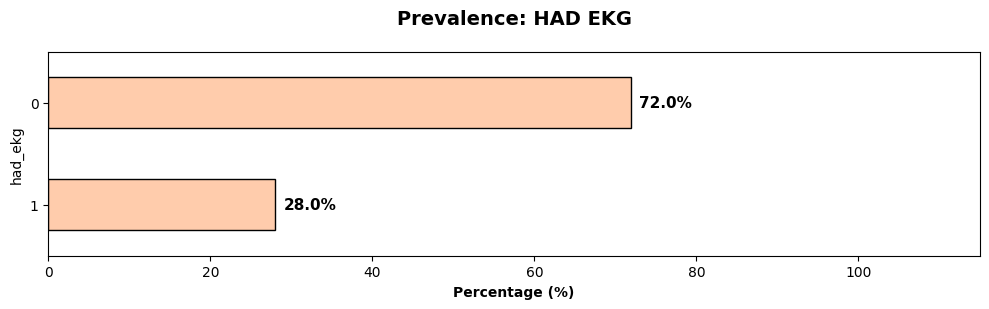

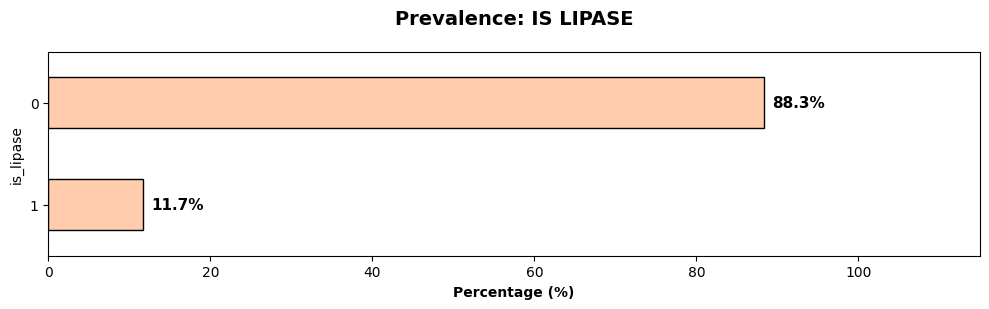

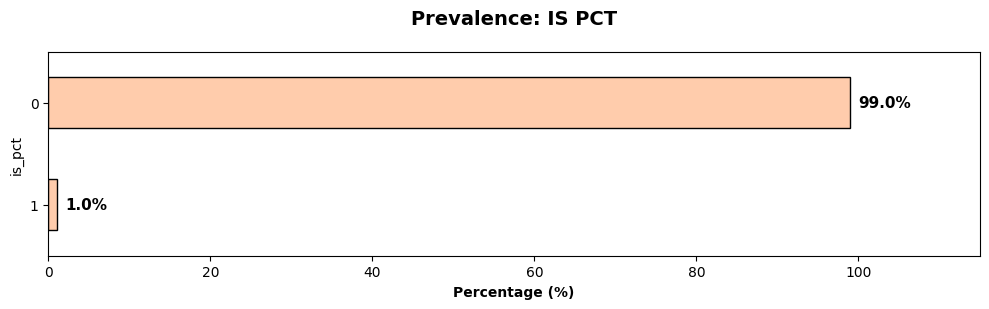

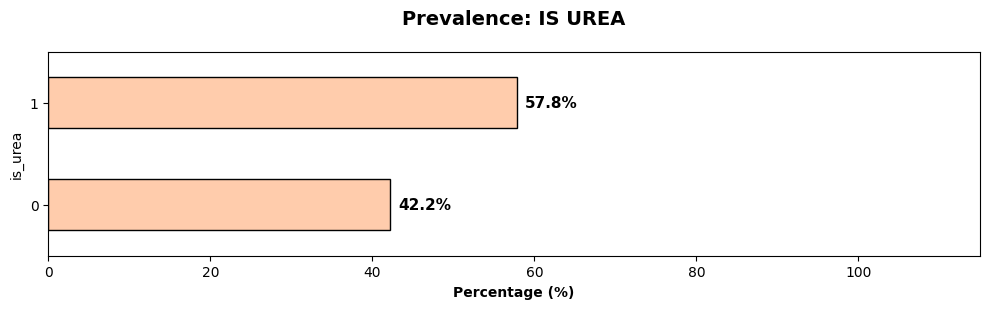

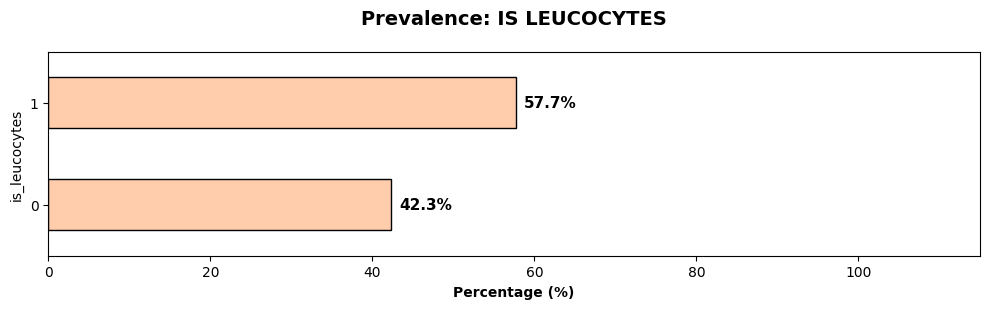

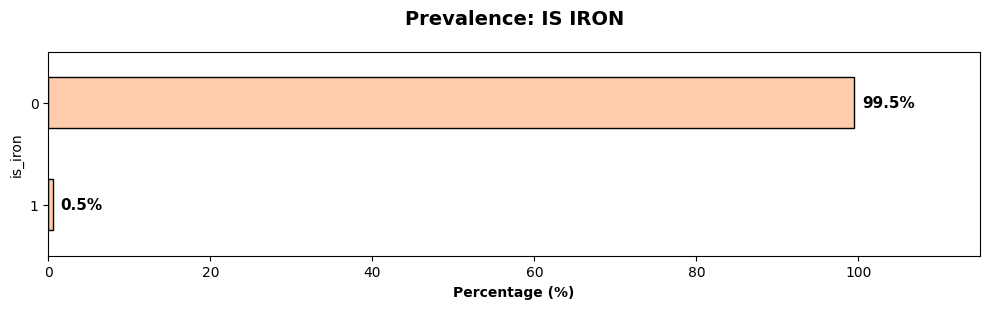

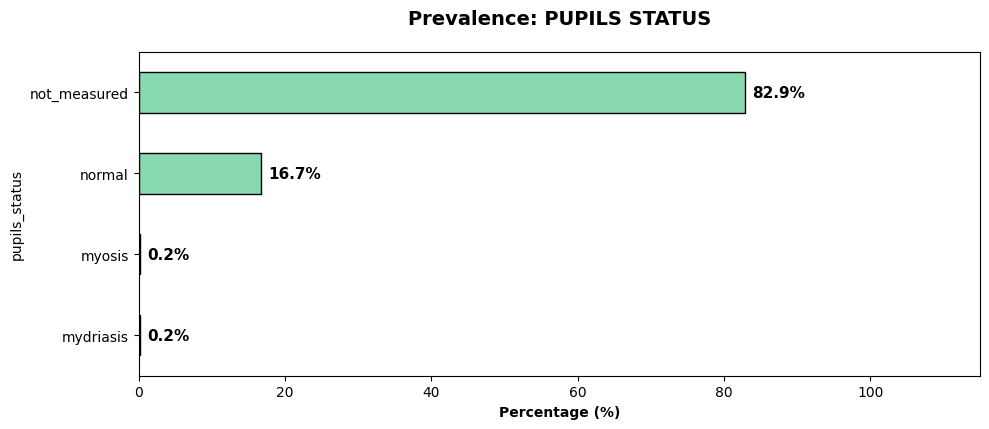

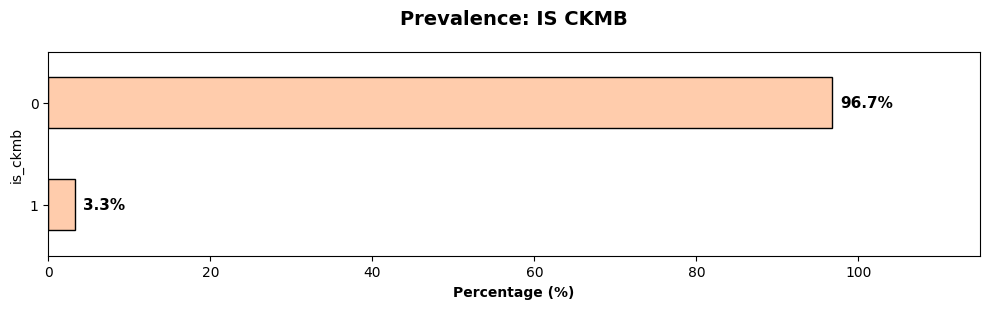

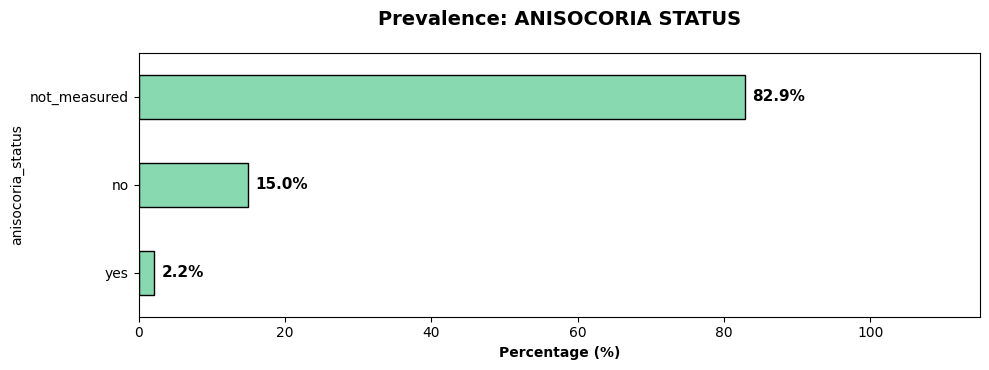

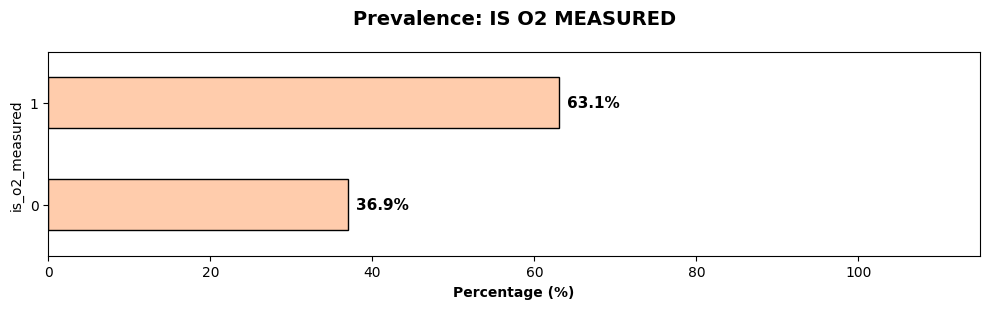

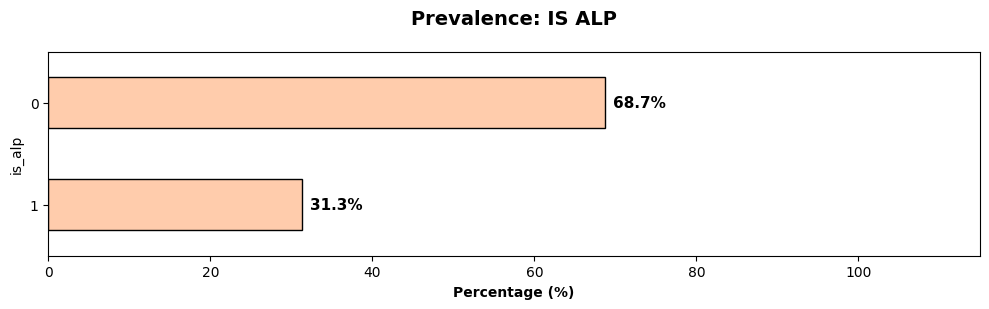

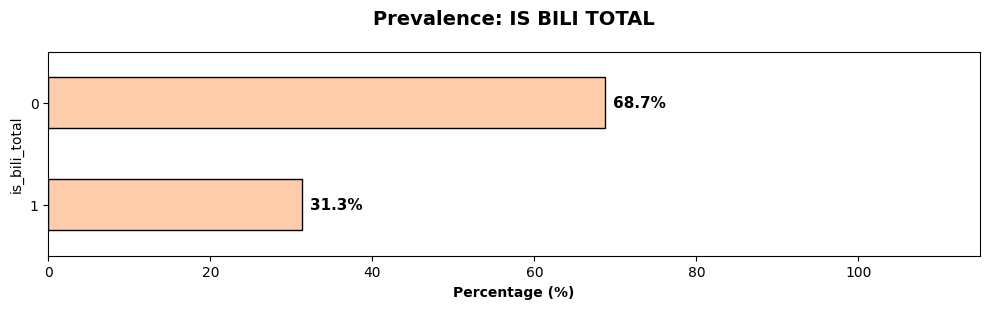

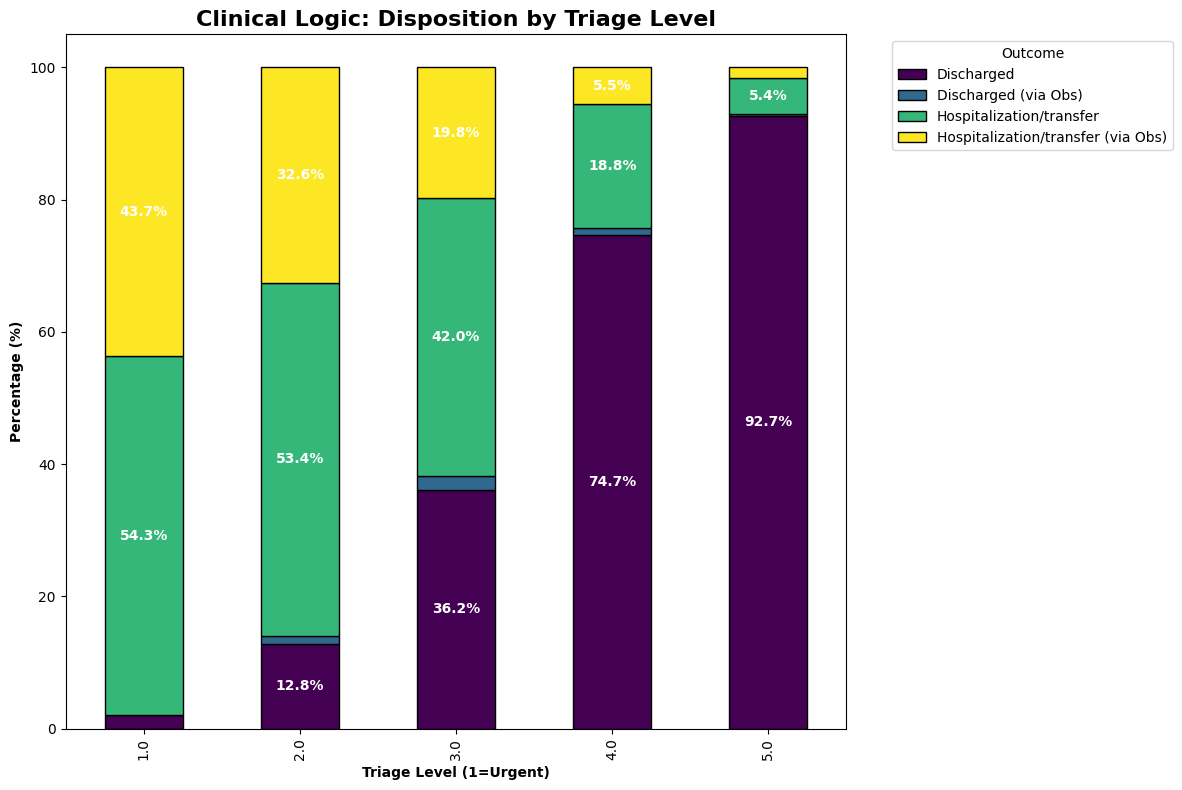

In [82]:
# =========================================================
# CONFIGURATION & DIRECTORIES
# =========================================================
plt.style.use('default')

# =========================================================
# 1. DATA COMPLETENESS HIERARCHY (GREAT TABLES)
# =========================================================
cols_target = [
    'is_bp_measured', 'is_hr_measured', 'is_temp_measured',
    'is_sat_measured', 'is_rr_measured', 'is_gcs_measured',
    'is_hgt_mmol_L_measured', 'is_pupil_right_measured',
    'is_pain_measured', 'is_ethylotest_measured',
    'is_hemocue_measured', 'is_labo', 'has_imaging_any', 'had_ekg'
]

LABEL_MAP = {
    'is_bp_measured'         : 'Systolic Blood Pressure',
    'is_hr_measured'          : 'Heart Rate',
    'is_temp_measured'        : 'Temperature',
    'is_sat_measured'         : 'O2 Saturation',
    'is_rr_measured'          : 'Respiratory Rate',
    'is_gcs_measured'         : 'Glasgow Coma Scale',
    'is_hgt_mmol_L_measured'  : 'Blood Glucose',
    'is_pupil_right_measured' : 'Pupil Assessment',
    'is_pain_measured'        : 'Pain Score',
    'is_ethylotest_measured'  : 'Breathalyzer',
    'is_hemocue_measured'     : 'Hemocue',
    'is_labo'                 : 'Lab Tests',
    'has_imaging_any'         : 'Imaging',
    'had_ekg'                 : 'EKG',
}

summary_list = []
for col in cols_target:
    if col in df.columns:
        temp_col = df[col].fillna(0).astype(int)
        counts   = temp_col.value_counts()
        n0, n1   = counts.get(0, 0), counts.get(1, 0)
        total    = n0 + n1
        pct_1    = n1 / total if total > 0 else 0

        summary_list.append({
            "variable" : LABEL_MAP.get(col, col.replace('is_', '').replace('_measured', '').replace('_', ' ').title()),
            "no"       : f"{n0} ({n0 / total:.1%})" if total > 0 else "0",
            "yes"      : f"{n1} ({pct_1:.1%})"      if total > 0 else "0",
            "total"    : total,
            "raw_pct_1": pct_1
        })

df_gt_completness = pd.DataFrame(summary_list).sort_values(by="raw_pct_1", ascending=False)

gt_table = (
    GT(df_gt_completness.drop(columns="raw_pct_1"))
    .tab_header(title="Data Completeness Hierarchy", subtitle="Measured Clinical Parameters")
    .tab_options(
        table_background_color="white",
        heading_background_color="white",
        column_labels_background_color="white",
    )
)

with open(f"{output_dir}/completeness_table.html", "w") as f:
    f.write(gt_table.as_raw_html())
df_gt_completness.drop(columns="raw_pct_1").to_csv(f"{output_dir}/completeness_table.csv", index=False)

display(gt_table)

# =========================================================
# 2. QUANTITATIVE DISTRIBUTIONS (HIST & BOXPLOT)
# =========================================================
numeric_cols = df.select_dtypes(include=[np.number]).columns
quanti_cols  = [col for col in numeric_cols if df[col].nunique() > 2 and col.lower() != 'nda']

for col in quanti_cols:
    data = df[col].dropna()
    if data.empty: continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

    sns.histplot(data, bins=30, color='DeepSkyBlue', edgecolor='black', ax=axes[0])
    axes[0].set_title(f"Distribution: {col.upper()}", fontweight='bold')

    sns.boxplot(x=data, color='Orange', ax=axes[1], fliersize=4)
    axes[1].set_title(f"Outlier Detection: {col.upper()}", fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"{output_dir}/distribution_{col}.png", dpi=300)
    plt.show()

# =========================================================
# 3. CATEGORICAL & STATUS VARIABLES (Custom Colors)
# =========================================================
status_cols   = [col for col in df.columns if col.endswith('_status')]
binary_cols   = [col for col in df.columns if col.startswith('is_') or col == 'had_ekg']
pathway_cols  = ['transport_grouped', 'chief_complaint_en', 'diag', 'disposition']
all_qualitative = list(set(pathway_cols + status_cols + binary_cols))

for col in all_qualitative:
    if col not in df.columns:
        continue

    counts_pct = df[col].astype(str).value_counts(normalize=True).head(20) * 100

    if counts_pct.empty or (len(counts_pct) == 1 and 'nan' in counts_pct.index):
        continue

    counts_pct = counts_pct.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, len(counts_pct) * 0.6 + 2), facecolor='white')

    if col.endswith('_status'):
        color = '#88d8b0'
    elif col.startswith('is_') or col == 'had_ekg':
        color = '#ffccac'
    else:
        color = 'SteelBlue'

    counts_pct.plot(kind='barh', color=color, edgecolor='black', ax=ax)

    for i, v in enumerate(counts_pct):
        ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=11, fontweight='bold')

    ax.set_title(f"Prevalence: {col.replace('_', ' ').upper()}", fontsize=14, pad=20, fontweight='bold')
    ax.set_xlabel("Percentage (%)", fontweight='bold')
    ax.set_xlim(0, 115)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/categorical_{col}.png", dpi=300)
    plt.show()

# =========================================================
# 4. TRIAGE VS DISPOSITION (CLINICAL VALIDATION)
# =========================================================
table_disposition = pd.crosstab(df['triage'], df['disposition'], normalize='index') * 100

if not table_disposition.empty:
    table_disposition = table_disposition.astype(float).fillna(0)

    fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')
    table_disposition.plot(kind='bar', stacked=True, colormap='viridis',
                           edgecolor='black', ax=ax)

    ax.set_title('Clinical Logic: Disposition by Triage Level', fontsize=16, fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontweight='bold')
    ax.set_xlabel('Triage Level (1=Urgent)', fontweight='bold')
    ax.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')

    for p in ax.patches:
        h = p.get_height()
        if h > 5:
            ax.text(p.get_x() + p.get_width() / 2, p.get_y() + h / 2,
                    f'{h:.1f}%', ha='center', va='center',
                    fontsize=10, color='white', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"{output_dir}/triage_vs_disposition.png", dpi=300)
    plt.show()

In [83]:
# =========================================================
# IMAGING EXAMINATIONS SUMMARY
# =========================================================


# columns to exclude
EXCLUDE_COLS = {
    "has_o2_support",
    "has_imaging_any",
    "has_blood_gas",
    "has_lumbar_puncture",
    "has_culture",
    "has_blood_test",
}

# 1. Filter for patients who underwent imaging
df_imaging = df[df["has_imaging_any"] == 1]
total_imaging_patients = len(df_imaging)

# 2. Identify has_* columns (excluding non-imaging flags)
has_cols = [
    col for col in df.columns
    if col.startswith("has_") and col not in EXCLUDE_COLS
]

imaging_summary = []
for col in has_cols:
    n1    = (df_imaging[col].astype(int) == 1).sum()
    pct_1 = n1 / total_imaging_patients if total_imaging_patients > 0 else 0

    imaging_summary.append({
        "variable":   col.replace("has_", "").replace("_", " ").upper(),
        "count":      n1,
        "percentage": pct_1,
        "total":      total_imaging_patients,
    })

df_gt_imaging = (
    pd.DataFrame(imaging_summary)
    .sort_values(by="percentage", ascending=False)
)

# Render Imaging Table
gt_imaging = (
    GT(df_gt_imaging)
    .tab_header(
        title="Breakdown of Imaging Examinations",
        subtitle=html(f"Analysis of <b>{total_imaging_patients}</b> patients with confirmed imaging")
    )
    .cols_label(
        variable="Examination Type",
        count="Count (N)",
        percentage="Frequency (%)",
        total="Patient Base"
    )
    .fmt_percent(columns="percentage", decimals=1)
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.column_labels()
    )
    .tab_style(
        style=style.fill(color="#f0f7ff"), # Light blue for imaging
        locations=loc.body(columns="percentage")
    )
    .cols_align(align="center", columns=["count", "percentage", "total"])
    .tab_options(table_width="100%")
)

# =========================================================
# BIOLOGY / LAB TESTS SUMMARY
# =========================================================
# ── Lab summary ────────────────────────────────────────────────────────────────
LAB_COLS = [
    "has_blood_test",
    "has_lumbar_puncture",
    "has_blood_gas",
    "has_culture",
]

df_labo             = df[df["is_labo"] == 1]
total_labo_patients = len(df_labo)

lab_summary = []
for col in LAB_COLS:
    if col not in df.columns:
        continue
    n1    = (df_labo[col].astype(int) == 1).sum()
    pct_1 = n1 / total_labo_patients if total_labo_patients > 0 else 0
    lab_summary.append({
        "variable":   col.replace("has_", "").replace("_", " ").upper(),
        "count":      n1,
        "percentage": round(pct_1 * 100, 1),
        "total":      total_labo_patients,
    })

df_gt_lab = (
    pd.DataFrame(lab_summary)
    .sort_values(by="percentage", ascending=False)
)

print(f"Lab summary — among {total_labo_patients} patients with lab work:")
display(df_gt_lab)


# blood test summary
# 1. Filter for patients with biology results
df_lab = df[df['is_labo'] == 1]
total_lab_patients = len(df_lab)

# 2. Identify biology columns (starts with 'is_', excludes 'measured' meta-data and the main flag)
lab_cols = [col for col in df.columns
             if col.startswith('is_')
             and 'measured' not in col
             and col != 'is_labo']

lab_summary = []
for col in lab_cols:
    n1 = (df_lab[col].astype(int) == 1).sum()
    pct_1 = n1 / total_lab_patients if total_lab_patients > 0 else 0

    lab_summary.append({
        "variable": col.replace('is_', '').replace('_', ' ').upper(),
        "count": n1,
        "percentage": pct_1,
        "total": total_lab_patients
    })

df_gt_lab = pd.DataFrame(lab_summary).sort_values(by="percentage", ascending=False)

# Render Biology Table
gt_labo = (
    GT(df_gt_lab)
    .tab_header(
        title="Breakdown of Biological Lab Tests",
        subtitle=html(f"Analysis of <b>{total_lab_patients}</b> patients with lab samples")
    )
    .cols_label(
        variable="Biological Analysis",
        count="Count (N)",
        percentage="Frequency (%)",
        total="Patient Base"
    )
    .fmt_percent(columns="percentage", decimals=1)
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.column_labels()
    )
    .tab_style(
        style=style.fill(color="#fffcf0"),  # Light yellow for biology
        locations=loc.body(columns="percentage")
    )
    .cols_align(align="center", columns=["count", "percentage", "total"])
    .tab_options(table_width="100%")
)

# ── Sauvegarde HTML (affichage) ───────────────────────────────────────────────
with open(f"{output_dir}/imaging_summary_imaging_pop.html", "w") as f:
    f.write(gt_imaging.as_raw_html())

with open(f"{output_dir}/bio_summary_imaging_pop.html", "w") as f:
    f.write(gt_labo.as_raw_html())

# ── Sauvegarde CSV ────────────────────────────────────────────────────────────
df_gt_imaging.to_csv(f"{output_dir}/imaging_summary_imaging_pop.csv", index=False)
df_gt_lab.to_csv(f"{output_dir}/bio_summary_imaging_pop.csv", index=False)

# ── Sauvegarde Excel (les deux dans un seul fichier, un onglet chacun) ────────
with pd.ExcelWriter(f"{output_dir}/summaries_imaging_pop.xlsx") as writer:
    df_gt_imaging.to_excel(writer, sheet_name="Imaging", index=False)
    df_gt_lab.to_excel(writer, sheet_name="Biology", index=False)


# To display in Jupyter/Notebook:
display(gt_imaging)
display(gt_labo)

Lab summary — among 33761 patients with lab work:


,variable,count,percentage,total
0,BLOOD TEST,33230,98.4,33761
3,CULTURE,8214,24.3,33761
2,BLOOD GAS,4448,13.2,33761
1,LUMBAR PUNCTURE,470,1.4,33761


GT(_tbl_data=               variable  count  percentage  total
1               CT SCAN  14253    0.482727  29526
2                  XRAY  13048    0.441916  29526
3                   MRI   5444    0.184380  29526
0            ULTRASOUND    913    0.030922  29526
4  RADIO INTERVENTIONAL     81    0.002743  29526
5      NUCLEAR MEDICINE      7    0.000237  29526, _body=<great_tables._gt_data.Body object at 0x7358be834320>, _boxhead=Boxhead([ColInfo(var='variable', type=<ColInfoTypeEnum.default: 1>, column_label='Examination Type', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='Count (N)', column_align='center', column_width=None), ColInfo(var='percentage', type=<ColInfoTypeEnum.default: 1>, column_label='Frequency (%)', column_align='center', column_width=None), ColInfo(var='total', type=<ColInfoTypeEnum.default: 1>, column_label='Patient Base', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7358b7ffba40>, _spanners=Spanners([]), _heading=Heading(title='Breakdown of Imaging Examinations', subtitle=Html(text='Analysis of <b>29526</b> patients with confirmed imaging'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7359822b29c0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7358b795b6e0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='count', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='percentage', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='total', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=0, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=1, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=2, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=3, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=4, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=5, colnum=None, styles=[CellStyleFill(color='#f0f7ff')])], _locale=<great_tables._gt_data.Locale object at 0x7358ba067980>, _formats=[<great_tables._gt_data.FormatInfo object at 0x735980e4f140>], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='100%'), tab

GT(_tbl_data=           variable  count  percentage  total
18      HEMOGLOBINE  32904    0.974616  33761
24           SODIUM  32858    0.973253  33761
22        POTASSIUM  32857    0.973224  33761
13       CREATININE  32824    0.972246  33761
28             UREA  32822    0.972187  33761
2        LEUCOCYTES  32762    0.970410  33761
21        PLATELETS  32754    0.970173  33761
12          CALCIUM  32455    0.961316  33761
10              CRP  30730    0.910222  33761
3     FORMULE LEUCO  30620    0.906964  33761
25             APTT  26950    0.798258  33761
26               PT  26759    0.792601  33761
4              ALAT  18068    0.535174  33761
5              ASAT  18068    0.535174  33761
20              ALP  17798    0.527176  33761
7        BILI TOTAL  17797    0.527147  33761
27        TROPONINE  11357    0.336394  33761
8                CK   7498    0.222091  33761
14           DDIMER   6839    0.202571  33761
19           LIPASE   6629    0.196351  33761
17       FIBRINOGEN   4938    0.146263  33761
1          LACTATES   4291    0.127099  33761
11  CALCIUM IONIZED   3489    0.103344  33761
6               BNP   3097    0.091733  33761
9              CKMB   1859    0.055064  33761
0          AXA AIIA   1364    0.040402  33761
16         FERRITIN    689    0.020408  33761
23              PCT    593    0.017565  33761
15             IRON    299    0.008856  33761, _body=<great_tables._gt_data.Body object at 0x7358b9fd04a0>, _boxhead=Boxhead([ColInfo(var='variable', type=<ColInfoTypeEnum.default: 1>, column_label='Biological Analysis', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='Count (N)', column_align='center', column_width=None), ColInfo(var='percentage', type=<ColInfoTypeEnum.default: 1>, column_label='Frequency (%)', column_align='center', column_width=None), ColInfo(var='total', type=<ColInfoTypeEnum.default: 1>, column_label='Patient Base', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7358c12e9190>, _spanners=Spanners([]), _heading=Heading(title='Breakdown of Biological Lab Tests', subtitle=Html(text='Analysis of <b>33761</b> patients with lab samples'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7358b9fd3710>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7358b9fd3b30>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='count', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='percentage', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='total', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=0, colnum=None, styles=[CellStyleFill(color='#fffcf0')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=1, colnum=None, styles=[CellStyleFill(color='#fffcf0')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname

In [84]:
# =========================================================
# IMAGING EXAMINATIONS SUMMARY — GENERAL POPULATION
# =========================================================

EXCLUDE_COLS = {
    "has_o2_support",
    "has_imaging_any",
    "has_blood_gas",
    "has_lumbar_puncture",
    "has_culture",
    "has_blood_test",
}

total_patients = len(df)   # ← population générale

has_cols = [
    col for col in df.columns
    if col.startswith("has_") and col not in EXCLUDE_COLS
]

imaging_summary = []
for col in has_cols:
    n1    = (df[col].astype(int) == 1).sum()
    pct_1 = n1 / total_patients if total_patients > 0 else 0
    imaging_summary.append({
        "variable":   col.replace("has_", "").replace("_", " ").upper(),
        "count":      n1,
        "percentage": pct_1,
        "total":      total_patients,
    })

df_gt_imaging_pop = (
    pd.DataFrame(imaging_summary)
    .sort_values(by="percentage", ascending=False)
)

gt_imaging_pop = (
    GT(df_gt_imaging_pop)
    .tab_header(
        title="Breakdown of Imaging Examinations",
        subtitle=html(f"Analysis of <b>{total_patients}</b> patients — general population")
    )
    .cols_label(
        variable="Examination Type",
        count="Count (N)",
        percentage="Frequency (%)",
        total="Patient Base"
    )
    .fmt_percent(columns="percentage", decimals=1)
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.column_labels()
    )
    .tab_style(
        style=style.fill(color="#f0f7ff"),
        locations=loc.body(columns="percentage")
    )
    .cols_align(align="center", columns=["count", "percentage", "total"])
    .tab_options(table_width="100%")
)

# =========================================================
# BIOLOGY / LAB TESTS SUMMARY — GENERAL POPULATION
# =========================================================

LAB_COLS = [
    "has_blood_test",
    "has_lumbar_puncture",
    "has_blood_gas",
    "has_culture",
]

lab_summary_pop = []
for col in LAB_COLS:
    if col not in df.columns:
        continue
    n1    = (df[col].astype(int) == 1).sum()
    pct_1 = n1 / total_patients if total_patients > 0 else 0
    lab_summary_pop.append({
        "variable":   col.replace("has_", "").replace("_", " ").upper(),
        "count":      n1,
        "percentage": pct_1,
        "total":      total_patients,
    })

# Detailed biology (is_* columns)
lab_cols = [
    col for col in df.columns
    if col.startswith("is_")
    and "measured" not in col
    and col != "is_labo"
]

for col in lab_cols:
    n1    = (df[col].astype(int) == 1).sum()
    pct_1 = n1 / total_patients if total_patients > 0 else 0
    lab_summary_pop.append({
        "variable":   col.replace("is_", "").replace("_", " ").upper(),
        "count":      n1,
        "percentage": pct_1,
        "total":      total_patients,
    })

df_gt_lab_pop = (
    pd.DataFrame(lab_summary_pop)
    .sort_values(by="percentage", ascending=False)
)

gt_labo_pop = (
    GT(df_gt_lab_pop)
    .tab_header(
        title="Breakdown of Biological Lab Tests",
        subtitle=html(f"Analysis of <b>{total_patients}</b> patients — general population")
    )
    .cols_label(
        variable="Biological Analysis",
        count="Count (N)",
        percentage="Frequency (%)",
        total="Patient Base"
    )
    .fmt_percent(columns="percentage", decimals=1)
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.column_labels()
    )
    .tab_style(
        style=style.fill(color="#fffcf0"),
        locations=loc.body(columns="percentage")
    )
    .cols_align(align="center", columns=["count", "percentage", "total"])
    .tab_options(table_width="100%")
)


# ── Fond blanc ────────────────────────────────────────────────────────────────
gt_imaging_pop = gt_imaging_pop.tab_options(
    table_background_color="white",
    heading_background_color="white",
    column_labels_background_color="white",
)

gt_labo_pop = gt_labo_pop.tab_options(
    table_background_color="white",
    heading_background_color="white",
    column_labels_background_color="white",
)

# ── Sauvegarde HTML ───────────────────────────────────────────────────────────
with open(f"{output_dir}/imaging_summary_general_pop.html", "w") as f:
    f.write(gt_imaging_pop.as_raw_html())

with open(f"{output_dir}/bio_summary_general_pop.html", "w") as f:
    f.write(gt_labo_pop.as_raw_html())

# ── Sauvegarde CSV ────────────────────────────────────────────────────────────
df_gt_imaging_pop.to_csv(f"{output_dir}/imaging_summary_general_pop.csv", index=False)
df_gt_lab_pop.to_csv(f"{output_dir}/bio_summary_general_pop.csv", index=False)

# ── Sauvegarde Excel ──────────────────────────────────────────────────────────
with pd.ExcelWriter(f"{output_dir}/summaries_general_pop.xlsx") as writer:
    df_gt_imaging_pop.to_excel(writer, sheet_name="Imaging", index=False)
    df_gt_lab_pop.to_excel(writer, sheet_name="Biology", index=False)

display(gt_imaging_pop)
display(gt_labo_pop)


GT(_tbl_data=               variable  count  percentage  total
1               CT SCAN  14253    0.251004  56784
2                  XRAY  13048    0.229783  56784
3                   MRI   5444    0.095872  56784
0            ULTRASOUND    913    0.016078  56784
4  RADIO INTERVENTIONAL     81    0.001426  56784
5      NUCLEAR MEDICINE      7    0.000123  56784, _body=<great_tables._gt_data.Body object at 0x73598d62d4c0>, _boxhead=Boxhead([ColInfo(var='variable', type=<ColInfoTypeEnum.default: 1>, column_label='Examination Type', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='Count (N)', column_align='center', column_width=None), ColInfo(var='percentage', type=<ColInfoTypeEnum.default: 1>, column_label='Frequency (%)', column_align='center', column_width=None), ColInfo(var='total', type=<ColInfoTypeEnum.default: 1>, column_label='Patient Base', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x73598d62d040>, _spanners=Spanners([]), _heading=Heading(title='Breakdown of Imaging Examinations', subtitle=Html(text='Analysis of <b>56784</b> patients — general population'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7358b51c3aa0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7358b51c37d0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='count', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='percentage', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='total', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=0, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=1, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=2, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=3, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=4, colnum=None, styles=[CellStyleFill(color='#f0f7ff')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=5, colnum=None, styles=[CellStyleFill(color='#f0f7ff')])], _locale=<great_tables._gt_data.Locale object at 0x7358b51c35f0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7358b1ac52b0>], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='100%'), table

GT(_tbl_data=           variable  count  percentage  total
0        BLOOD TEST  33230    0.585200  56784
22      HEMOGLOBINE  32904    0.579459  56784
28           SODIUM  32858    0.578649  56784
26        POTASSIUM  32857    0.578631  56784
17       CREATININE  32824    0.578050  56784
32             UREA  32822    0.578015  56784
6        LEUCOCYTES  32762    0.576958  56784
25        PLATELETS  32754    0.576817  56784
16          CALCIUM  32455    0.571552  56784
14              CRP  30730    0.541174  56784
7     FORMULE LEUCO  30620    0.539236  56784
29             APTT  26950    0.474606  56784
30               PT  26759    0.471242  56784
8              ALAT  18068    0.318188  56784
9              ASAT  18068    0.318188  56784
24              ALP  17798    0.313433  56784
11       BILI TOTAL  17797    0.313416  56784
31        TROPONINE  11357    0.200004  56784
3           CULTURE   8214    0.144653  56784
12               CK   7498    0.132044  56784
18           DDIMER   6839    0.120439  56784
23           LIPASE   6629    0.116741  56784
21       FIBRINOGEN   4938    0.086961  56784
2         BLOOD GAS   4448    0.078332  56784
5          LACTATES   4291    0.075567  56784
15  CALCIUM IONIZED   3489    0.061443  56784
10              BNP   3097    0.054540  56784
13             CKMB   1859    0.032738  56784
4          AXA AIIA   1364    0.024021  56784
20         FERRITIN    689    0.012134  56784
27              PCT    593    0.010443  56784
1   LUMBAR PUNCTURE    470    0.008277  56784
19             IRON    299    0.005266  56784, _body=<great_tables._gt_data.Body object at 0x73598d5abdd0>, _boxhead=Boxhead([ColInfo(var='variable', type=<ColInfoTypeEnum.default: 1>, column_label='Biological Analysis', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='Count (N)', column_align='center', column_width=None), ColInfo(var='percentage', type=<ColInfoTypeEnum.default: 1>, column_label='Frequency (%)', column_align='center', column_width=None), ColInfo(var='total', type=<ColInfoTypeEnum.default: 1>, column_label='Patient Base', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7358c0cde900>, _spanners=Spanners([]), _heading=Heading(title='Breakdown of Biological Lab Tests', subtitle=Html(text='Analysis of <b>56784</b> patients — general population'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7358b7c4c9b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7358b7c4d160>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='variable', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='count', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='percentage', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocColumnLabels(columns=None), grpname=None, colname='total', rownum=None, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mask=None), grpname=None, colname='percentage', rownum=0, colnum=None, styles=[CellStyleFill(color='#fffcf0')]), StyleInfo(locname=LocBody(columns='percentage', rows=None, mas

# ALLUVIAUX

In [85]:
# clean list of unique modalities
print("📋 disposition levels :")
print(df['disposition'].unique().tolist())

# same with number of patient
print("\n📊 number per level :")
print(df['disposition'].value_counts())

📋 disposition levels :
['Hospitalization/transfer', 'Hospitalization/transfer (via Obs)', 'Discharged', 'Discharged (via Obs)']

📊 number per level :
disposition
Discharged                            25152
Hospitalization/transfer              20530
Hospitalization/transfer (via Obs)    10307
Discharged (via Obs)                    795
Name: count, dtype: int64


In [86]:
print(df['triage'].value_counts(dropna=False).to_string())

triage
3.0    20857
4.0    16169
2.0    15782
5.0     3779
1.0      197


In [87]:
# ================================================================
# CONFIGURATION
# ================================================================
COL_TRIAGE    = 'triage'
COL_DISPOSITION = 'disposition'

# ================================================================
# COLORS (Harmonized Keys)
# ================================================================
triage_colors = {
    'Triage 1': '#e74c3c',
    'Triage 2': '#e67e22',
    'Triage 3': '#f1c40f',
    'Triage 4': '#27ae60',
    'Triage 5': '#2980b9',
}

disposition_colors = {
    'Hospitalization/transfer (via Obs)': '#c0392b',
    'Hospitalization/transfer':           '#e74c3c',
    'Discharged (via Obs)':               '#f1c40f',
    'Discharged':                         '#27ae60',
    #'Unknown':                            '#5a5e6b',
}

def get_node_color(label):
    for palette in [triage_colors, disposition_colors]:
        if label in palette:
            return palette[label]
    return '#a6acaf'

# ================================================================
# DATA PREPARATION
# ================================================================
df_alluvial = df.copy()

# Suppression des NaNs éventuels pour éviter "Triage nan"
df_alluvial = df_alluvial.dropna(subset=[COL_TRIAGE, COL_DISPOSITION])

# Création des labels (Assure-toi que le nom correspond aux clés du dico ci-dessus)
df_alluvial['_triage_label'] = 'Triage ' + df_alluvial[COL_TRIAGE].astype(int).astype(str)
df_alluvial['_disposition_label'] = df_alluvial[COL_DISPOSITION].astype(str)

# ================================================================
# NODES
# ================================================================
def get_present_vals(order_list, series):
    present = set(series.unique())
    return [v for v in order_list if v in present]

triage_vals = get_present_vals(
    ['Triage 5', 'Triage 4', 'Triage 3', 'Triage 2', 'Triage 1'],
    df_alluvial['_triage_label']
)

disposition_vals = get_present_vals(
    ['Discharged', 'Discharged (via Obs)', 'Hospitalization/transfer', 'Hospitalization/transfer (via Obs)' ],
    df_alluvial['_disposition_label']
)

all_labels  = triage_vals + disposition_vals
label_idx   = {label: i for i, label in enumerate(all_labels)}
node_colors = [get_node_color(l) for l in all_labels]

# ================================================================
# POSITIONS
# ================================================================
def assign_y(labels):
    n = len(labels)
    if n <= 1: return [0.5]
    return [round(0.10 + i * (0.80 / (n - 1)), 4) for i in range(n)]

pos = {}
for label, y in zip(triage_vals, assign_y(triage_vals)):
    pos[label] = (0.01, y)
for label, y in zip(disposition_vals, assign_y(disposition_vals)):
    pos[label] = (0.99, y)

node_x = [pos[l][0] for l in all_labels]
node_y = [pos[l][1] for l in all_labels]

# ================================================================
# LINKS (The coloring fix happens here)
# ================================================================
grp = (df_alluvial.groupby(['_triage_label', '_disposition_label'])
       .size()
       .reset_index(name='count'))

all_sources, all_targets, all_values, all_colors = [], [], [], []

for _, row in grp.iterrows():
    src, tgt = row['_triage_label'], row['_disposition_label']
    if src not in label_idx or tgt not in label_idx:
        continue

    all_sources.append(label_idx[src])
    all_targets.append(label_idx[tgt])
    all_values.append(int(row['count']))

    # Correction : on cherche 'Triage X' dans triage_colors
    hex_c = triage_colors.get(src, '#a6acaf')
    # Conversion Hex -> RGBA pour la transparence
    r, g, b = int(hex_c[1:3], 16), int(hex_c[3:5], 16), int(hex_c[5:7], 16)
    all_colors.append(f'rgba({r},{g},{b},0.4)')

# ================================================================
# FIGURE
# ================================================================
fig = go.Figure(data=[go.Sankey(
    arrangement='fixed',
    node=dict(
        pad=15, thickness=20,
        line=dict(color='#cccccc', width=0.5),
        label=all_labels, color=node_colors,
        x=node_x, y=node_y,
        hovertemplate='<b>%{label}</b><br>%{value} patients<extra></extra>',
    ),
    link=dict(
        source=all_sources, target=all_targets,
        value=all_values, color=all_colors,
        hovertemplate='%{source.label} → %{target.label}<br><b>%{value} patients</b><extra></extra>',
    ),
)])

# ================================================================
# FIGURE LAYOUT
# ================================================================
fig.update_layout(
    title=dict(
        text='Patient Flow: Triage → Disposition (Colored)',
        font=dict(size=18, color='black'), # S'assurer que le titre est noir
        x=0.01
    ),
    font=dict(size=12, family='Arial', color='black'), # Texte en noir

    # --- LES MODIFICATIONS POUR LE FOND BLANC ---
    paper_bgcolor='white',      # Fond tout autour du graphique
    plot_bgcolor='white',       # Fond de la zone de tracé
    template='plotly_white',    # Thème global blanc
    # --------------------------------------------

    height=750,
    margin=dict(t=100, b=50, l=100, r=150),
)

# saving
fig.write_html(f"{output_dir}/sankey_patient_journey_simple_v1.html")
fig.show()

In [88]:
# 1. Liste propre pour ton dictionnaire de couleurs
print("📋 Liste des modalités (pour copier-coller dans ton dictionnaire) :")
print(df['transport_grouped'].unique().tolist())

# 2. Aperçu des effectifs pour vérifier si certaines catégories sont très rares
print("\n📊 Effectifs par mode de transport :")
print(df['transport_grouped'].value_counts())

📋 Liste des modalités (pour copier-coller dans ton dictionnaire) :
['Emergency services', 'Post medical advice', 'Personal', 'Ambulance', 'Unknown']

📊 Effectifs par mode de transport :
transport_grouped
Personal               31547
Emergency services     15046
Ambulance               7489
Unknown                 2397
Post medical advice      305
Name: count, dtype: int64


In [89]:
# ======================================================================
# ALLUVIAL WITH LAB TEST, IMAGING AND EKG
# ======================================================================





# ================================================================
# 1. CONFIGURATION
# ================================================================
COL_TRANSPORT   = 'transport_grouped'
COL_TRI         = 'triage'
COL_EKG         = 'had_ekg'
COL_LABO        = 'is_labo'
COL_RADIO       = 'has_imaging_any'
COL_DISPOSITION = 'disposition'

MEASURE_COLS = [
    'is_temp_measured', 'is_sat_measured', 'is_hr_measured',
    'is_bp_measured', 'is_rr_measured', 'is_pupils_measured',
    'is_o2_measured', 'is_hemocue_measured', 'is_breathalyzer_measured',
    'is_urine_dipstick_clean_measured', 'is_gcs_measured', 'is_pain_measured', 'is_cap_blood_sugar_mmol_L_measured'
]

# ================================================================
# 2. COLOR PALETTES (Using your exact labels)
# ================================================================
transport_colors = {
    'Unknown':              '#5a5e6b',
    'Personal':             '#3498db',
    'Post medical advice':  '#9b59b6',
    'Ambulance':            '#e67e22',
    'Emergency services':   '#2ecc71',
}

measure_colors = {
    '8+ measures':  '#27ae60',
    '4-7 measures': '#f1c40f',
    '1-3 measures': '#e67e22',
    '0 measures':   '#e74c3c',
}

triage_colors = {
    'Triage 1': '#e74c3c',
    'Triage 2': '#e67e22',
    'Triage 3': '#f1c40f',
    'Triage 4': '#27ae60',
    'Triage 5': '#2980b9',
}

exam_colors = {
    'Lab Test': '#9b59b6',
    'Imaging':  '#1abc9c',
    'EKG':      '#e74c3c',
}

disposition_colors = {
    'Hospitalization/transfer (via Obs)': '#7b241c',  # rouge très foncé
    'Hospitalization/transfer':           '#e74c3c',  # rouge vif
    'Discharged (via Obs)':               '#d4ac0d',  # jaune foncé/or
    'Discharged':                         '#1e8449',  # vert foncé
    #'Unknown':                            '#2c3e50',  # gris très foncé / quasi noir
}

def get_node_color(label):
    for palette in [transport_colors, measure_colors, triage_colors, exam_colors, disposition_colors]:
        if label in palette: return palette[label]
    return '#a6acaf'

# ================================================================
# 3. DATA PREPARATION
# ================================================================
df_alluvial = df.copy()

# Simple assignment, no mapping needed since labels match
df_alluvial['_transport_label'] = df_alluvial[COL_TRANSPORT].fillna('Unknown')
df_alluvial['_tri_label']       = 'Triage ' + df_alluvial[COL_TRI].astype(int).astype(str)

def score_to_cat(x):
    if x == 0:   return '0 measures'
    elif x <= 3: return '1-3 measures'
    elif x <= 7: return '4-7 measures'
    else:        return '8+ measures'


df_alluvial['_measures_score'] = df_alluvial[MEASURE_COLS].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1).astype(int)
df_alluvial['_measures_label'] = df_alluvial['_measures_score'].apply(score_to_cat)
df_alluvial['_ekg_label'] = df_alluvial[COL_EKG].apply(lambda v: 'EKG' if int(v) == 1 else None)
df_alluvial['_labo_label']    = df_alluvial[COL_LABO].apply(lambda v: 'Lab Test' if int(v) == 1 else None)
df_alluvial['_radio_label']   = df_alluvial[COL_RADIO].apply(lambda v: 'Imaging' if int(v) == 1 else None)
# add space at the end of unknowed because the plot is mixing with the transport unknown
df_alluvial['_disposition_label'] = df_alluvial['disposition'].replace('Unknown', 'Unknown  ') # 2 spaces

# ================================================================
# 4. NODES DEFINITION & ORDER
# ================================================================
def get_present_vals(order_list, series):
    present = set(series.dropna().unique())
    return [v for v in order_list if v in present]

transport_vals = get_present_vals(['Emergency services', 'Ambulance', 'Post medical advice', 'Personal', 'Unknown'], df_alluvial['_transport_label'])
measure_vals   = get_present_vals(['8+ measures', '4-7 measures', '1-3 measures', '0 measures'], df_alluvial['_measures_label'])
tri_vals       = get_present_vals(['Triage 1', 'Triage 2', 'Triage 3', 'Triage 4', 'Triage 5'], df_alluvial['_tri_label'])
ekg_vals       = get_present_vals(['EKG'], df_alluvial['_ekg_label'])
labo_vals      = get_present_vals(['Lab Test'], df_alluvial['_labo_label'])
radio_vals     = get_present_vals(['Imaging'], df_alluvial['_radio_label'])
disposition_vals = get_present_vals(
    ['Hospitalization/transfer (via Obs)', 'Hospitalization/transfer', 'Discharged (via Obs)', 'Discharged',
     #'Unknown  '
    ],# 2 spaces here too
    df_alluvial['_disposition_label']
)

all_labels = transport_vals + measure_vals + tri_vals + ekg_vals + labo_vals + radio_vals + disposition_vals
label_idx  = {label: i for i, label in enumerate(all_labels)}
node_colors = [get_node_color(l) for l in all_labels]

# ================================================================
# 5. FIXED X-POSITIONS
# ================================================================
col_x = {
    'transport': 0.01,
    'measures': 0.15,
    'tri': 0.30,
    'ekg': 0.45,   # Nouvelle colonne
    'labo': 0.60,
    'radio': 0.80,
    'disposition': 0.99
}

def assign_y(labels):
    n = len(labels)
    if n <= 1: return [0.5]
    return [round(0.10 + i * (0.80 / (n - 1)), 4) for i in range(n)]

pos = {}
for key, vals in [('transport', transport_vals), ('measures', measure_vals), ('tri', tri_vals),
                  ('ekg', ekg_vals), ('labo', labo_vals), ('radio', radio_vals),
                  ('disposition', disposition_vals)]:
    for label, y in zip(vals, assign_y(vals)):
        pos[label] = (col_x[key], y)

node_x = [pos[l][0] for l in all_labels]
node_y = [pos[l][1] for l in all_labels]


# ================================================================
# 6. LINKS (Colored by Triage)
# ================================================================

def make_links(df_sub, col_from, col_to):
    #creating list for groupby, without duplicates
    group_cols = list(dict.fromkeys([col_from, col_to, '_tri_label']))

    # Groupement
    grp = df_sub.groupby(group_cols).size().reset_index(name='count')

    sources, targets, values, colors = [], [], [], []
    for _, row in grp.iterrows():
        src, tgt = str(row[col_from]), str(row[col_to])

        if src in label_idx and tgt in label_idx:
            sources.append(label_idx[src])
            targets.append(label_idx[tgt])
            values.append(int(row['count']))

            # grabing color from traige lvl
            tri_val = row['_tri_label']
            hex_c = triage_colors.get(tri_val, '#a6acaf')
            # Conversion Hex en RGBA pour la transparence
            r, g, b = int(hex_c[1:3], 16), int(hex_c[3:5], 16), int(hex_c[5:7], 16)
            colors.append(f'rgba({r},{g},{b},0.35)')

    return sources, targets, values, colors

# --- LIST INITIALIZATION ---
s_all, t_all, v_all, c_all = [], [], [], []

# 1. MAIN FLOW (Transport -> Measures -> Triage)
s,t_l,v,c = make_links(df_alluvial, '_transport_label', '_measures_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial, '_measures_label', '_tri_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 2. FLOW FROM TRIAGE TO EKG (OR SKIP EKG)
# Triage -> EKG (Only for those who had one)
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna()], '_tri_label', '_ekg_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
# Triage -> Labo (If NO EKG but Labo)
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].isna() & df_alluvial['_labo_label'].notna()], '_tri_label', '_labo_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
# Triage -> Radio (If NO EKG, NO Labo but Radio)
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].isna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].notna()], '_tri_label', '_radio_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
# Triage -> Disposition (If NO exams at all)
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].isna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].isna()], '_tri_label', '_disposition_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 3. FLOW FROM EKG
# EKG -> Labo
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna() & df_alluvial['_labo_label'].notna()], '_ekg_label', '_labo_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
# EKG -> Radio (If NO Labo)
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].notna()], '_ekg_label', '_radio_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
# EKG -> Disposition (If NO Labo, NO Radio)
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].isna()], '_ekg_label', '_disposition_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 4. FLOW FROM LABO
# Labo -> Radio
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_labo_label'].notna() & df_alluvial['_radio_label'].notna()], '_labo_label', '_radio_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
# Labo -> Disposition (If NO Radio)
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_labo_label'].notna() & df_alluvial['_radio_label'].isna()], '_labo_label', '_disposition_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 5. FLOW FROM RADIO
# Radio -> Disposition
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_radio_label'].notna()], '_radio_label', '_disposition_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c


# ================================================================
# 7. FIGURE LAYOUT (White Theme)
# ================================================================
fig = go.Figure(data=[go.Sankey(
    arrangement='fixed',
    node=dict(pad=20, thickness=18, label=all_labels, color=node_colors, x=node_x, y=node_y,
              line=dict(color='#cccccc', width=0.5)),
    link=dict(source=s_all, target=t_all, value=v_all, color=c_all)
)])

fig.update_layout(
    title=dict(
        text='Patient Journey: Admission Steps and Outcome',
        font=dict(size=18, color='black'),
        x=0.01,
        y=0.98 # Remonte un peu le titre
    ),
    font=dict(size=11, family='Arial', color='black'),
    paper_bgcolor='white',
    plot_bgcolor='white',
    template='plotly_white',

    # picture size
    height=950,
    margin=dict(
        t=80,
        b=100,
        l=100,
        r=150
    ),
)

fig.write_html(f"{output_dir}/sankey_patient_journey_v2.html")
fig.show()

In [90]:
# ======================================================================
# ALLUVIAL WITH LAB TEST, IMAGING, OBS UNIT AND HOSPITALIZATION
# ======================================================================


# ================================================================
# 1. CONFIGURATION
# ================================================================
COL_TRANSPORT    = 'transport_grouped'
COL_TRI          = 'triage'
COL_EKG          = 'had_ekg'
COL_LABO         = 'is_labo'
COL_RADIO        = 'has_imaging_any'
COL_OBS          = 'observation_unit'
COL_HOSP         = 'hospitalization'

MEASURE_COLS = [
    'is_temp_measured', 'is_sat_measured', 'is_hr_measured',
    'is_bp_measured', 'is_rr_measured', 'is_pupils_measured',
    'is_o2_measured', 'is_hemocue_measured', 'is_breathalyzer_measured',
    'is_urine_dipstick_clean_measured', 'is_gcs_measured', 'is_pain_measured',
    'is_cap_blood_sugar_mmol_L_measured'
]

# ================================================================
# 2. COLOR PALETTES
# ================================================================
transport_colors = {
    'Unknown':              '#5a5e6b',
    'Personal':             '#3498db',
    'Post medical advice':  '#9b59b6',
    'Ambulance':            '#e67e22',
    'Emergency services':   '#2ecc71',
}

measure_colors = {
    '8+ measures':  '#27ae60',
    '4-7 measures': '#f1c40f',
    '1-3 measures': '#e67e22',
    '0 measures':   '#e74c3c',
}

triage_colors = {
    'Triage 1': '#e74c3c',
    'Triage 2': '#e67e22',
    'Triage 3': '#f1c40f',
    'Triage 4': '#27ae60',
    'Triage 5': '#2980b9',
}

exam_colors = {
    'Lab Test': '#9b59b6',
    'Imaging':  '#1abc9c',
    'EKG':      '#e74c3c',
}

obs_colors = {
    'Obs Unit': '#f39c12',
}

hosp_colors = {
    'Hospitalization/Transfer': '#7b241c',
    'Discharged':               '#1e8449',
}

def get_node_color(label):
    for palette in [transport_colors, measure_colors, triage_colors,
                    exam_colors, obs_colors, hosp_colors]:
        if label in palette: return palette[label]
    return '#a6acaf'

# ================================================================
# 3. DATA PREPARATION
# ================================================================
df_alluvial = df.copy()

df_alluvial['_transport_label'] = df_alluvial[COL_TRANSPORT].fillna('Unknown')
df_alluvial['_tri_label']       = 'Triage ' + df_alluvial[COL_TRI].astype(int).astype(str)

def score_to_cat(x):
    if x == 0:   return '0 measures'
    elif x <= 3: return '1-3 measures'
    elif x <= 7: return '4-7 measures'
    else:        return '8+ measures'

df_alluvial['_measures_score'] = df_alluvial[MEASURE_COLS].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1).astype(int)
df_alluvial['_measures_label'] = df_alluvial['_measures_score'].apply(score_to_cat)
df_alluvial['_ekg_label']   = df_alluvial[COL_EKG].apply(lambda v: 'EKG' if pd.notna(v) and int(v) == 1 else None)
df_alluvial['_labo_label']  = df_alluvial[COL_LABO].apply(lambda v: 'Lab Test' if pd.notna(v) and int(v) == 1 else None)
df_alluvial['_radio_label'] = df_alluvial[COL_RADIO].apply(lambda v: 'Imaging' if pd.notna(v) and int(v) == 1 else None)

# Obs Unit — only shown if = 1
df_alluvial['_obs_label']  = df_alluvial[COL_OBS].apply(
    lambda v: 'Obs Unit' if pd.notna(v) and int(v) == 1 else None
)

# Hospitalization — always shown
df_alluvial['_hosp_label'] = df_alluvial[COL_HOSP].apply(
    lambda v: 'Hospitalization/Transfer' if pd.notna(v) and int(v) == 1 else 'Discharged'
)

# ================================================================
# 4. NODES DEFINITION & ORDER
# ================================================================
def get_present_vals(order_list, series):
    present = set(series.dropna().unique())
    return [v for v in order_list if v in present]

transport_vals = get_present_vals(['Emergency services', 'Ambulance', 'Post medical advice', 'Personal', 'Unknown'], df_alluvial['_transport_label'])
measure_vals   = get_present_vals(['8+ measures', '4-7 measures', '1-3 measures', '0 measures'], df_alluvial['_measures_label'])
tri_vals       = get_present_vals(['Triage 1', 'Triage 2', 'Triage 3', 'Triage 4', 'Triage 5'], df_alluvial['_tri_label'])
ekg_vals       = get_present_vals(['EKG'], df_alluvial['_ekg_label'])
labo_vals      = get_present_vals(['Lab Test'], df_alluvial['_labo_label'])
radio_vals     = get_present_vals(['Imaging'], df_alluvial['_radio_label'])
obs_vals       = get_present_vals(['Obs Unit'], df_alluvial['_obs_label'])
hosp_vals      = get_present_vals(['Hospitalization/Transfer', 'Discharged'], df_alluvial['_hosp_label'])

all_labels = transport_vals + measure_vals + tri_vals + ekg_vals + labo_vals + radio_vals + obs_vals + hosp_vals
label_idx  = {label: i for i, label in enumerate(all_labels)}
node_colors = [get_node_color(l) for l in all_labels]

# ================================================================
# 5. FIXED X-POSITIONS
# ================================================================
col_x = {
    'transport':  0.01,
    'measures':   0.14,
    'tri':        0.28,
    'ekg':        0.42,
    'labo':       0.56,
    'radio':      0.70,
    'obs':        0.84,
    'hosp':       0.99,
}

def assign_y(labels):
    n = len(labels)
    if n <= 1: return [0.5]
    return [round(0.10 + i * (0.80 / (n - 1)), 4) for i in range(n)]

pos = {}
for key, vals in [('transport', transport_vals), ('measures', measure_vals), ('tri', tri_vals),
                  ('ekg', ekg_vals), ('labo', labo_vals), ('radio', radio_vals),
                  ('obs', obs_vals), ('hosp', hosp_vals)]:
    for label, y in zip(vals, assign_y(vals)):
        pos[label] = (col_x[key], y)

node_x = [pos[l][0] for l in all_labels]
node_y = [pos[l][1] for l in all_labels]

# ================================================================
# 6. LINKS (Colored by Triage)
# ================================================================
def make_links(df_sub, col_from, col_to):
    group_cols = list(dict.fromkeys([col_from, col_to, '_tri_label']))
    grp = df_sub.groupby(group_cols).size().reset_index(name='count')
    sources, targets, values, colors = [], [], [], []
    for _, row in grp.iterrows():
        src, tgt = str(row[col_from]), str(row[col_to])
        if src in label_idx and tgt in label_idx:
            sources.append(label_idx[src])
            targets.append(label_idx[tgt])
            values.append(int(row['count']))
            tri_val = row['_tri_label']
            hex_c = triage_colors.get(tri_val, '#a6acaf')
            r, g, b = int(hex_c[1:3], 16), int(hex_c[3:5], 16), int(hex_c[5:7], 16)
            colors.append(f'rgba({r},{g},{b},0.35)')
    return sources, targets, values, colors

s_all, t_all, v_all, c_all = [], [], [], []

# 1. Transport → Measures → Triage
s,t_l,v,c = make_links(df_alluvial, '_transport_label', '_measures_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial, '_measures_label', '_tri_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 2. Triage → EKG or skip
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna()], '_tri_label', '_ekg_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].isna() & df_alluvial['_labo_label'].notna()], '_tri_label', '_labo_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].isna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].notna()], '_tri_label', '_radio_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].isna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].isna() & df_alluvial['_obs_label'].notna()], '_tri_label', '_obs_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].isna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].isna() & df_alluvial['_obs_label'].isna()], '_tri_label', '_hosp_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 3. EKG → ...
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna() & df_alluvial['_labo_label'].notna()], '_ekg_label', '_labo_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].notna()], '_ekg_label', '_radio_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].isna() & df_alluvial['_obs_label'].notna()], '_ekg_label', '_obs_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].isna() & df_alluvial['_obs_label'].isna()], '_ekg_label', '_hosp_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 4. Labo → ...
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_labo_label'].notna() & df_alluvial['_radio_label'].notna()], '_labo_label', '_radio_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_labo_label'].notna() & df_alluvial['_radio_label'].isna() & df_alluvial['_obs_label'].notna()], '_labo_label', '_obs_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_labo_label'].notna() & df_alluvial['_radio_label'].isna() & df_alluvial['_obs_label'].isna()], '_labo_label', '_hosp_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 5. Radio → ...
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_radio_label'].notna() & df_alluvial['_obs_label'].notna()], '_radio_label', '_obs_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_radio_label'].notna() & df_alluvial['_obs_label'].isna()], '_radio_label', '_hosp_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 6. Obs Unit → Hospitalization
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_obs_label'].notna()], '_obs_label', '_hosp_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# ================================================================
# 7. FIGURE LAYOUT
# ================================================================
fig = go.Figure(data=[go.Sankey(
    arrangement='fixed',
    node=dict(pad=20, thickness=18, label=all_labels, color=node_colors, x=node_x, y=node_y,
              line=dict(color='#cccccc', width=0.5)),
    link=dict(source=s_all, target=t_all, value=v_all, color=c_all)
)])

fig.update_layout(
    title=dict(
        text='Patient Journey: Admission Steps and Outcome',
        font=dict(size=18, color='black'),
        x=0.01,
        y=0.97
    ),
    font=dict(size=11, family='Arial', color='black'),
    paper_bgcolor='white',
    plot_bgcolor='white',
    template='plotly_white',
    height=950,
    margin=dict(t=150, b=150, l=100, r=150),
)

fig.write_html(f"{output_dir}/sankey_patient_journey_v3.html")
fig.show()

In [122]:
# ======================================================================
# ALLUVIAL WITH LAB TEST, IMAGING, OBS UNIT AND HOSPITALIZATION
# ======================================================================


# def hosp_transfer_cat(row):
#     if row['inter_facility_transfer'] == 1:
#         return 'Inter-facility Transfer'
#     if row['hospitalization'] == 1:
#         return 'Hospitalization'
#     return 'Discharged'
#
# df['hosp_transfer_cat'] = df.apply(hosp_transfer_cat, axis=1)

# print("=== hosp_transfer_cat DISTRIBUTION ===")
# print(df['hosp_transfer_cat'].value_counts(dropna=False).to_string())
# ================================================================
# 1. CONFIGURATION
# ================================================================
COL_TRANSPORT    = 'transport_grouped'
COL_TRI          = 'triage'
COL_EKG          = 'had_ekg'
COL_LABO         = 'is_labo'
COL_RADIO        = 'has_imaging_any'
COL_OBS          = 'observation_unit'
COL_HOSP         = 'hospitalization'

MEASURE_COLS = [
    'is_temp_measured', 'is_sat_measured', 'is_hr_measured',
    'is_bp_measured', 'is_rr_measured', 'is_pupils_measured',
    'is_o2_measured', 'is_hemocue_measured', 'is_breathalyzer_measured',
    'is_urine_dipstick_clean_measured', 'is_gcs_measured', 'is_pain_measured',
    'is_cap_blood_sugar_mmol_L_measured'
]

# ================================================================
# 2. COLOR PALETTES
# ================================================================
transport_colors = {
    'Unknown':              '#5a5e6b',
    'Personal':             '#3498db',
    'Post medical advice':  '#9b59b6',
    'Ambulance':            '#e67e22',
    'Emergency services':   '#2ecc71',
}

measure_colors = {
    '8+ measures':  '#27ae60',
    '4-7 measures': '#f1c40f',
    '1-3 measures': '#e67e22',
    '0 measures':   '#e74c3c',
}

triage_colors = {
    'Triage 1': '#e74c3c',
    'Triage 2': '#e67e22',
    'Triage 3': '#f1c40f',
    'Triage 4': '#27ae60',
    'Triage 5': '#2980b9',
}

exam_colors = {
    'Lab Test': '#9b59b6',
    'Imaging':  '#1abc9c',
    'EKG':      '#e74c3c',
}

obs_colors = {
    'Obs Unit': '#f39c12',
}

hosp_colors = {
    'Hospitalization/Transfer': '#7b241c',
    'Discharged':               '#1e8449',
}

def get_node_color(label):
    for palette in [transport_colors, measure_colors, triage_colors,
                    exam_colors, obs_colors, hosp_colors]:
        if label in palette: return palette[label]
    return '#a6acaf'

# ================================================================
# 3. DATA PREPARATION
# ================================================================
df_alluvial = df.copy()

df_alluvial['_transport_label'] = df_alluvial[COL_TRANSPORT].fillna('Unknown')
df_alluvial['_tri_label']       = 'Triage ' + df_alluvial[COL_TRI].astype(int).astype(str)

def score_to_cat(x):
    if x == 0:   return '0 measures'
    elif x <= 3: return '1-3 measures'
    elif x <= 7: return '4-7 measures'
    else:        return '8+ measures'

df_alluvial['_measures_score'] = df_alluvial[MEASURE_COLS].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1).astype(int)
df_alluvial['_measures_label'] = df_alluvial['_measures_score'].apply(score_to_cat)
df_alluvial['_ekg_label']   = df_alluvial[COL_EKG].apply(lambda v: 'EKG' if pd.notna(v) and int(v) == 1 else None)
df_alluvial['_labo_label']  = df_alluvial[COL_LABO].apply(lambda v: 'Lab Test' if pd.notna(v) and int(v) == 1 else None)
df_alluvial['_radio_label'] = df_alluvial[COL_RADIO].apply(lambda v: 'Imaging' if pd.notna(v) and int(v) == 1 else None)

# Obs Unit — only shown if = 1
df_alluvial['_obs_label']  = df_alluvial[COL_OBS].apply(
    lambda v: 'Obs Unit' if pd.notna(v) and int(v) == 1 else None
)

# Hospitalization — always shown
# Hospitalization — always shown
df_alluvial['_hosp_label'] = df_alluvial[COL_HOSP].apply(
    lambda v: 'Hospitalization/Transfer' if pd.notna(v) and int(v) == 1 else 'Discharged'
)

# ================================================================
# 4. NODES DEFINITION & ORDER
# ================================================================
def get_present_vals(order_list, series):
    present = set(series.dropna().unique())
    return [v for v in order_list if v in present]

transport_vals = get_present_vals(['Emergency services', 'Ambulance', 'Post medical advice', 'Personal', 'Unknown'], df_alluvial['_transport_label'])
measure_vals   = get_present_vals(['8+ measures', '4-7 measures', '1-3 measures', '0 measures'], df_alluvial['_measures_label'])
tri_vals       = get_present_vals(['Triage 1', 'Triage 2', 'Triage 3', 'Triage 4', 'Triage 5'], df_alluvial['_tri_label'])
ekg_vals       = get_present_vals(['EKG'], df_alluvial['_ekg_label'])
labo_vals      = get_present_vals(['Lab Test'], df_alluvial['_labo_label'])
radio_vals     = get_present_vals(['Imaging'], df_alluvial['_radio_label'])
obs_vals       = get_present_vals(['Obs Unit'], df_alluvial['_obs_label'])
hosp_vals      = get_present_vals(['Hospitalization/Transfer', 'Discharged'], df_alluvial['_hosp_label'])

all_labels = transport_vals + measure_vals + tri_vals + ekg_vals + labo_vals + radio_vals + obs_vals + hosp_vals
label_idx  = {label: i for i, label in enumerate(all_labels)}
node_colors = [get_node_color(l) for l in all_labels]

# ================================================================
# 5. FIXED X-POSITIONS
# ================================================================
col_x = {
    'transport':  0.01,
    'measures':   0.14,
    'tri':        0.28,
    'ekg':        0.42,
    'labo':       0.56,
    'radio':      0.70,
    'obs':        0.84,
    'hosp':       0.99,
}

def assign_y(labels):
    n = len(labels)
    if n <= 1: return [0.5]
    return [round(0.10 + i * (0.80 / (n - 1)), 4) for i in range(n)]

pos = {}
for key, vals in [('transport', transport_vals), ('measures', measure_vals), ('tri', tri_vals),
                  ('ekg', ekg_vals), ('labo', labo_vals), ('radio', radio_vals),
                  ('obs', obs_vals), ('hosp', hosp_vals)]:
    for label, y in zip(vals, assign_y(vals)):
        pos[label] = (col_x[key], y)

node_x = [pos[l][0] for l in all_labels]
node_y = [pos[l][1] for l in all_labels]

# ================================================================
# 6. LINKS (Colored by Triage)
# ================================================================
def make_links(df_sub, col_from, col_to):
    group_cols = list(dict.fromkeys([col_from, col_to, '_tri_label']))
    grp = df_sub.groupby(group_cols).size().reset_index(name='count')
    sources, targets, values, colors = [], [], [], []
    for _, row in grp.iterrows():
        src, tgt = str(row[col_from]), str(row[col_to])
        if src in label_idx and tgt in label_idx:
            sources.append(label_idx[src])
            targets.append(label_idx[tgt])
            values.append(int(row['count']))
            tri_val = row['_tri_label']
            hex_c = triage_colors.get(tri_val, '#a6acaf')
            r, g, b = int(hex_c[1:3], 16), int(hex_c[3:5], 16), int(hex_c[5:7], 16)
            colors.append(f'rgba({r},{g},{b},0.35)')
    return sources, targets, values, colors

s_all, t_all, v_all, c_all = [], [], [], []

# 1. Transport → Measures → Triage
s,t_l,v,c = make_links(df_alluvial, '_transport_label', '_measures_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial, '_measures_label', '_tri_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 2. Triage → EKG or skip
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna()], '_tri_label', '_ekg_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].isna() & df_alluvial['_labo_label'].notna()], '_tri_label', '_labo_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].isna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].notna()], '_tri_label', '_radio_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].isna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].isna() & df_alluvial['_obs_label'].notna()], '_tri_label', '_obs_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].isna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].isna() & df_alluvial['_obs_label'].isna()], '_tri_label', '_hosp_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 3. EKG → ...
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna() & df_alluvial['_labo_label'].notna()], '_ekg_label', '_labo_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].notna()], '_ekg_label', '_radio_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].isna() & df_alluvial['_obs_label'].notna()], '_ekg_label', '_obs_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_ekg_label'].notna() & df_alluvial['_labo_label'].isna() & df_alluvial['_radio_label'].isna() & df_alluvial['_obs_label'].isna()], '_ekg_label', '_hosp_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 4. Labo → ...
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_labo_label'].notna() & df_alluvial['_radio_label'].notna()], '_labo_label', '_radio_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_labo_label'].notna() & df_alluvial['_radio_label'].isna() & df_alluvial['_obs_label'].notna()], '_labo_label', '_obs_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_labo_label'].notna() & df_alluvial['_radio_label'].isna() & df_alluvial['_obs_label'].isna()], '_labo_label', '_hosp_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 5. Radio → ...
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_radio_label'].notna() & df_alluvial['_obs_label'].notna()], '_radio_label', '_obs_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_radio_label'].notna() & df_alluvial['_obs_label'].isna()], '_radio_label', '_hosp_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# 6. Obs Unit → Hospitalization
s,t_l,v,c = make_links(df_alluvial[df_alluvial['_obs_label'].notna()], '_obs_label', '_hosp_label'); s_all+=s; t_all+=t_l; v_all+=v; c_all+=c

# ================================================================
# 7. FIGURE LAYOUT
# ================================================================
fig = go.Figure(data=[go.Sankey(
    arrangement='fixed',
    node=dict(pad=20, thickness=18, label=all_labels, color=node_colors, x=node_x, y=node_y,
              line=dict(color='#cccccc', width=0.5)),
    link=dict(source=s_all, target=t_all, value=v_all, color=c_all)
)])

fig.update_layout(
    title=dict(
        text='Patient Journey: Admission Steps and Outcome',
        font=dict(size=18, color='black'),
        x=0.01,
        y=0.97
    ),
    font=dict(size=11, family='Arial', color='black'),
    paper_bgcolor='white',
    plot_bgcolor='white',
    template='plotly_white',
    height=950,
    margin=dict(t=150, b=150, l=100, r=150),
)

fig.write_html(f"{output_dir}/sankey_patient_journey_v4.html")
fig.write_image(f"{output_dir}/sankey_patient_journey_v4.png", width=1400, height=700, scale=2)
fig.show()

/tmp/ipykernel_937122/212126911.py:239: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




In [92]:
from tableone import TableOne

# 1. Préparation des colonnes à analyser
# On utilise tes colonnes harmonisées
columns = [
    'transport_grouped',
    '_measures_label',
    'had_ekg',
    'is_labo',
    'has_imaging_any',
    'disposition',
    'triage'
]

# 2. Lister les variables catégorielles
categorical = [
    'transport_grouped',
    '_measures_label',
    'had_ekg',
    'is_labo',
    'has_imaging_any',
    'disposition'
]

# 3. Création du tableau
# groupby='triage' : crée une colonne par niveau de tri (1 à 5)
# pval=True : calcule la p-value (Chi-2 pour les catégories)
mytable = TableOne(
    df_alluvial,
    columns=columns,
    categorical=categorical,
    groupby='triage',
    rename={'_measures_label': 'Vital Signs Count'},
    pval=True,
    display_all=True # Affiche tous les niveaux de transport/devenir
)

# 4. Affichage et Export
print(mytable.tabulate(tablefmt="pretty"))
mytable.to_excel(f'{output_dir}/tableau_analyse_triage.xlsx')

+--------------------------+------------------------------------+---------+--------------+------------+--------------+--------------+--------------+-------------+---------+
|                          |                                    | Missing |   Overall    |    1.0     |     2.0      |     3.0      |     4.0      |     5.0     | P-Value |
+--------------------------+------------------------------------+---------+--------------+------------+--------------+--------------+--------------+-------------+---------+
|            n             |                                    |         |    56784     |    197     |    15782     |    20857     |    16169     |    3779     |         |
| transport_grouped, n (%) |             Ambulance              |         | 7489 (13.2)  |  13 (6.6)  | 2705 (17.1)  | 3444 (16.5)  |  1250 (7.7)  |  77 (2.0)   | <0.001  |
|                          |         Emergency services         |         | 15046 (26.5) | 156 (79.2) | 7602 (48.2)  | 5411 (25.9)  | 1

## Description of imaging exam by triage level ###



🔍 CHECKING DATA SEQUENCING (Left-to-Right filling)
--------------------------------------------------
✅ MRI sequencing is perfect.
✅ NUCLEARMEDICINE sequencing is perfect.
--------------------------------------------------
📊 IMAGING DISTRIBUTION BY TRIAGE LEVEL (PERCENTAGES)


,ULTRASOUND,CT_SCAN,XRAY,MRI,RADIO_INTERVENTIONAL,NUCLEAR_MEDICINE
triage_label,,,,,,
Triage 1,0.00,21.83,12.18,8.63,0.00,0.00
Triage 2,2.13,33.49,18.60,16.69,0.34,0.01
Triage 3,1.85,30.66,22.82,10.39,0.10,0.01
Triage 4,1.06,14.51,28.18,3.69,0.03,0.01
Triage 5,0.56,4.87,20.43,0.79,0.03,0.00


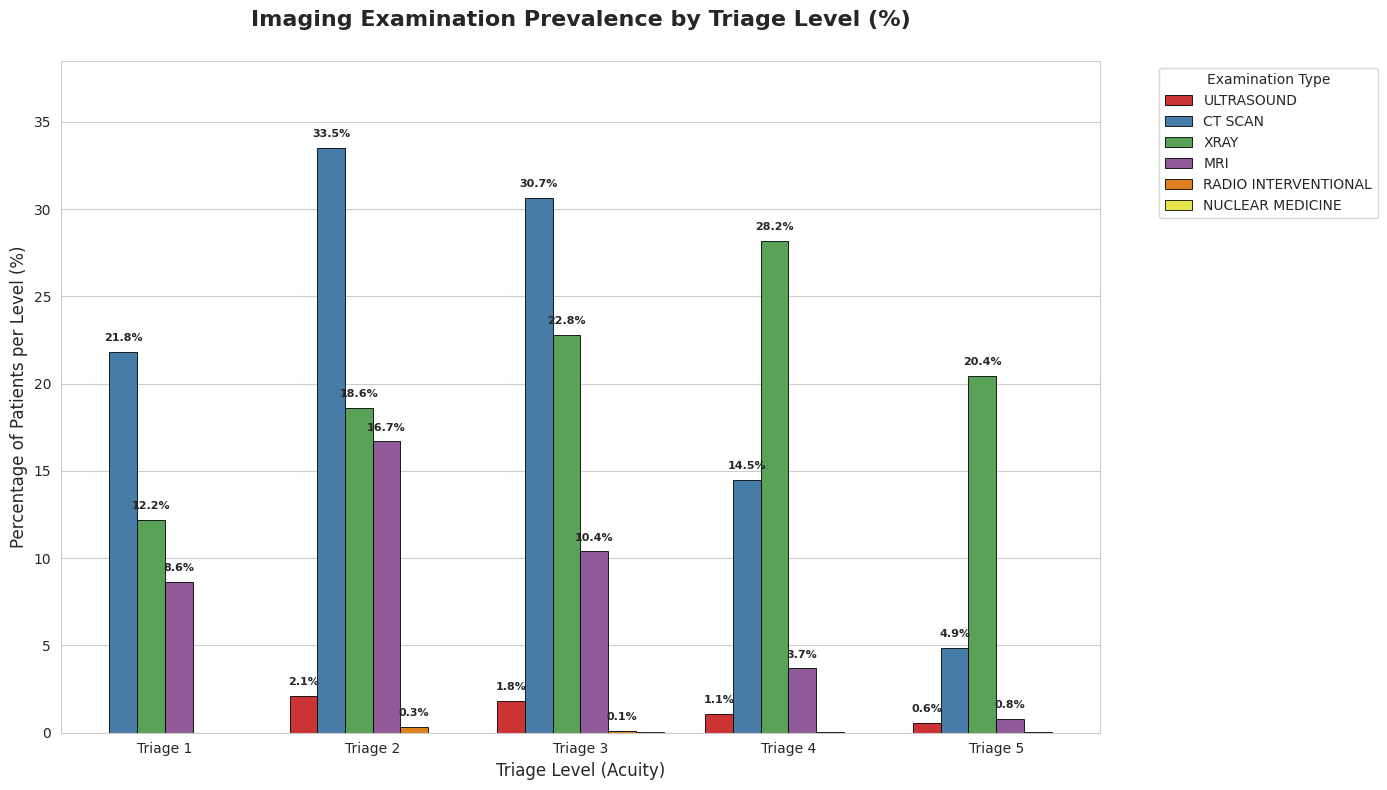

In [93]:
#=======================
# DATA CHECK (check that every patient who has an exam 2 ou 3 or more have an exam 1)
#=====================
# Define the prefixes to check
categories = ['scanner_', 'radio_conventional_', 'mri_', 'echography_', 'nuclear_medicine_']

print("🔍 CHECKING DATA SEQUENCING (Left-to-Right filling)")
print("-" * 50)

for prefix in categories:
    # Get columns for this category in order (1, 2, 3...)
    cols = sorted([c for c in df.columns if c.startswith(prefix)])

    if len(cols) > 1:
        # Check if any patient has 'NONE' in col_N but something in col_N+1
        violations = df[
            (df[cols[0]] == "NONE") &
            (df[cols[1:]].ne("NONE").any(axis=1))
        ]

        if len(violations) > 0:
            print(f"⚠️  ALERT: {len(violations)} patients have gaps in {prefix.upper()}!")
            print(f"   (Exam 2 or 3 exists, but Exam 1 is 'NONE')")
        else:
            print(f"✅ {prefix.upper().replace('_', '')} sequencing is perfect.")

print("-" * 50)

# ================================================================
# 1. DATA PREPARATION
# ================================================================
df_plot = df.copy()

# Standardize Triage labels
df_plot['triage_label'] = 'Triage ' + df_plot['triage'].astype(int).astype(str)

# Identify imaging columns (excluding global flags and oxygen)
imaging_flags = [c for c in df_plot.columns if c.startswith('has_')
                 and c not in ['has_imaging_any', 'has_o2_support']]

# ================================================================
# 2. CALCULATIONS (COUNTS & PERCENTAGES)
# ================================================================
# 1. Raw Counts (N) - Forced to int to allow summation
repartition_counts = df_plot.groupby('triage_label')[imaging_flags].agg(lambda x: x.astype(int).sum())

# 2. Percentages (%)
totals_per_triage = df_plot['triage_label'].value_counts()
repartition_pct = repartition_counts.div(totals_per_triage, axis=0) * 100

# ================================================================
# 3. SUMMARY TABLE (DISPLAY)
# ================================================================
print("📊 IMAGING DISTRIBUTION BY TRIAGE LEVEL (PERCENTAGES)")

excluded_cols = [
    "has_blood_test",
    "has_blood_gas",
    "has_culture",
    "has_lumbar_puncture"
]

summary_table = repartition_pct.drop(
    columns=[col for col in excluded_cols if col in repartition_pct.columns]
).round(2).copy()

summary_table.columns = [c.replace('has_', '').upper() for c in summary_table.columns]

display(summary_table)

# ================================================================
# 4. VISUALIZATION (HIGH-CONTRAST BAR CHART)
# ================================================================


repartition_pct_filtered = repartition_pct.drop(
    columns=[col for col in excluded_cols if col in repartition_pct.columns]
)

# Melt for Seaborn
df_long = repartition_pct_filtered.reset_index().melt(
    id_vars='triage_label',
    var_name='Exam Type',
    value_name='% Patients'
)

df_long['Exam Type'] = (
    df_long['Exam Type']
    .str.replace('has_', '', regex=False)
    .str.replace('_', ' ', regex=False)
    .str.upper()
)

plt.figure(facecolor='white', figsize=(14, 8))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df_long,
    x='triage_label',
    y='% Patients',
    hue='Exam Type',
    palette='Set1',
    edgecolor='black',
    linewidth=0.6
)

plt.title('Imaging Examination Prevalence by Triage Level (%)', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Percentage of Patients per Level (%)', fontsize=12)
plt.xlabel('Triage Level (Acuity)', fontsize=12)
plt.legend(title='Examination Type', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

# Add percentage labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0.1:
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='center',
            xytext=(0, 10),
            textcoords='offset points',
            fontsize=8,
            fontweight='bold'
        )

plt.ylim(0, df_long['% Patients'].max() * 1.15)
plt.tight_layout()
plt.savefig(f"{output_dir}/imaging_by_triage.png")
plt.show()

📦 RAW VOLUME: TOP 15 SPECIFIC EXAMS


,Exam Label,Total Count
0,xray emergency survey,5658
1,ct head / brain,3929
2,ct abdomen pelvis,2959
3,mri angiography brain,2715
4,xray chest,2121
5,mri stroke protocol,1078
6,ct brain facial bones,929
7,mri brain,927
8,ct angiography brain neck,907
9,ct angiography chest pulmonary embolism,767


/tmp/ipykernel_937122/2283574855.py:45: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




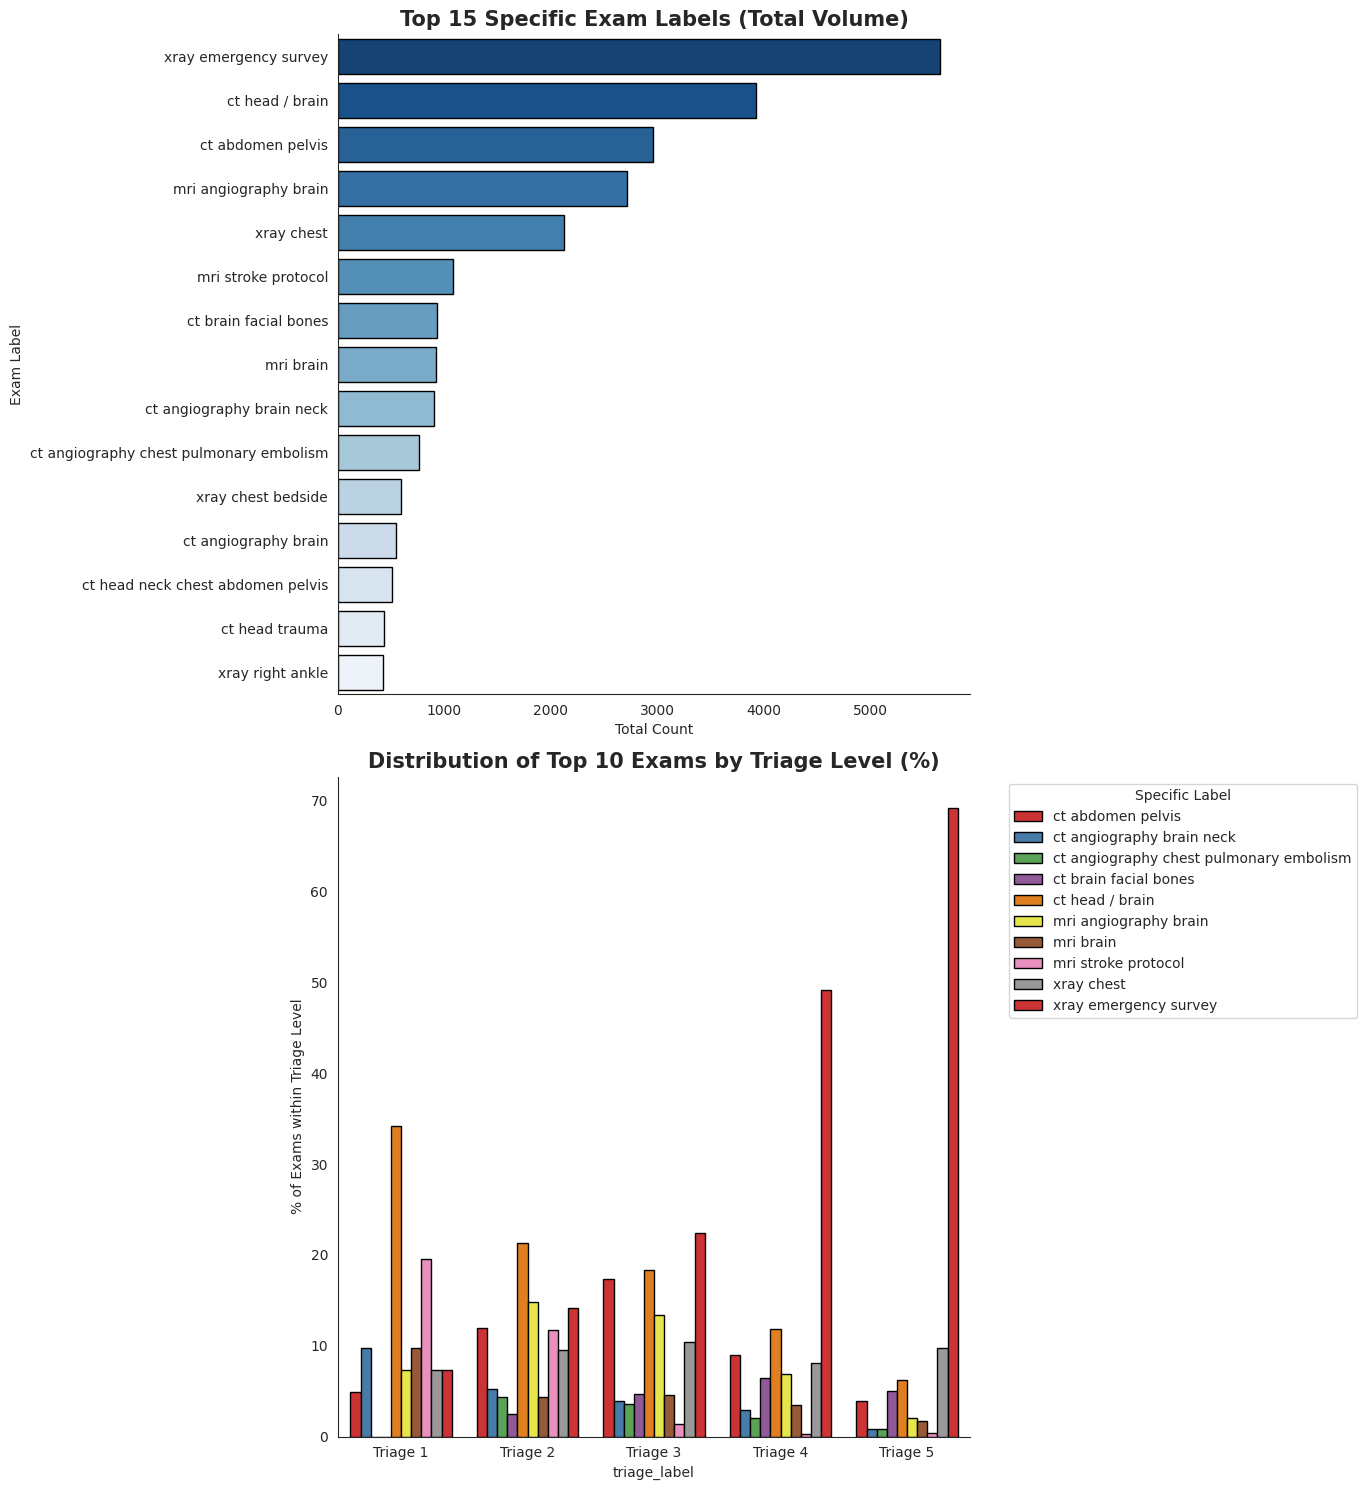

In [94]:
# ================================================================
# 1. MELTING THE DATA (From Wide to Long)
# ================================================================
# We identify all columns that contain the actual exam labels
label_cols = [c for c in df.columns if any(x in c for x in ['ct_scan_', 'xray_', 'mri_', 'ultrasound_', 'radio_interventional_', 'nuclear_medecine_'])]

# We melt the dataframe: one row per exam per patient
df_long_labels = df.melt(
    id_vars=['nda', 'triage'],
    value_vars=label_cols,
    var_name='Column_Source',
    value_name='Exam_Label'
)

# Filter out 'NONE' and empty values
df_long_labels = df_long_labels[df_long_labels['Exam_Label'] != "NONE"].copy()
df_long_labels['triage_label'] = 'Triage ' + df_long_labels['triage'].astype(int).astype(str)

# ================================================================
# 2. RAW DISTRIBUTION (TOP 15 MOST FREQUENT EXAMS)
# ================================================================
raw_dist = df_long_labels['Exam_Label'].value_counts().reset_index()
raw_dist.columns = ['Exam Label', 'Total Count']

print("📦 RAW VOLUME: TOP 15 SPECIFIC EXAMS")
display(raw_dist.head(15))

# ================================================================
# 3. DISTRIBUTION BY TRIAGE (NORMALIZED)
# ================================================================
# We look at the top 10 exams overall and see how they are distributed across triage levels
top_10_names = raw_dist.head(10)['Exam Label'].tolist()
df_top_10 = df_long_labels[df_long_labels['Exam_Label'].isin(top_10_names)]

# Create a cross-tabulation (Count of exam per triage)
triage_dist = pd.crosstab(df_top_10['triage_label'], df_top_10['Exam_Label'], normalize='index') * 100

# ================================================================
# 4. VISUALIZATION (CLEAN WHITE)
# ================================================================
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 15), facecolor='white')

# Plot 1: Raw Volume
sns.barplot(data=raw_dist.head(15), x='Total Count', y='Exam Label', palette='Blues_r', ax=ax1, edgecolor='black')
ax1.set_title('Top 15 Specific Exam Labels (Total Volume)', fontsize=15, fontweight='bold')
ax1.set_facecolor('white')

# Plot 2: Top 10 Exams across Triage Levels
triage_plot_data = triage_dist.reset_index().melt(id_vars='triage_label', value_name='% of Exams')
sns.barplot(data=triage_plot_data, x='triage_label', y='% of Exams', hue='Exam_Label', palette='Set1', ax=ax2, edgecolor='black')
ax2.set_title('Distribution of Top 10 Exams by Triage Level (%)', fontsize=15, fontweight='bold')
ax2.set_ylabel('% of Exams within Triage Level')
ax2.legend(title='Specific Label', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.set_facecolor('white')

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/top_exam_labels_by_triage.png")
plt.show()


✅ Analysis of pre-existing count columns:


,Category,Total Patients,Single Exam (n),Multiple Exams (n),Multi-Exam Rate (%)
1,XRAY,13048,12633,415,3.18
0,CT SCAN,14253,13955,298,2.09
2,MRI,5444,5371,73,1.34
3,ULTRASOUND,913,895,18,1.97
4,NUCLEAR MEDICINE,7,5,2,28.57
5,RADIO INTERVENTIONAL,81,80,1,1.23


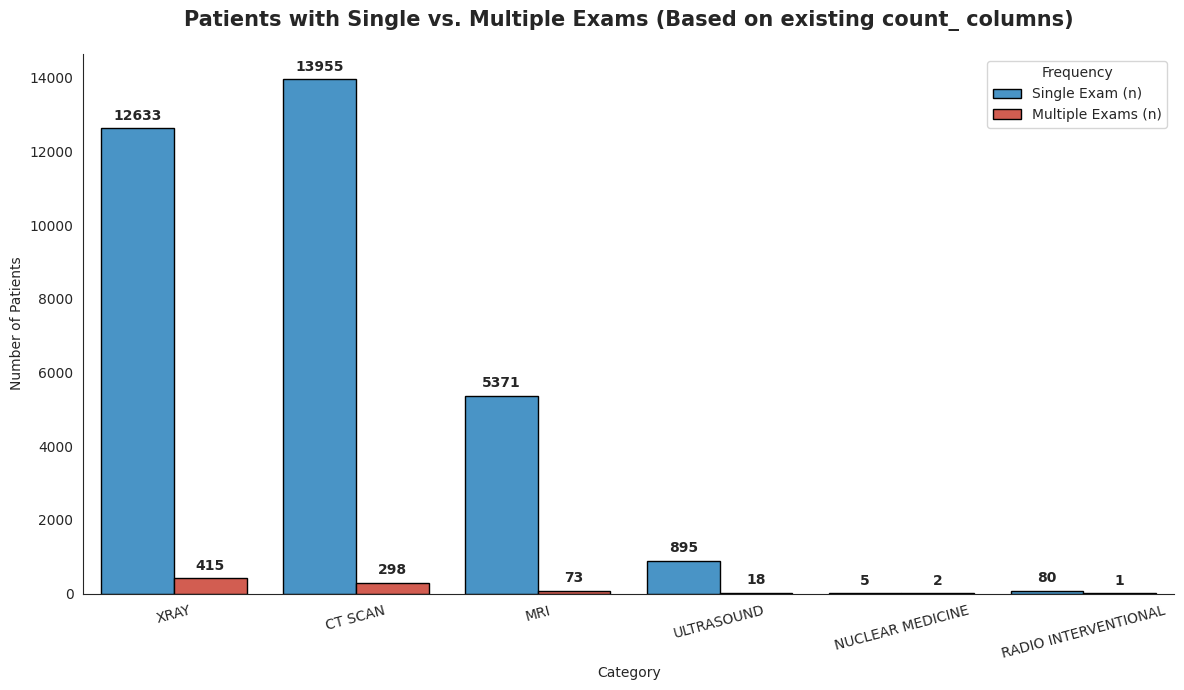

In [95]:
# ================================================================
#  CONFIGURATION (Basée sur tes colonnes existantes)
# ================================================================
# On définit les catégories pour faire le lien avec tes colonnes count_
imaging_types = ['ct_scan', 'xray', 'mri', 'ultrasound',
                 'nuclear_medicine', 'radio_interventional']

# ================================================================
#  ANALYZE MULTIPLE EXAMS PER PATIENT
# ================================================================
multi_exam_stats = []

for cat in imaging_types:
    col = f'count_{cat}'

    if col in df.columns:
        category_label = cat.upper().replace('_', ' ')

        # Filter patients with at least 1 exam of this type
        # On s'assure que c'est bien numérique
        active_patients = df[df[col] > 0]
        total_active = len(active_patients)

        if total_active > 0:
            single = len(active_patients[active_patients[col] == 1])
            multiple = len(active_patients[active_patients[col] >= 2])

            multi_exam_stats.append({
                'Category': category_label,
                'Total Patients': total_active,
                'Single Exam (n)': single,
                'Multiple Exams (n)': multiple,
                'Multi-Exam Rate (%)': round((multiple / total_active) * 100, 2)
            })

# ================================================================
#  DISPLAY & VISUALIZATION
# ================================================================
if not multi_exam_stats:
    print("❌ Error: No 'count_' columns found in the dataframe. Please check your CSV column names.")
else:
    df_results = pd.DataFrame(multi_exam_stats).sort_values(by='Multiple Exams (n)', ascending=False)

    print("\n✅ Analysis of pre-existing count columns:")
    display(df_results)

    # Plotting
    sns.set_style("white")
    plt.figure(figsize=(12, 7), facecolor='white')

    # On prépare les données pour Seaborn
    df_plot = df_results.melt(id_vars='Category',
                               value_vars=['Single Exam (n)', 'Multiple Exams (n)'],
                               var_name='Frequency', value_name='Patient Count')

    ax = sns.barplot(data=df_plot, x='Category', y='Patient Count', hue='Frequency',
                     palette=['#3498db', '#e74c3c'], edgecolor='black')

    plt.title('Patients with Single vs. Multiple Exams (Based on existing count_ columns)',
              fontsize=15, fontweight='bold', pad=20)
    plt.ylabel('Number of Patients')
    plt.xticks(rotation=15)
    plt.legend(title='Frequency')

    # Annotate bars
    for p in ax.patches:
        height = int(p.get_height())
        if height > 0:
            ax.annotate(f'{height}', (p.get_x() + p.get_width()/2., height),
                        ha='center', va='center', xytext=(0, 9),
                        textcoords='offset points', fontweight='bold')

    sns.despine()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/single_vs_multiple_exams.png")
plt.show()

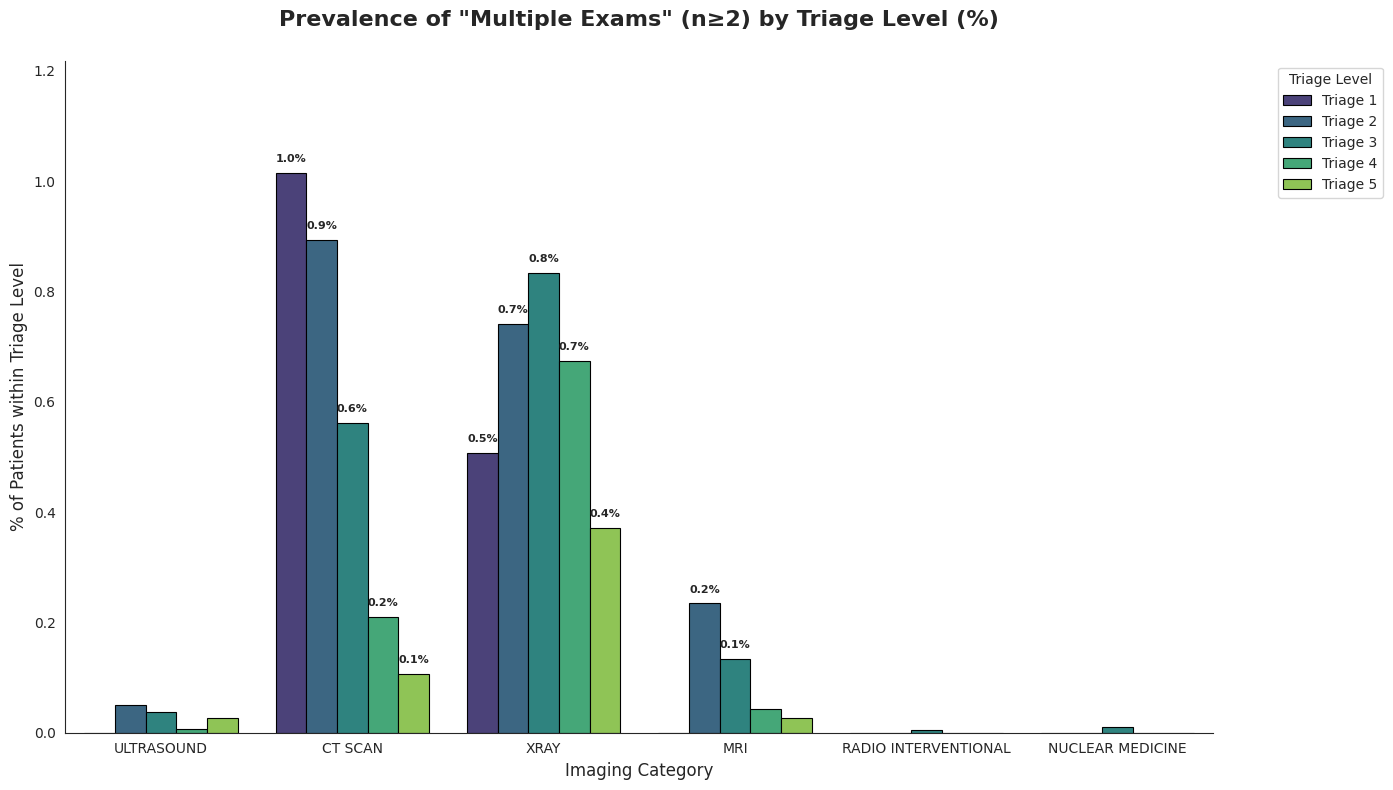

In [96]:
# ================================================================
# 1. CALCULATE PERCENTAGES BY TRIAGE LEVEL
# ================================
# Identify our count columns again
count_cols = [c for c in df.columns if c.startswith('count_')]

# Calculate total patients per triage level for normalization
triage_totals = df['triage_label'].value_counts()

multi_pct_data = []

for col in count_cols:
    exam_category = col.replace('count_', '').upper().replace('_', ' ')

    # Count how many patients in each triage have >= 2 exams
    multi_counts = df[df[col] >= 2].groupby('triage_label').size()

    # Convert to percentage relative to the TOTAL number of patients in that Triage
    multi_pct = (multi_counts / triage_totals * 100).fillna(0).reset_index()
    multi_pct.columns = ['Triage', 'Percentage']
    multi_pct['Exam_Category'] = exam_category

    multi_pct_data.append(multi_pct)

# Combine results
df_multi_pct = pd.concat(multi_pct_data, ignore_index=True)

# ================================================================
# 2. VISUALIZATION (CLEAN WHITE THEME)
# ================================
sns.set_style("white")
plt.figure(figsize=(14, 8), facecolor='white')

# Create the bar plot
ax = sns.barplot(
    data=df_multi_pct,
    x='Exam_Category',
    y='Percentage',
    hue='Triage',
    palette='viridis',
    edgecolor='black',
    linewidth=0.8
)

# Styling
plt.title('Prevalence of "Multiple Exams" (n≥2) by Triage Level (%)', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('% of Patients within Triage Level', fontsize=12)
plt.xlabel('Imaging Category', fontsize=12)
plt.legend(title='Triage Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels
for p in ax.patches:
    height = p.get_height()
    if height > 0.1: # Display only for significant values
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 10),
                    textcoords='offset points', fontsize=8, fontweight='bold')

sns.despine()
plt.ylim(0, df_multi_pct['Percentage'].max() * 1.2) # Add space for labels
plt.tight_layout()
plt.savefig(f"{output_dir}/multi_exam_pct_by_triage.png")
plt.show()

📊 AVERAGE IMAGING INTENSITY PER TRIAGE LEVEL


,Triage Level,Average Exam Count
0,Triage 1,0.44
1,Triage 2,0.73
2,Triage 3,0.67
3,Triage 4,0.48
4,Triage 5,0.27


/tmp/ipykernel_937122/911384769.py:38: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




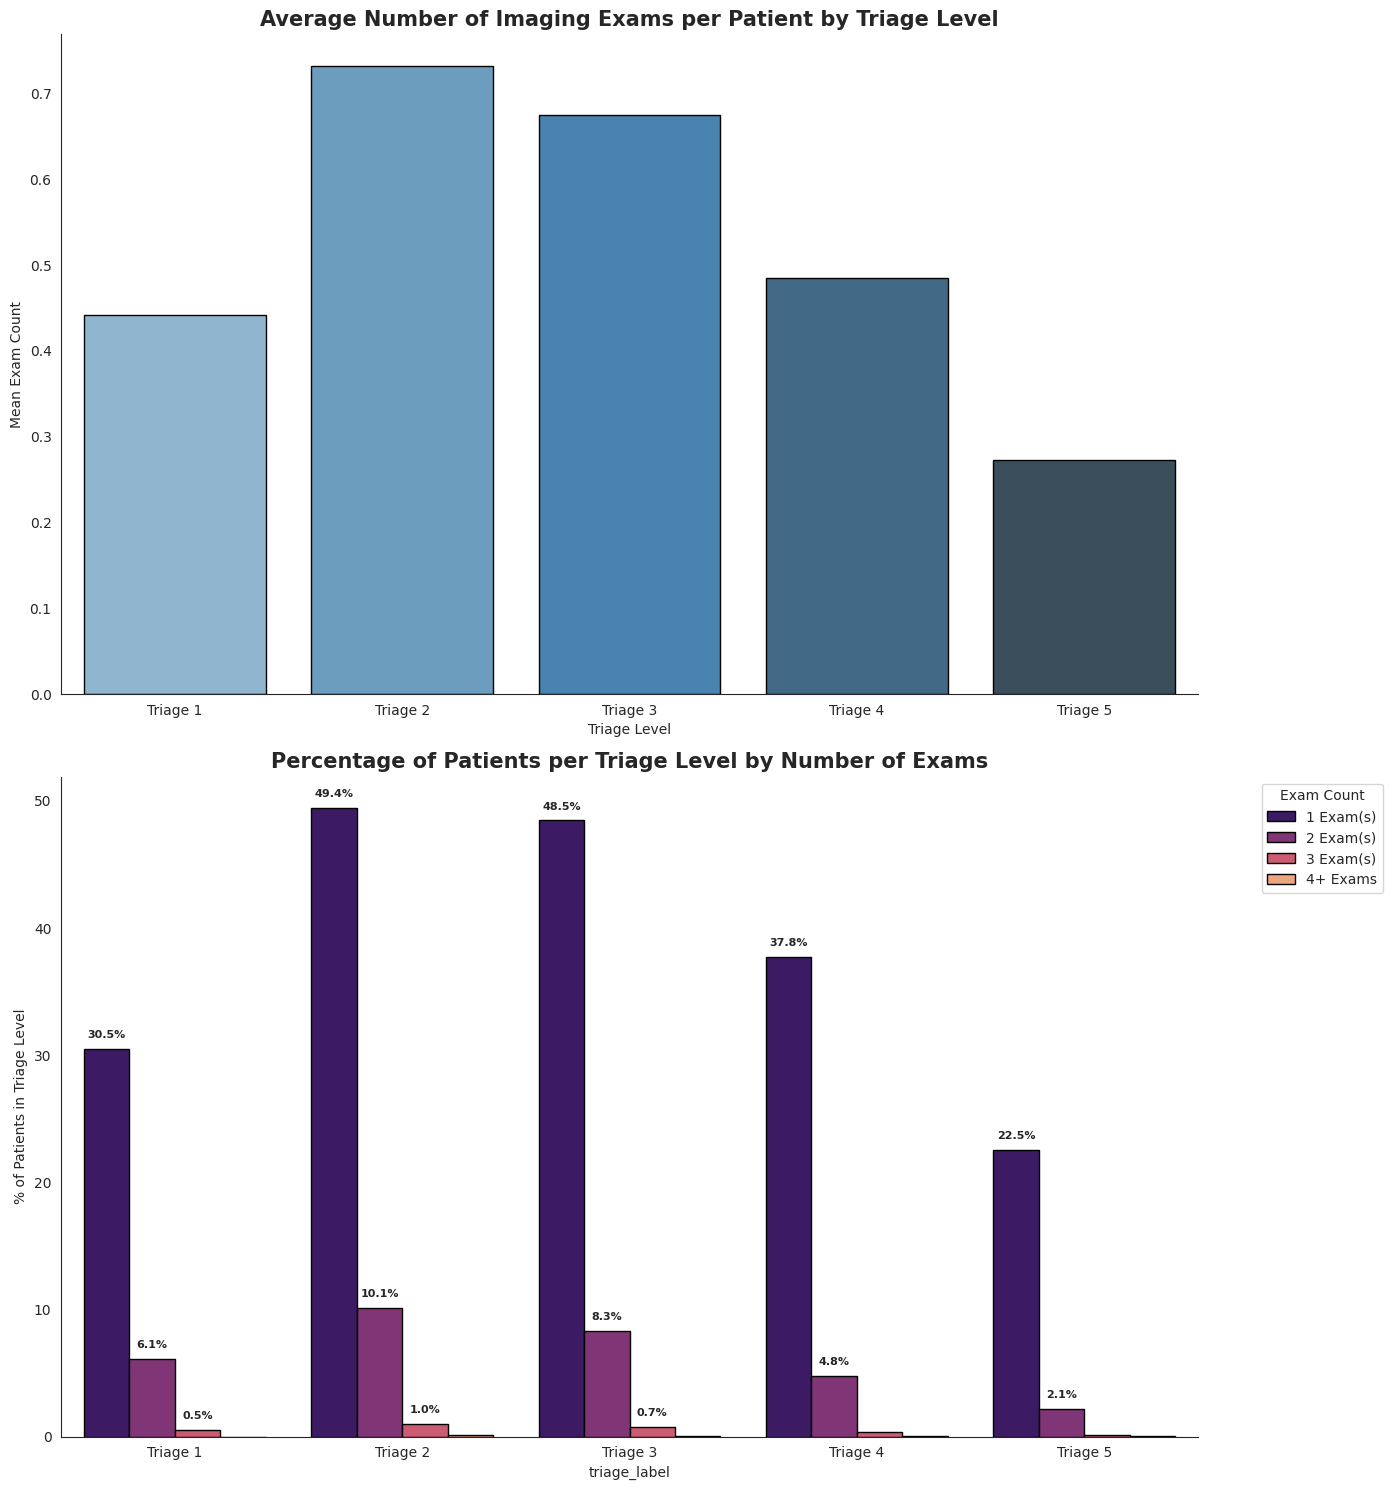

In [97]:
# ================================================================
# 1. MEAN TOTAL_EXAM_COUNT PER TRIAGE
# ================================================================

# Calculate the average intensity per level
mean_intensity = df.groupby('triage_label')['imaging_exam_count'].mean().reset_index()
mean_intensity.columns = ['Triage Level', 'Average Exam Count']

print("📊 AVERAGE IMAGING INTENSITY PER TRIAGE LEVEL")
display(mean_intensity.round(2))

# ================================================================
# 2. PERCENTAGE OF PATIENTS BY EXAM VOLUME (1, 2, 3, 4+)
# ================================================================
# We define groups for the number of exams
def group_exam_counts(x):
    if x == 0: return '0 Exams'
    if x >= 4: return '4+ Exams'
    return f'{int(x)} Exam(s)'

df['exam_volume_group'] = df['imaging_exam_count'].apply(group_exam_counts)

# Calculate the distribution: % of Triage X that has Y exams
volume_dist = pd.crosstab(df['triage_label'], df['exam_volume_group'], normalize='index') * 100

# Reorder columns for a logical progression (1, 2, 3, 4+)
# Note: We exclude '0 Exams' if you only want to see patients with imaging
desired_order = ['1 Exam(s)', '2 Exam(s)', '3 Exam(s)', '4+ Exams']
volume_dist = volume_dist.reindex(columns=[c for c in desired_order if c in volume_dist.columns])

# ================================================================
# 3. VISUALIZATION (CLEAN WHITE THEME)
# ================================================================
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 15), facecolor='white')

# --- Plot 1: Mean Intensity (Line/Bar) ---
sns.barplot(data=mean_intensity, x='Triage Level', y='Average Exam Count',
            palette='Blues_d', ax=ax1, edgecolor='black')
ax1.set_title('Average Number of Imaging Exams per Patient by Triage Level', fontsize=15, fontweight='bold')
ax1.set_ylabel('Mean Exam Count')

# --- Plot 2: Percentage Distribution (1, 2, 3, 4+) ---
plot_data_long = volume_dist.reset_index().melt(id_vars='triage_label', var_name='Volume', value_name='Percentage')
sns.barplot(data=plot_data_long, x='triage_label', y='Percentage', hue='Volume',
            palette='magma', ax=ax2, edgecolor='black')

ax2.set_title('Percentage of Patients per Triage Level by Number of Exams', fontsize=15, fontweight='bold')
ax2.set_ylabel('% of Patients in Triage Level')
ax2.legend(title='Exam Count', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels
for p in ax2.patches:
    h = p.get_height()
    if h > 0.5:
        ax2.annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='center', xytext=(0, 10),
                     textcoords='offset points', fontsize=8, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/imaging_intensity_by_triage.png")
plt.show()

In [98]:
# ======================================================================
# IMAGING EXAM REPARTITION (ORGAN/TEXT CONTENT ONLY)
# ======================================================================


# 1. Manually define or strictly filter content columns
# We exclude any column starting with 'has_' to avoid binary flags
imaging_groups = {
    'Scanner': [c for c in df.columns if 'ct_scan_' in c and not c.startswith('has_')],
    'MRI': [c for c in df.columns if 'mri_' in c and not c.startswith('has_')],
    'Conventional Radio': [c for c in df.columns if 'xray_' in c and not c.startswith('has_')],
    'Ultrasound': [c for c in df.columns if 'ultrasound_' in c and not c.startswith('has_')],
    'Interventional': [c for c in df.columns if 'radio_interventional_' in c and not c.startswith('has_')],
    'Nuclear Medicine': [c for c in df.columns if 'nuclear_medicine_' in c and not c.startswith('has_')]
}

def get_imaging_stats_refined(sub_df):
    """
    Calculates stats using only the text columns containing exam names.
    Ignores binary summary flags and 'NONE' entries.
    """
    stats = {}
    total_patients = len(sub_df)

    if total_patients == 0:
        return pd.DataFrame()

    for group, cols in imaging_groups.items():
        if not cols: # Skip if no columns were found for this category
            continue

        # Create mask: True only if value is not 'NONE', not NaN, and not a 0/1 flag
        # We ensure we are looking at the string content
        group_data = sub_df[cols]
        mask = group_data.notna() & (group_data.astype(str) != 'NONE') & (group_data.astype(str) != '0')

        total_exams = mask.sum().sum()
        patients_with_exam = mask.any(axis=1).sum()

        stats[group] = {
            'Total Exams Count': int(total_exams),
            'Patients Count': int(patients_with_exam),
            '% of Sub-Population': round((patients_with_exam / total_patients) * 100, 1)
        }
    return pd.DataFrame(stats).T

# 2. Execution
stats_all = get_imaging_stats_refined(df)
stats_imaging_only = get_imaging_stats_refined(df[df['has_imaging_any'] == 1])

print("📊 STATS: GENERAL POPULATION")
display(stats_all)

print("\n🔍 STATS: IMAGING POPULATION (has_imaging_any == 1)")
display(stats_imaging_only)

📊 STATS: GENERAL POPULATION


,Total Exams Count,Patients Count,% of Sub-Population
Scanner,14557.0,14253.0,25.1
MRI,5518.0,5444.0,9.6
Conventional Radio,13481.0,13048.0,23.0
Ultrasound,931.0,913.0,1.6
Interventional,82.0,81.0,0.1
Nuclear Medicine,9.0,7.0,0.0



🔍 STATS: IMAGING POPULATION (has_imaging_any == 1)


,Total Exams Count,Patients Count,% of Sub-Population
Scanner,14557.0,14253.0,48.3
MRI,5518.0,5444.0,18.4
Conventional Radio,13481.0,13048.0,44.2
Ultrasound,931.0,913.0,3.1
Interventional,82.0,81.0,0.3
Nuclear Medicine,9.0,7.0,0.0


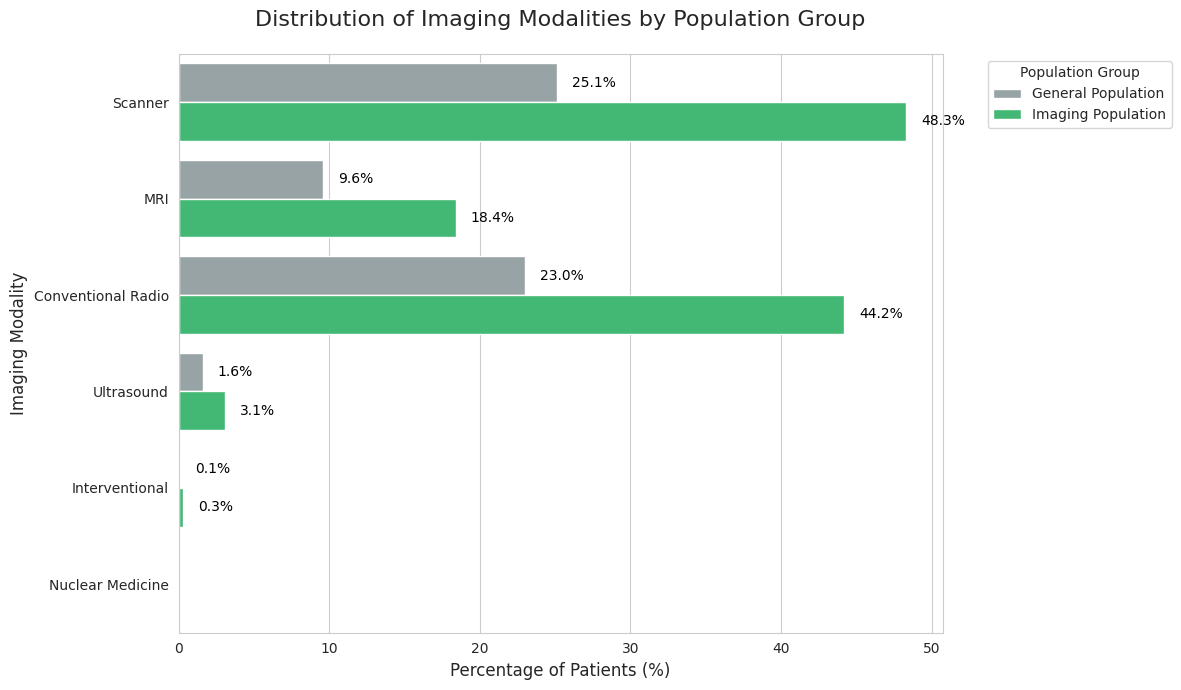

In [99]:
# ======================================================================
# GRAPH: IMAGING MODALITIES DISTRIBUTION
# ======================================================================

# 1. Prepare data for plotting
# We combine both dataframes into a long format for Seaborn
stats_all['Population'] = 'General Population'
stats_imaging_only['Population'] = 'Imaging Population'

df_plot = pd.concat([
    stats_all.reset_index().rename(columns={'index': 'Modality'}),
    stats_imaging_only.reset_index().rename(columns={'index': 'Modality'})
])

# 2. Plotting
plt.figure(facecolor='white', figsize=(12, 7))
sns.set_style("whitegrid")

# Create the grouped bar chart
ax = sns.barplot(
    data=df_plot,
    x='% of Sub-Population',
    y='Modality',
    hue='Population',
    palette=['#95a5a6', '#2ecc71'] # Grey for general, Green for specific
)

# 3. Aesthetics & Labels
plt.title('Distribution of Imaging Modalities by Population Group', fontsize=16, pad=20)
plt.xlabel('Percentage of Patients (%)', fontsize=12)
plt.ylabel('Imaging Modality', fontsize=12)
plt.legend(title='Population Group', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels on the bars for clarity
for p in ax.patches:
    width = p.get_width()
    if width > 0: # Only label bars with values
        ax.annotate(f'{width:.1f}%',
                    (width + 1, p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.savefig(f"{output_dir}/imaging_modalities_distribution.png")
plt.show()

In [100]:
# ======================================================================
# FULL LIST OF UNIQUE EXAM TYPES PER CATEGORY
# ======================================================================

def get_all_unique_modalities(sub_df):
    all_categories_report = {}

    for group, cols in imaging_groups.items():
        # 1. On récupère toutes les valeurs de toutes les colonnes du groupe
        all_values = sub_df[cols].values.flatten()

        # 2. On filtre pour ne garder que les vrais noms d'examens
        # On ignore 'NONE', '0', les NaN et les espaces vides
        filtered_values = [
            str(val).strip() for val in all_values
            if pd.notna(val) and str(val).strip() not in ['NONE', '0', 'nan', '']
        ]

        if filtered_values:
            # 3. On compte les occurrences pour chaque examen unique
            counts = pd.Series(filtered_values).value_counts()

            # 4. On crée un DataFrame propre pour cette catégorie
            df_res = pd.DataFrame({
                'Exam Name': counts.index,
                'Count': counts.values,
                'Percentage': (counts.values / counts.sum() * 100).round(2)
            })
            all_categories_report[group] = df_res

    return all_categories_report

# On génère le rapport pour la population ayant eu de l'imagerie
full_report = get_all_unique_modalities(df[df['has_imaging_any'] == 1])

# Affichage des résultats pour chaque catégorie
for group, report_df in full_report.items():
    print(f"\n{'='*50}")
    print(f"📋 CATEGORY: {group}")
    print(f"{'='*50}")
    # On affiche tout le tableau (sans limite de lignes)
    display(report_df)


📋 CATEGORY: Scanner


,Exam Name,Count,Percentage
0,ct head / brain,3929,26.99
1,ct abdomen pelvis,2959,20.33
2,ct brain facial bones,929,6.38
3,ct angiography brain neck,907,6.23
4,ct angiography chest pulmonary embolism,767,5.27
5,ct angiography brain,550,3.78
6,ct head neck chest abdomen pelvis,507,3.48
7,ct head trauma,433,2.97
8,ct chest,387,2.66
9,ct chest abdomen pelvis,326,2.24



📋 CATEGORY: MRI


,Exam Name,Count,Percentage
0,mri angiography brain,2715,49.20
1,mri stroke protocol,1078,19.54
2,mri brain,927,16.80
3,mri angiography neck brain,249,4.51
4,mri spinal cord,192,3.48
5,mri lumbar spine,152,2.75
6,mri brain and spinal cord,60,1.09
7,mri cervical spine,29,0.53
8,mri angiography spine,26,0.47
9,mri whole spine,16,0.29



📋 CATEGORY: Conventional Radio


...

,Exam Name,Count,Percentage
0,scrotal doppler ultrasound,305,32.76
1,abdomen pelvis ultrasound,255,27.39
2,venous doppler ultrasound lower limb,69,7.41
3,abdominal ultrasound,63,6.77
4,scrotal ultrasound,37,3.97
5,renal and bladder ultrasound,37,3.97
6,lower limb joint ultrasound,18,1.93
7,lower limb soft tissue ultrasound,17,1.83
8,upper limb joint ultrasound,17,1.83
9,venous doppler ultrasound upper limb,16,1.72



📋 CATEGORY: Interventional


,Exam Name,Count,Percentage
0,mechanical thrombectomy stroke,54,65.85
1,gastrostomy tube replacement,13,15.85
2,pelvic drainage,2,2.44
3,abdominal drainage,2,2.44
4,hepatic drainage,1,1.22
5,percutaneous nephrostomy,1,1.22
6,lumbar puncture,1,1.22
7,genitourinary guided biopsy,1,1.22
8,midline catheter insertion,1,1.22
9,av fistula thrombectomy,1,1.22



📋 CATEGORY: Nuclear Medicine


,Exam Name,Count,Percentage
0,lung perfusion scintigraphy,3,33.33
1,v/q lung scintigraphy pulmonary embolism,3,33.33
2,v/q lung scintigraphy pulmonary embolism krypton,2,22.22
3,pulmonary shunt scintigraphy,1,11.11


/tmp/ipykernel_937122/765104767.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_937122/765104767.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_937122/765104767.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_937122/765104767.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_937122/765104767.py:35: FutureWarning:



Passing `palette` without assigning `hue` is de

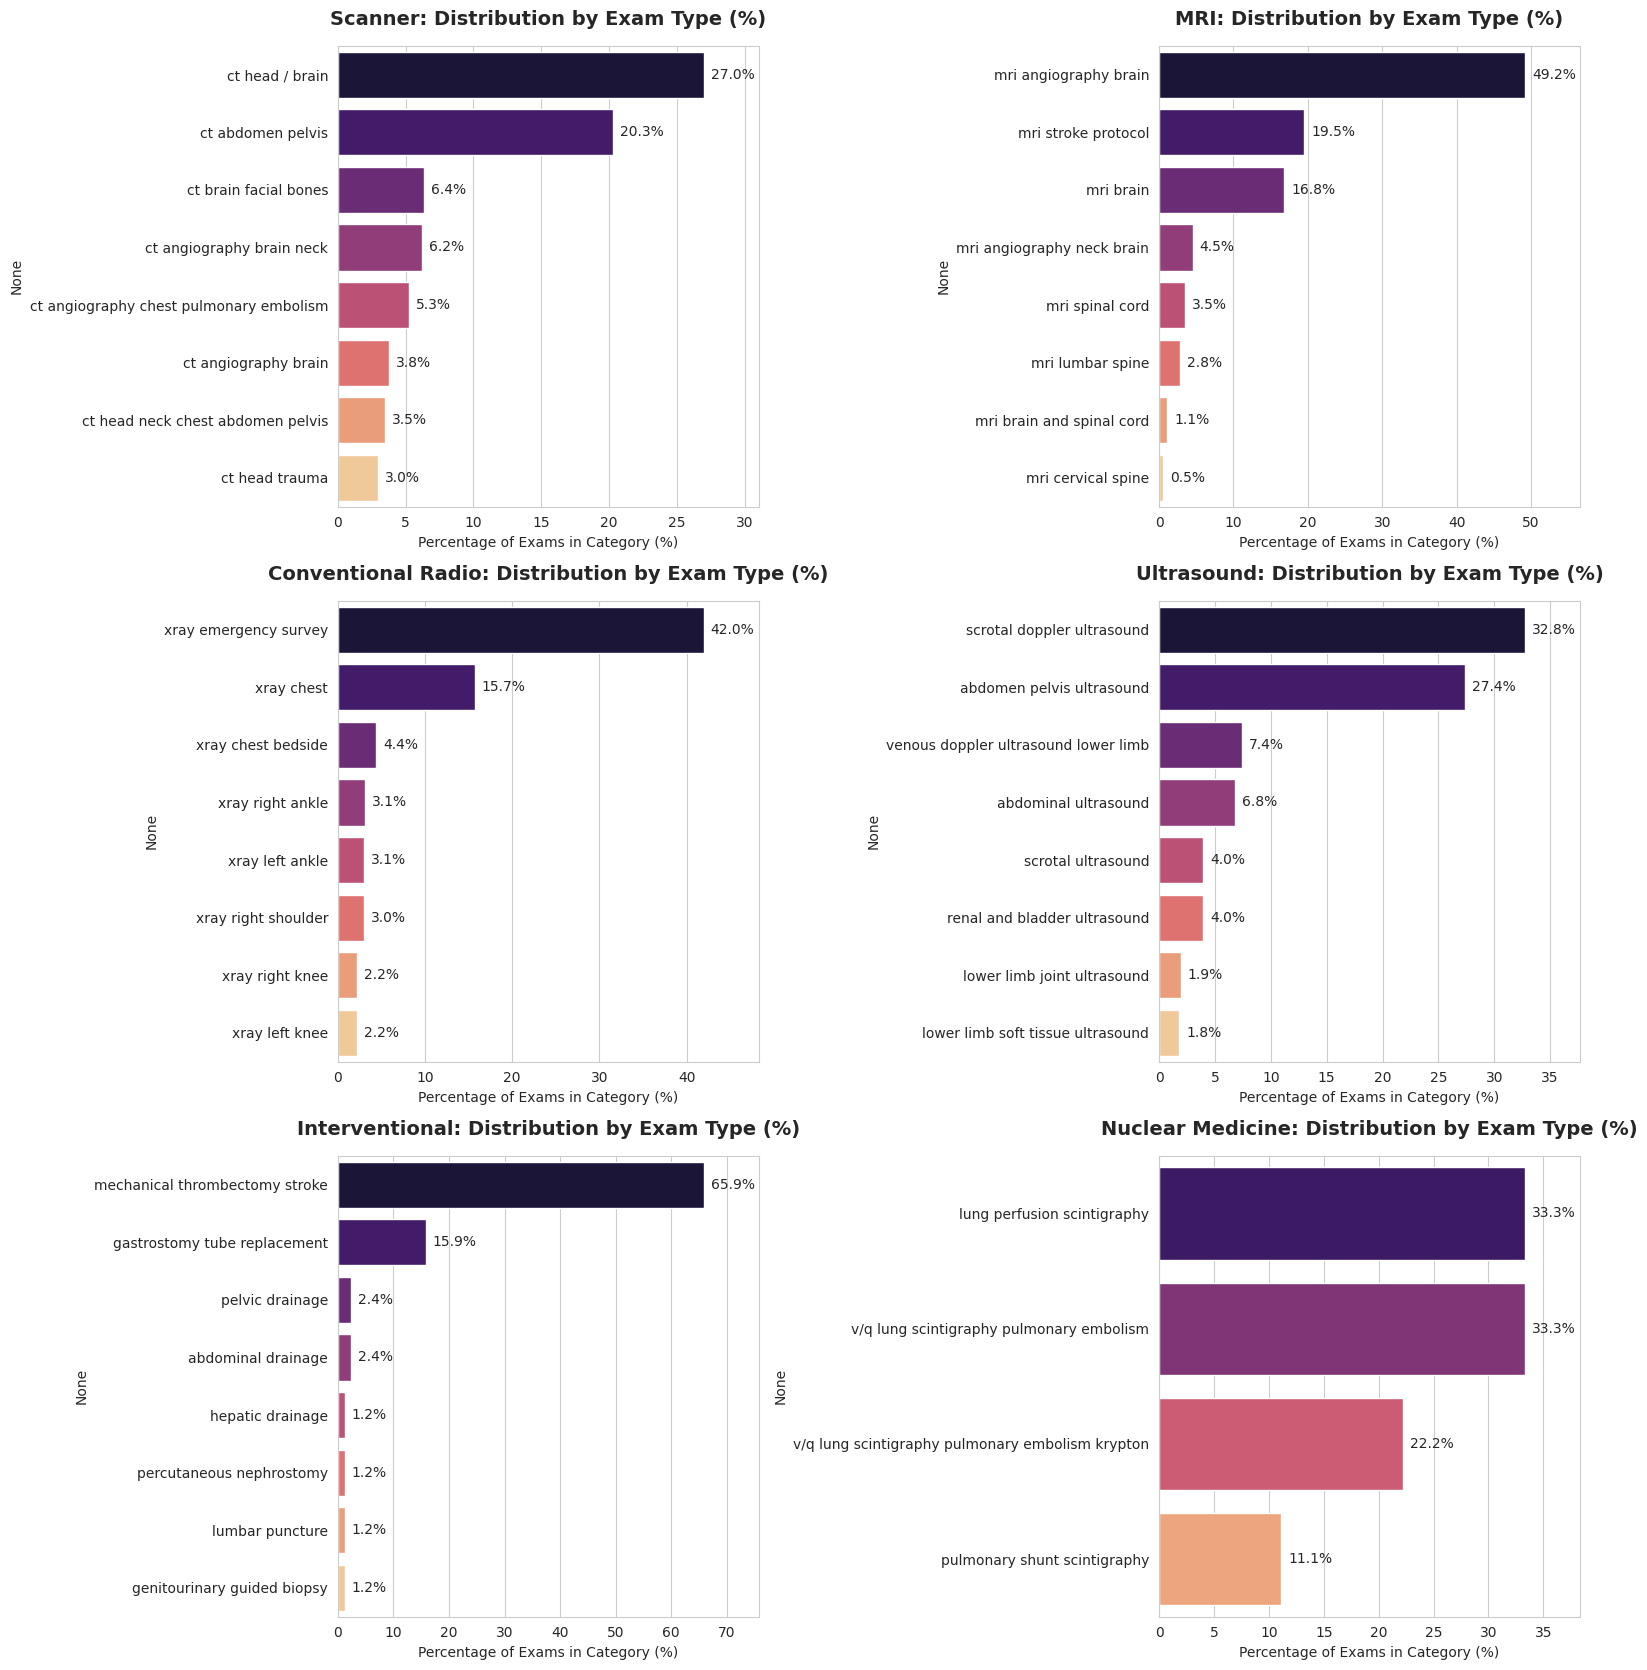

In [101]:
# ======================================================================
# PERCENTAGE BREAKDOWN OF EXAM TYPES PER CATEGORY
# ======================================================================

def get_top_exams_pct(sub_df, top_n=8):
    group_results = {}

    for group, cols in imaging_groups.items():
        # 1. Collect all valid text values
        all_values = sub_df[cols].values.flatten()
        filtered_values = [
            str(val).strip() for val in all_values
            if pd.notna(val) and str(val).strip() not in ['NONE', '0', 'nan', '']
        ]

        if filtered_values:
            # 2. Calculate Value Counts
            counts = pd.Series(filtered_values).value_counts()
            # 3. Convert to Percentage relative to the total exams in THIS group
            pcts = (counts / counts.sum()) * 100
            group_results[group] = pcts.head(top_n)

    return group_results

# Analyze the imaging population
top_exams_pct_data = get_top_exams_pct(df[df['has_imaging_any'] == 1])

# --- PLOTTING ---
n_groups = len(top_exams_pct_data)
fig, axes = plt.subplots(nrows=(n_groups + 1) // 2, ncols=2, figsize=(16, n_groups * 2.8), facecolor='white')
axes = axes.flatten()

for i, (group, data) in enumerate(top_exams_pct_data.items()):
    # Plot horizontal bars
    sns.barplot(x=data.values, y=data.index, ax=axes[i], palette='magma')

    axes[i].set_title(f'{group}: Distribution by Exam Type (%)', fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel('Percentage of Exams in Category (%)')
    axes[i].set_xlim(0, max(data.values) * 1.15) # Leave room for labels

    # Add percentage labels on the bars
    for p in axes[i].patches:
        width = p.get_width()
        axes[i].annotate(f'{width:.1f}%',
                        (width, p.get_y() + p.get_height() / 2),
                        ha='left', va='center', xytext=(5, 0),
                        textcoords='offset points', fontsize=10)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(f"{output_dir}/exam_pct_per_category.png")
plt.show()

/tmp/ipykernel_937122/1380572564.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_937122/1380572564.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_937122/1380572564.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_937122/1380572564.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_937122/1380572564.py:31: FutureWarning:



Passing `palette` without assigning `hue` 

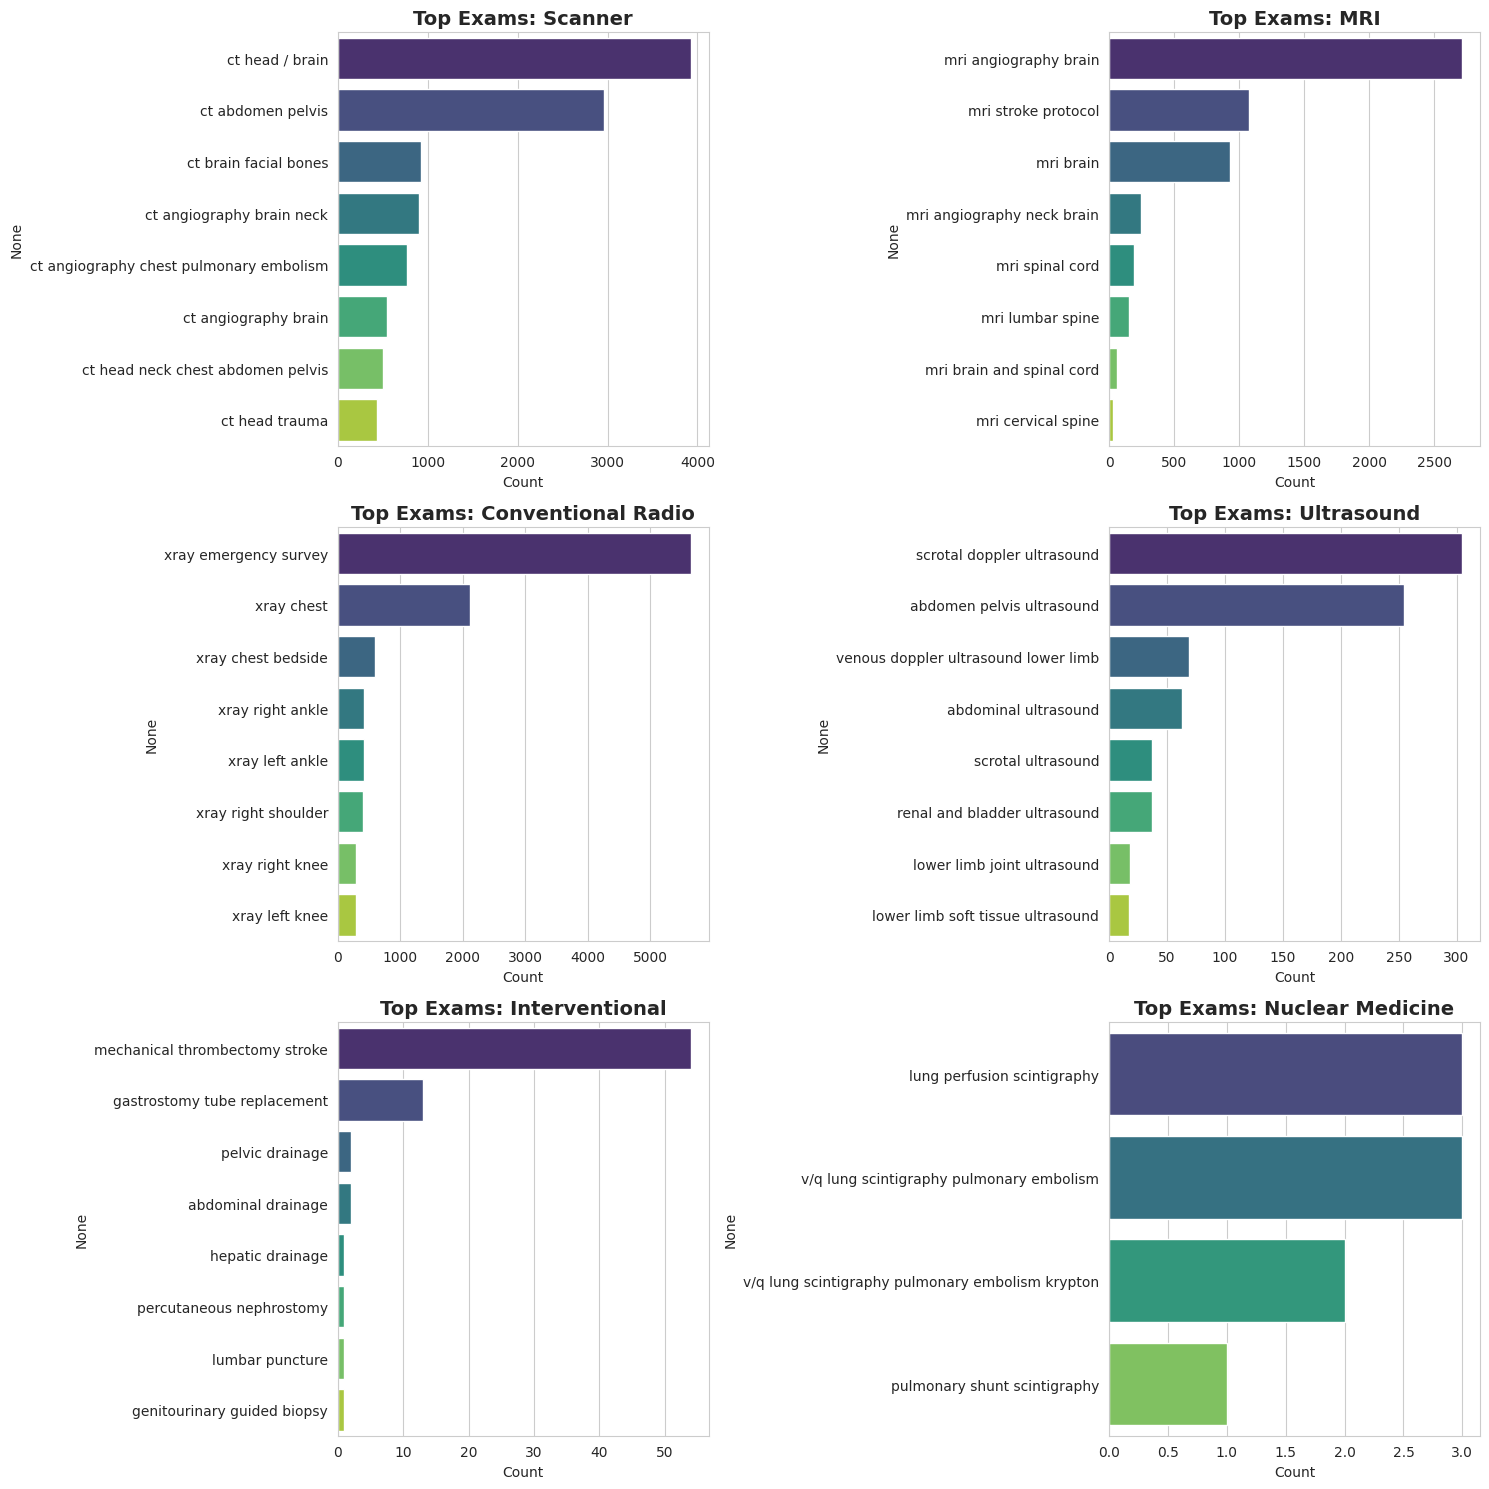

In [102]:
# ======================================================================
# BREAKDOWN OF EXAM TYPES (ORGAN/SPECIFIC) PER CATEGORY
# ======================================================================

def get_top_exams_per_group(sub_df, top_n=8):
    group_results = {}

    for group, cols in imaging_groups.items():
        # 1. Collect all non-NONE text values from all columns in the group
        all_values = sub_df[cols].values.flatten()
        # 2. Filter out NONE, NaN, 0, and empty strings
        filtered_values = [
            str(val).strip() for val in all_values
            if pd.notna(val) and str(val).strip() not in ['NONE', '0', 'nan', '']
        ]

        if filtered_values:
            group_results[group] = pd.Series(filtered_values).value_counts().head(top_n)

    return group_results

# Analyze the imaging population
top_exams_data = get_top_exams_per_group(df[df['has_imaging_any'] == 1])

# --- PLOTTING ---
n_groups = len(top_exams_data)
fig, axes = plt.subplots(nrows=(n_groups + 1) // 2, ncols=2, figsize=(15, n_groups * 2.5), facecolor='white')
axes = axes.flatten()

for i, (group, data) in enumerate(top_exams_data.items()):
    sns.barplot(x=data.values, y=data.index, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top Exams: {group}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].tick_params(axis='both', which='major', labelsize=10)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(f"{output_dir}/exam_count_per_category.png")
plt.show()

#### TRIAGE DURATION EXPLORATION BY LVL OF TRIAGE ###

📊 TRIAGE DURATION STATISTICS (Ordered 1 to 5)


,triage_label,mean,median,std
0,Triage 1,5.24,5.0,1.80
1,Triage 2,5.07,5.0,0.79
2,Triage 3,5.06,5.0,0.76
3,Triage 4,5.02,5.0,0.64
4,Triage 5,4.97,5.0,0.48


/tmp/ipykernel_937122/1024199209.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_937122/1024199209.py:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




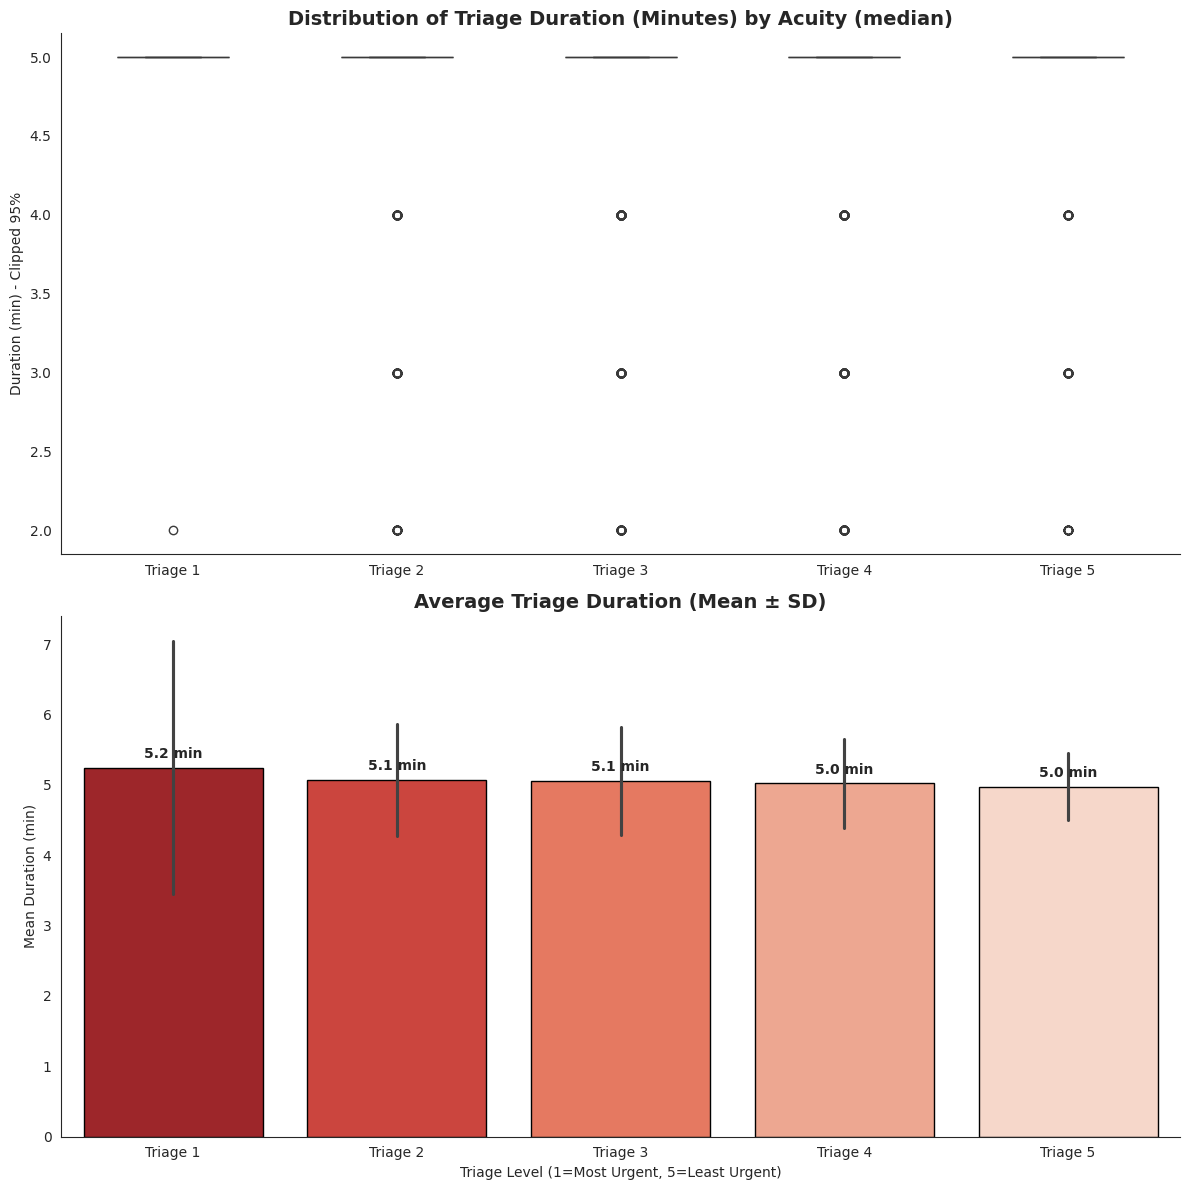

In [103]:
# ================================================================
# 1. DATA PREPARATION & ORDERING
# ================================================================
df_time = df.copy()

# Ensure triage is numeric and create the ordered string label
df_time = df_time.sort_values(by='triage')
df_time['triage_label'] = 'Triage ' + df_time['triage'].astype(int).astype(str)

# Define the explicit order for categorical plotting
triage_order = ['Triage 1', 'Triage 2', 'Triage 3', 'Triage 4', 'Triage 5']

# Filter out missing/negative values and clip outliers (95th percentile)
df_time = df_time[df_time['duration_triage_ioa_min'] > 0]
upper_limit = df_time['duration_triage_ioa_min'].quantile(0.95)
df_time_filtered = df_time[df_time['duration_triage_ioa_min'] <= upper_limit]

# ================================================================
# 2. STATISTICAL SUMMARY
# ================================================================
duration_stats = df_time.groupby('triage_label')['duration_triage_ioa_min'].agg(['mean', 'median', 'std'])
# Reindex to ensure the table follows the 1 -> 5 order
duration_stats = duration_stats.reindex(triage_order).reset_index()

print(f"📊 TRIAGE DURATION STATISTICS (Ordered 1 to 5)")
display(duration_stats.round(2))

# ================================================================
# 3. VISUALIZATION (CLEAN WHITE THEME)
# ================================================================
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), facecolor='white')

# --- Plot 1: Boxplot (Distribution) ---
sns.boxplot(data=df_time_filtered, x='triage_label', y='duration_triage_ioa_min',
            order=triage_order, palette='Reds_r', ax=ax1, width=0.5)
ax1.set_title('Distribution of Triage Duration (Minutes) by Acuity (median)', fontsize=14, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Duration (min) - Clipped 95%')

# --- Plot 2: Barplot (Average with Error Bars) ---
sns.barplot(data=df_time, x='triage_label', y='duration_triage_ioa_min',
            order=triage_order, palette='Reds_r', ax=ax2, edgecolor='black', errorbar='sd')
ax2.set_title('Average Triage Duration (Mean ± SD)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Mean Duration (min)')
ax2.set_xlabel('Triage Level (1=Most Urgent, 5=Least Urgent)')

# Add mean values on top
for p in ax2.patches:
    h = p.get_height()
    if h > 0:
        ax2.annotate(f'{h:.1f} min', (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='center', xytext=(0, 10),
                     textcoords='offset points', fontsize=10, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/triage_duration.png")
plt.show()

### Repartition of biological acts (raw and by triage level) large cut

📦 RAW GLOBAL DISTRIBUTION (BIOLOGY & PROCEDURES)


,Act Type,Total Patients
0,BLOOD_TEST,33230
2,CULTURE,8214
3,BLOOD_GAS,4448
1,LUMBAR_PUNCTURE,470


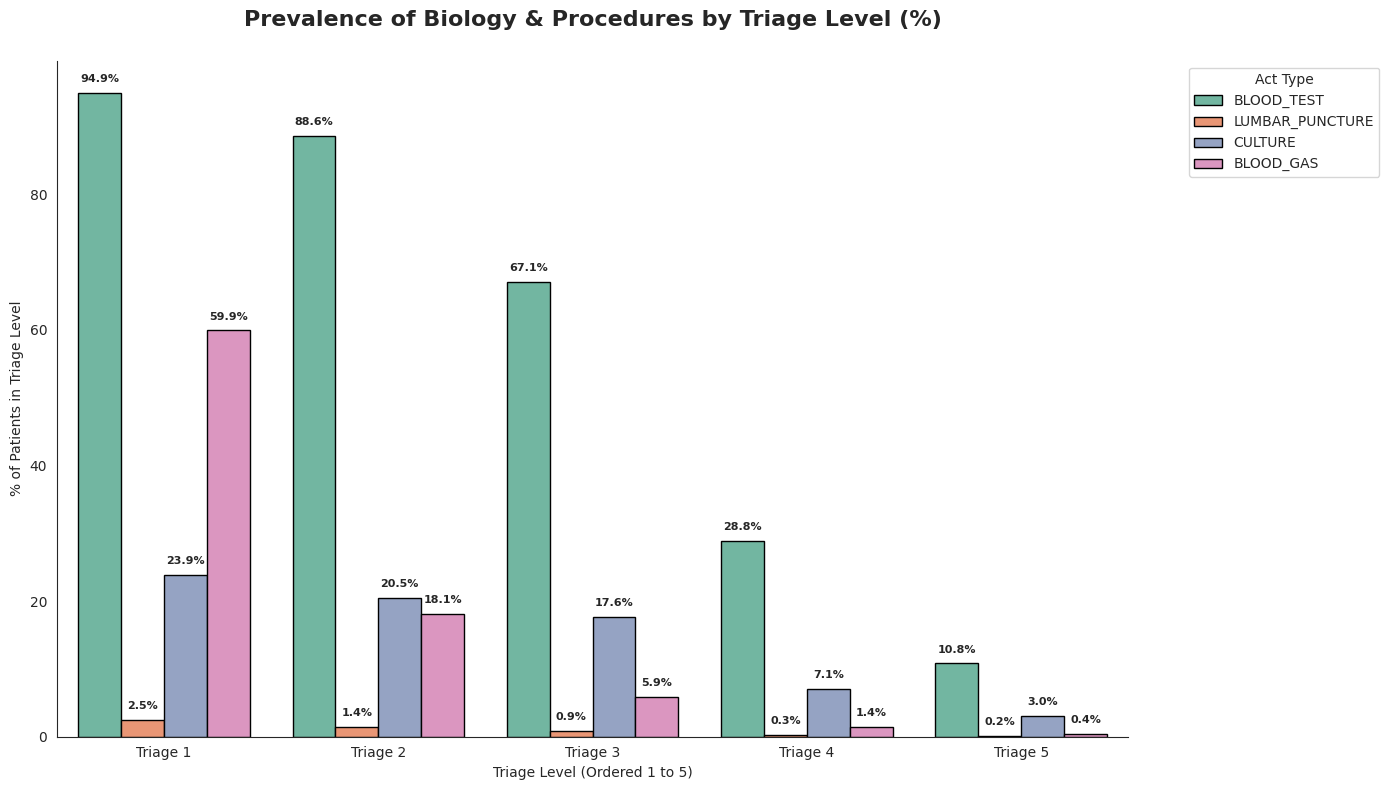

In [104]:
#================================
# Data preparation
#================================


# Lists provided by the user
cols_veinous_analysis = [
    'is_hemoglobine', 'is_leucocytes', 'is_formule_leuco', 'is_urea', 'is_creatinine',
    'is_sodium', 'is_potassium', 'is_platelets', 'is_pt', 'is_aptt',
    'is_calcium', 'is_ck', 'is_lactates', 'is_troponine', 'is_bnp',
    'is_ckmb', 'is_ddimer', 'is_crp', 'is_pct', 'is_alat',
    'is_asat', 'is_bili_total', 'is_lipase', 'is_alp', 'is_iron',
    'is_ferritin', 'is_calcium_ionized', 'is_aXa_aIIa', 'fibrinogen'
]


# Group of focus
bio_features = ['has_blood_test', 'has_lumbar_puncture', 'has_culture', 'has_blood_gas']

# Convert bio features to integers to allow summation
df[bio_features] = df[bio_features].astype(int)


#==================
# Raw counts
#==================
raw_bio_counts = df[bio_features].sum().reset_index()
raw_bio_counts.columns = ['Act Type', 'Total Patients']
raw_bio_counts['Act Type'] = raw_bio_counts['Act Type'].str.replace('has_', '').str.upper()

print("📦 RAW GLOBAL DISTRIBUTION (BIOLOGY & PROCEDURES)")
display(raw_bio_counts.sort_values(by='Total Patients', ascending=False))


#=====================
# Order by Triage
#=====================

triage_order = ['Triage 1', 'Triage 2', 'Triage 3', 'Triage 4', 'Triage 5']

# Calculate Percentages
bio_triage_dist = df.groupby('triage_label')[bio_features].mean() * 100
bio_triage_dist.columns = [c.replace('has_', '').upper() for c in bio_triage_dist.columns]
bio_triage_dist = bio_triage_dist.reindex(triage_order)

# Plotting (White Background)
sns.set_style("white")
plt.figure(figsize=(14, 8), facecolor='white')

df_plot_bio = bio_triage_dist.reset_index().melt(id_vars='triage_label', var_name='Bio Act', value_name='Percentage')

ax = sns.barplot(data=df_plot_bio, x='triage_label', y='Percentage', hue='Bio Act', palette='Set2', edgecolor='black')

plt.title('Prevalence of Biology & Procedures by Triage Level (%)', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('% of Patients in Triage Level')
plt.xlabel('Triage Level (Ordered 1 to 5)')
plt.legend(title='Act Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotations
for p in ax.patches:
    h = p.get_height()
    if h > 0.1:
        ax.annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='center', xytext=(0, 10),
                     textcoords='offset points', fontsize=8, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/biology_by_triage.png")
plt.show()

/tmp/ipykernel_937122/2931669571.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




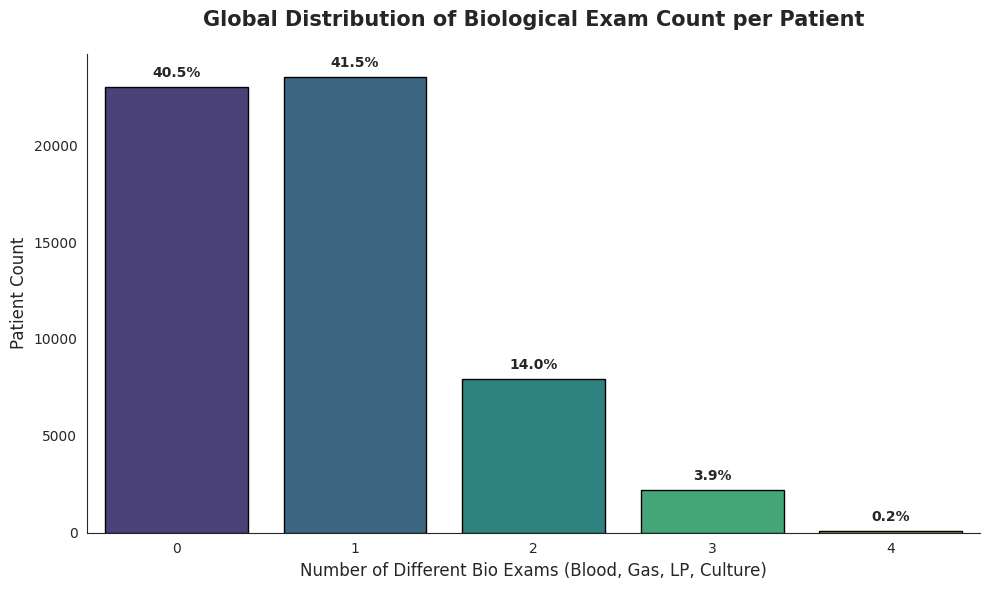

<Figure size 1200x700 with 0 Axes>

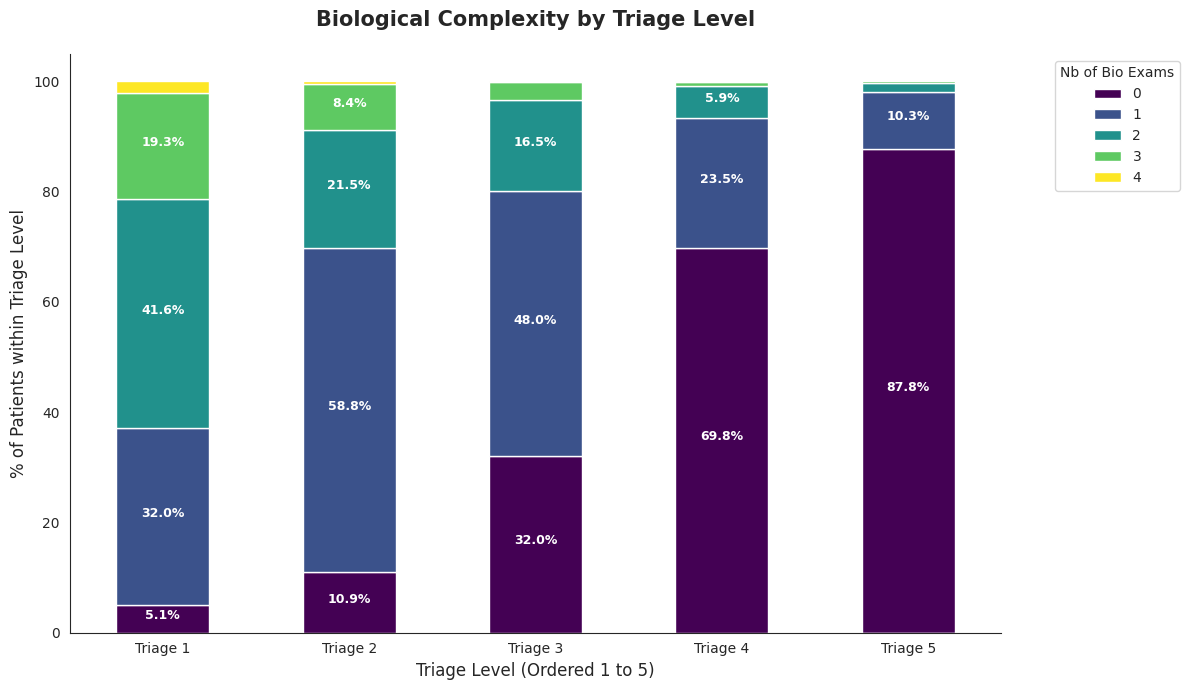

📊 BIOLOGICAL SCORE SUMMARY BY TRIAGE LEVEL:


,mean,std,max
triage_label,,,
Triage 1,1.812183,0.874966,4.0
Triage 2,1.286592,0.785730,4.0
Triage 3,0.914369,0.786924,4.0
Triage 4,0.376337,0.633227,4.0
Triage 5,0.143953,0.415326,3.0


In [123]:
#---------------------------------------------------------------------------------------------------------
# Number of bio exam per level of triage
#---------------------------------------------------------------------------------------
# Set the visual style
sns.set_style("white")

#=========================================================
# PLOT 1: GLOBAL DISTRIBUTION OF BIO SCORE
#=========================================================
plt.figure(figsize=(10, 6), facecolor='white')
ax1 = sns.countplot(data=df, x='bio_exam_count', palette='viridis', edgecolor='black')

plt.title('Global Distribution of Biological Exam Count per Patient', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Number of Different Bio Exams (Blood, Gas, LP, Culture)', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)

# Add percentage annotations on top of bars
total_patients = len(df)
for p in ax1.patches:
    percentage = f'{100 * p.get_height() / total_patients:.1f}%'
    ax1.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                 fontweight='bold', fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/bio_exam_count_distribution.png")
plt.show()

#=========================================================
# PLOT 2: BIO SCORE DISTRIBUTION BY TRIAGE LEVEL
#=========================================================
# We use the 'triage_order' defined in your previous snippet
plt.figure(figsize=(12, 7), facecolor='white')

# Pivot the data to get percentages per triage level (Stacked Bar Chart)
df_prop = df.groupby('triage_label')['bio_exam_count'].value_counts(normalize=True).unstack().fillna(0) * 100
df_prop = df_prop.reindex(triage_order)

# Plotting
ax2 = df_prop.plot(kind='bar', stacked=True, colormap='viridis', edgecolor='white', figsize=(12, 7))

plt.title('Biological Complexity by Triage Level', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Triage Level (Ordered 1 to 5)', fontsize=12)
plt.ylabel('% of Patients within Triage Level', fontsize=12)
plt.legend(title='Nb of Bio Exams', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Add simple percentage labels inside the stacks if the segment is large enough
for n, x in enumerate([*df_prop.index.values]):
    for (proportion, y_loc) in zip(df_prop.loc[x], df_prop.loc[x].cumsum()):
        if proportion > 5: # Only annotate segments > 5% for clarity
            plt.text(x=n, y=(y_loc - proportion/2), s=f'{proportion:.1f}%',
                     color="white", fontsize=9, fontweight="bold", ha="center")

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/bio_complexity_by_triage.png")
plt.show()

#=========================================================
# SUMMARY STATISTICS (English Output)
#=========================================================
print("📊 BIOLOGICAL SCORE SUMMARY BY TRIAGE LEVEL:")
summary_stats = df.groupby('triage_label')['bio_exam_count'].describe()[['mean', 'std', 'max']].reindex(triage_order)
display(summary_stats)

### age_group vs triage / age_group vs exam

In [106]:
print(df['age_group'].unique())
print(df['triage_label'].unique())

['31-45' '61-75' '15-30' '75+' '46-60']
['Triage 3' 'Triage 2' 'Triage 4' 'Triage 1' 'Triage 5']


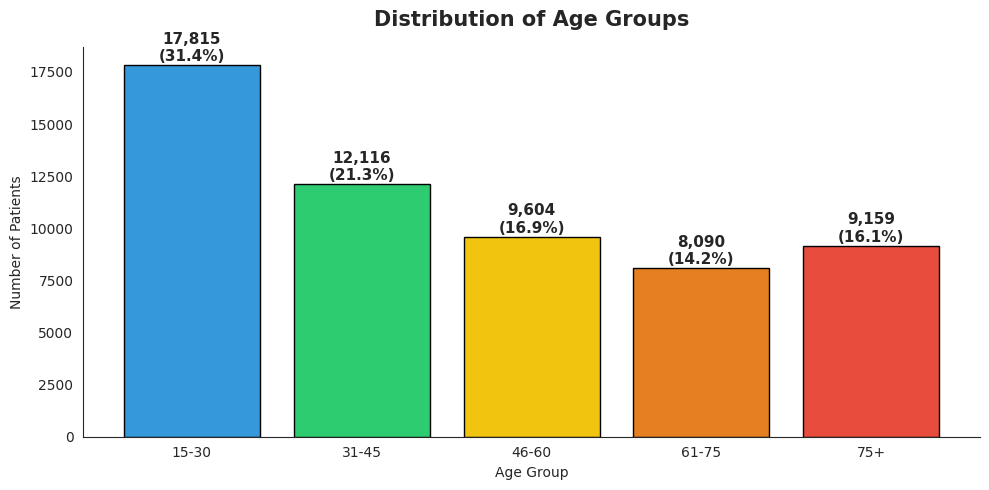

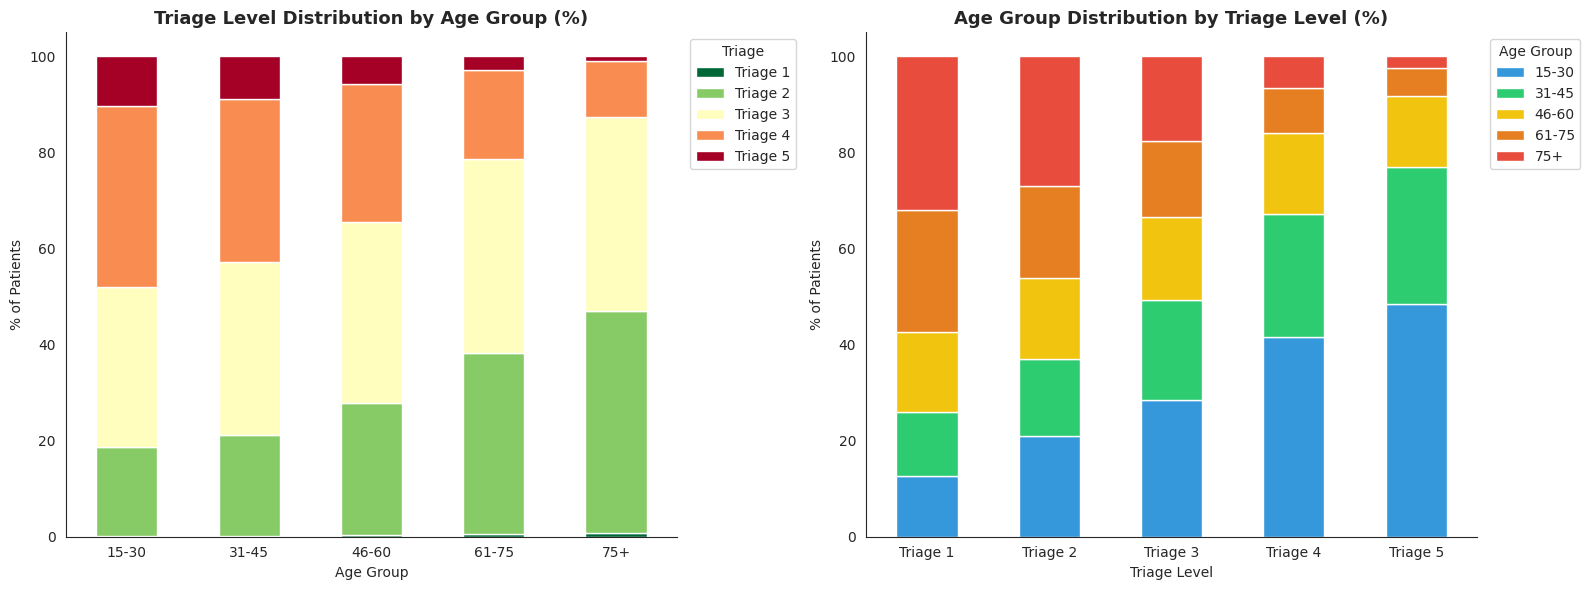

/tmp/ipykernel_937122/275419331.py:83: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



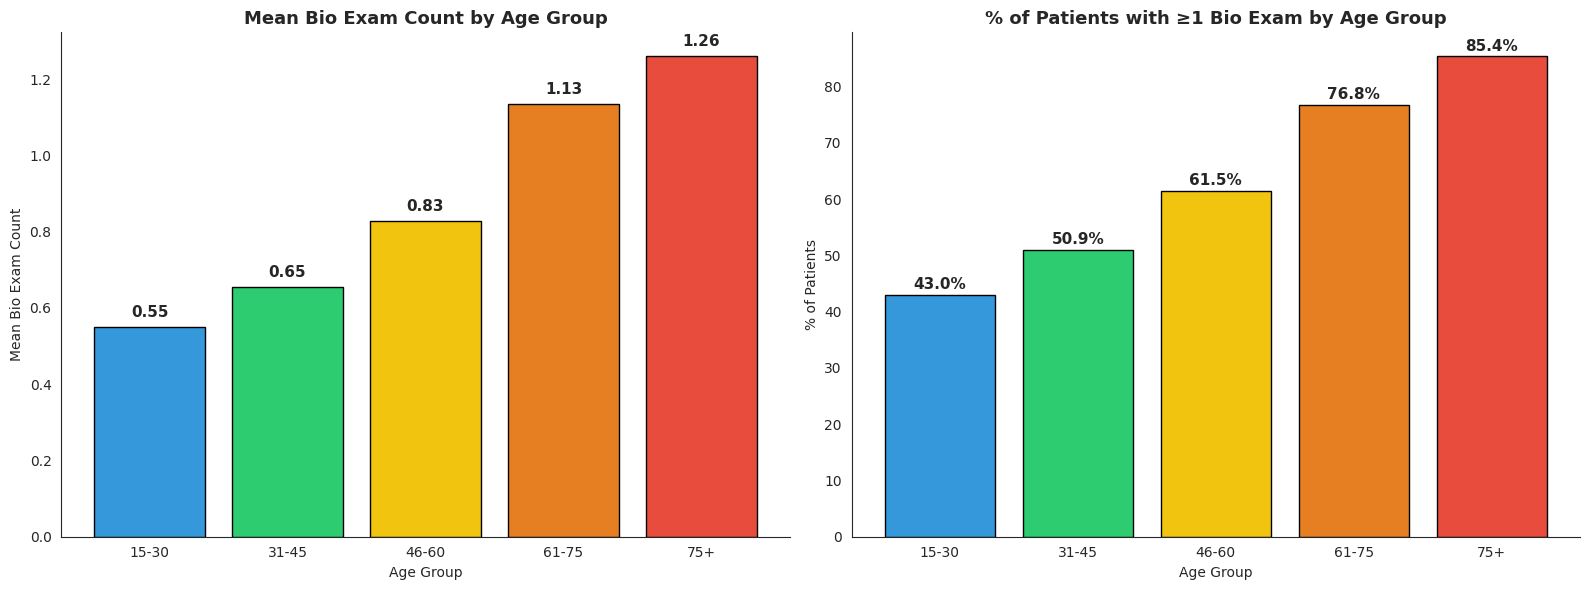

/tmp/ipykernel_937122/275419331.py:115: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



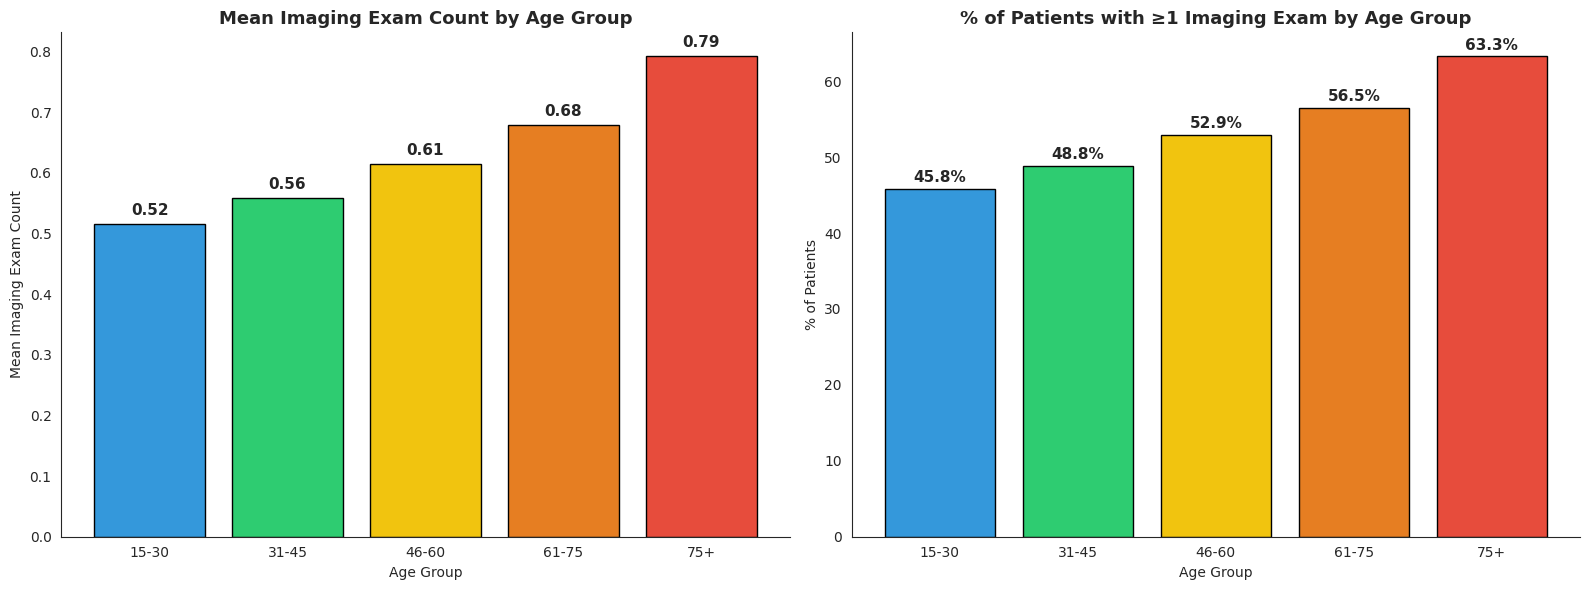

In [107]:
# ================================================================
# AGE GROUP — 4 PLOTS
# ================================================================

age_order    = ['15-30', '31-45', '46-60', '61-75', '75+']
triage_order = ['Triage 1', 'Triage 2', 'Triage 3', 'Triage 4', 'Triage 5']
palette_age  = ['#3498db', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']


# ================================================================
# PLOT 1 : Répartition seule de age_group
# ================================================================
fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')

counts = df['age_group'].value_counts().reindex(age_order)
bars = ax.bar(counts.index, counts.values, color=palette_age, edgecolor='black')

for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribution of Age Groups', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Age Group')
ax.set_ylabel('Number of Patients')
sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/age_group_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# PLOT 2 : age_group vs triage (stacked bar 100%)
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# Gauche : % triage par age_group
cross_pct = pd.crosstab(df['age_group'].astype(str), df['triage_label'],
                         normalize='index') * 100
cross_pct = cross_pct.reindex(index=age_order).dropna(how='all')
cross_pct[[c for c in triage_order if c in cross_pct.columns]].plot(
    kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn_r', edgecolor='white'
)
axes[0].set_title('Triage Level Distribution by Age Group (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('% of Patients')
axes[0].legend(title='Triage', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Droite : % age_group par triage
cross_pct2 = pd.crosstab(df['triage_label'], df['age_group'].astype(str),
                          normalize='index') * 100
cross_pct2 = cross_pct2.reindex(index=triage_order).dropna(how='all')
cross_pct2[[c for c in age_order if c in cross_pct2.columns]].plot(
    kind='bar', stacked=True, ax=axes[1], color=palette_age, edgecolor='white'
)
axes[1].set_title('Age Group Distribution by Triage Level (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Triage Level')
axes[1].set_ylabel('% of Patients')
axes[1].legend(title='Age Group', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/age_group_vs_triage.png", dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# PLOT 3 : age_group vs bio_exam_count (2 barplots côte à côte)
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# Gauche : moyenne bio_exam_count par age_group
means_bio = df.groupby('age_group', observed=True)['bio_exam_count'].mean().reindex(age_order)
bars = axes[0].bar(means_bio.index, means_bio.values, color=palette_age, edgecolor='black')
for bar, val in zip(bars, means_bio.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Mean Bio Exam Count by Age Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Mean Bio Exam Count')

# Droite : % patients avec ≥1 bio exam
pct_bio = df.groupby('age_group', observed=True).apply(
    lambda x: (x['bio_exam_count'] > 0).mean() * 100
).reindex(age_order)
bars = axes[1].bar(pct_bio.index, pct_bio.values, color=palette_age, edgecolor='black')
for bar, val in zip(bars, pct_bio.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('% of Patients with ≥1 Bio Exam by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('% of Patients')

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/age_group_vs_bio_exam_count.png", dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# PLOT 4 : age_group vs imaging_exam_count (2 barplots côte à côte)
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# Gauche : moyenne imaging_exam_count par age_group
means_img = df.groupby('age_group', observed=True)['imaging_exam_count'].mean().reindex(age_order)
bars = axes[0].bar(means_img.index, means_img.values, color=palette_age, edgecolor='black')
for bar, val in zip(bars, means_img.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Mean Imaging Exam Count by Age Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Mean Imaging Exam Count')

# Droite : % patients avec ≥1 imaging exam
pct_img = df.groupby('age_group', observed=True).apply(
    lambda x: (x['imaging_exam_count'] > 0).mean() * 100
).reindex(age_order)
bars = axes[1].bar(pct_img.index, pct_img.values, color=palette_age, edgecolor='black')
for bar, val in zip(bars, pct_img.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('% of Patients with ≥1 Imaging Exam by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('% of Patients')

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/age_group_vs_imaging_exam_count.png", dpi=150, bbox_inches='tight')
plt.show()

### SEX vs traige, vs exam bio and vs imaging

In [108]:
print(sex_order)  # doit donner ['F', 'M']

['F', 'M']


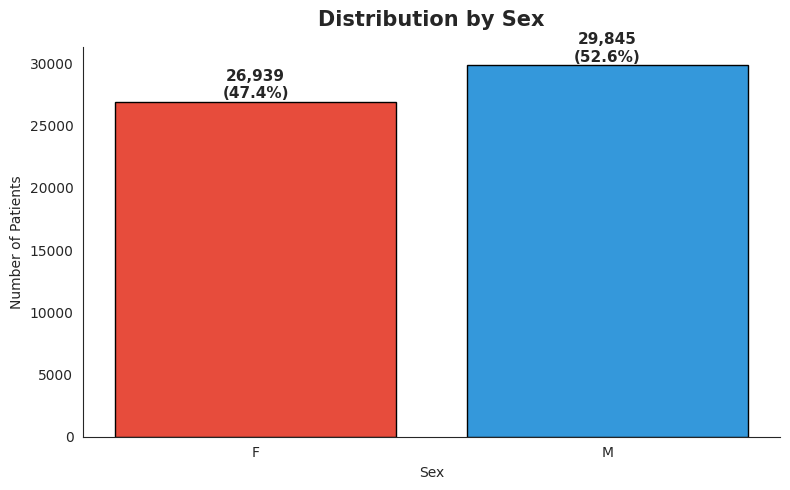

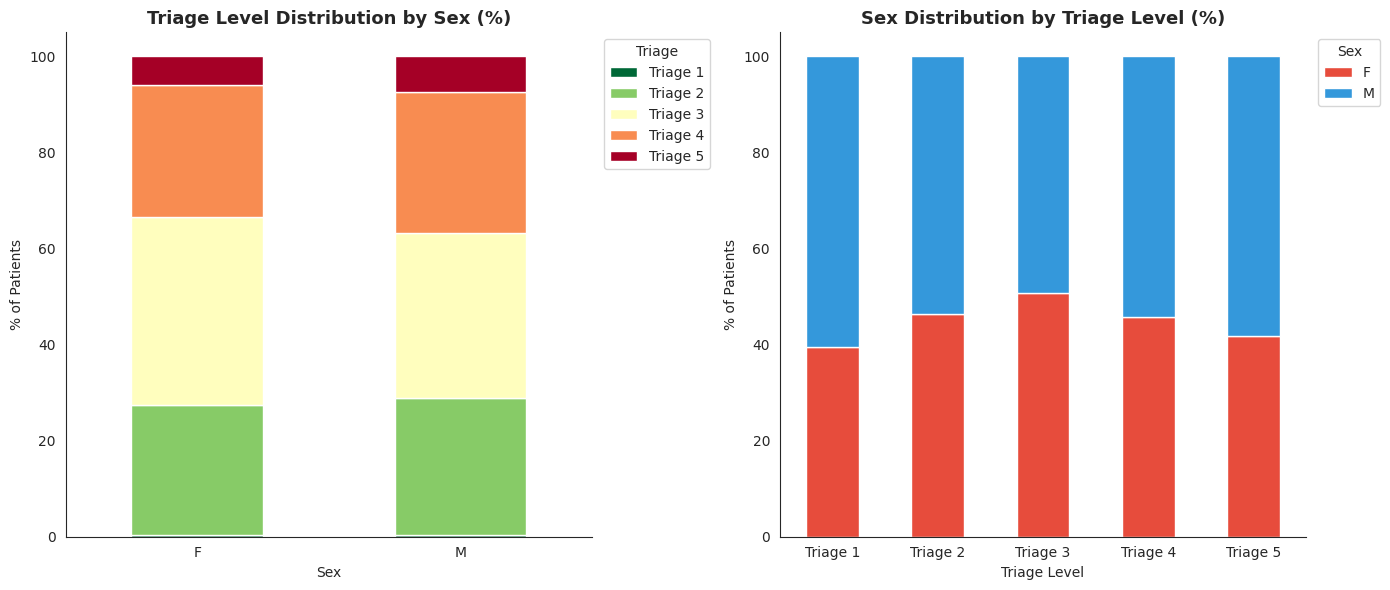

/tmp/ipykernel_937122/414885101.py:84: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



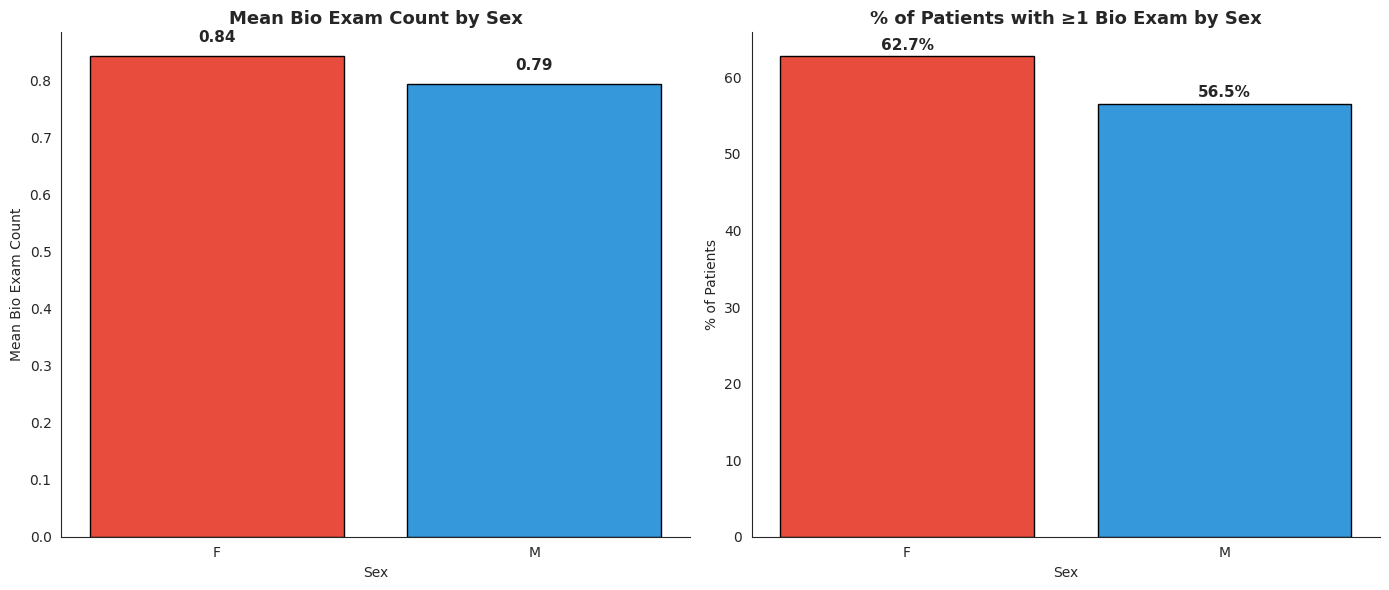

/tmp/ipykernel_937122/414885101.py:116: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



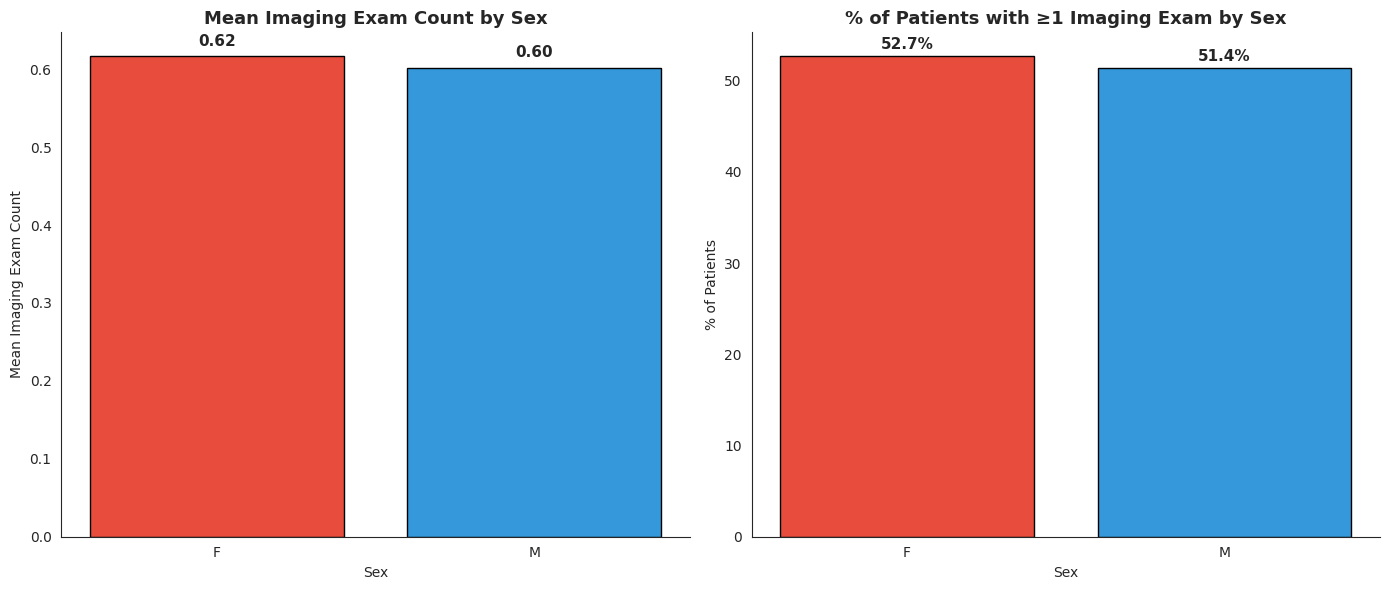

In [109]:
# ================================================================
# SEX — 4 PLOTS (même structure que age_group)
# ================================================================

sex_col = 'sex'


sex_order   = sorted(df[sex_col].dropna().unique().tolist())
palette_sex = ['#e74c3c', '#3498db']  # adapter si plus de 2 modalités

# ================================================================
# PLOT 1 : Répartition seule de sex
# ================================================================
fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')

counts = df[sex_col].value_counts().reindex(sex_order)
bars = ax.bar(counts.index, counts.values, color=palette_sex, edgecolor='black')

for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribution by Sex', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Sex')
ax.set_ylabel('Number of Patients')
sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/sex_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# PLOT 2 : sex vs triage (stacked bar 100%)
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# Gauche : % triage par sex
cross_pct = pd.crosstab(df[sex_col].astype(str), df['triage_label'],
                         normalize='index') * 100
cross_pct = cross_pct.reindex(index=sex_order).dropna(how='all')
cross_pct[[c for c in triage_order if c in cross_pct.columns]].plot(
    kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn_r', edgecolor='white'
)
axes[0].set_title('Triage Level Distribution by Sex (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('% of Patients')
axes[0].legend(title='Triage', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Droite : % sex par triage
cross_pct2 = pd.crosstab(df['triage_label'], df[sex_col].astype(str),
                          normalize='index') * 100
cross_pct2 = cross_pct2.reindex(index=triage_order).dropna(how='all')
cross_pct2[[c for c in sex_order if c in cross_pct2.columns]].plot(
    kind='bar', stacked=True, ax=axes[1], color=palette_sex, edgecolor='white'
)
axes[1].set_title('Sex Distribution by Triage Level (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Triage Level')
axes[1].set_ylabel('% of Patients')
axes[1].legend(title='Sex', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/sex_vs_triage.png", dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# PLOT 3 : sex vs bio_exam_count
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# Gauche : moyenne
means_bio = df.groupby(sex_col)['bio_exam_count'].mean().reindex(sex_order)
bars = axes[0].bar(means_bio.index, means_bio.values, color=palette_sex, edgecolor='black')
for bar, val in zip(bars, means_bio.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Mean Bio Exam Count by Sex', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Mean Bio Exam Count')

# Droite : % patients avec ≥1 bio exam
pct_bio = df.groupby(sex_col).apply(
    lambda x: (x['bio_exam_count'] > 0).mean() * 100
).reindex(sex_order)
bars = axes[1].bar(pct_bio.index, pct_bio.values, color=palette_sex, edgecolor='black')
for bar, val in zip(bars, pct_bio.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('% of Patients with ≥1 Bio Exam by Sex', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('% of Patients')

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/sex_vs_bio_exam_count.png", dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# PLOT 4 : sex vs imaging_exam_count
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# Gauche : moyenne
means_img = df.groupby(sex_col)['imaging_exam_count'].mean().reindex(sex_order)
bars = axes[0].bar(means_img.index, means_img.values, color=palette_sex, edgecolor='black')
for bar, val in zip(bars, means_img.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Mean Imaging Exam Count by Sex', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Mean Imaging Exam Count')

# Droite : % patients avec ≥1 imaging exam
pct_img = df.groupby(sex_col).apply(
    lambda x: (x['imaging_exam_count'] > 0).mean() * 100
).reindex(sex_order)
bars = axes[1].bar(pct_img.index, pct_img.values, color=palette_sex, edgecolor='black')
for bar, val in zip(bars, pct_img.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('% of Patients with ≥1 Imaging Exam by Sex', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('% of Patients')

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/sex_vs_imaging_exam_count.png", dpi=150, bbox_inches='tight')
plt.show()

### EKG ###

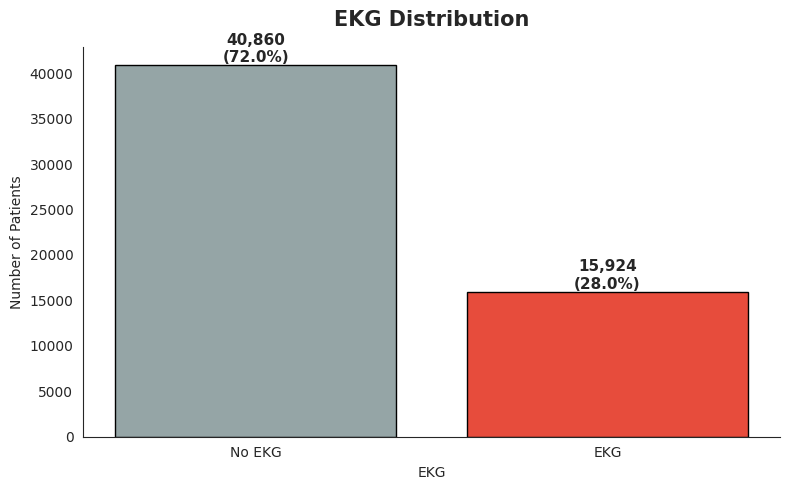

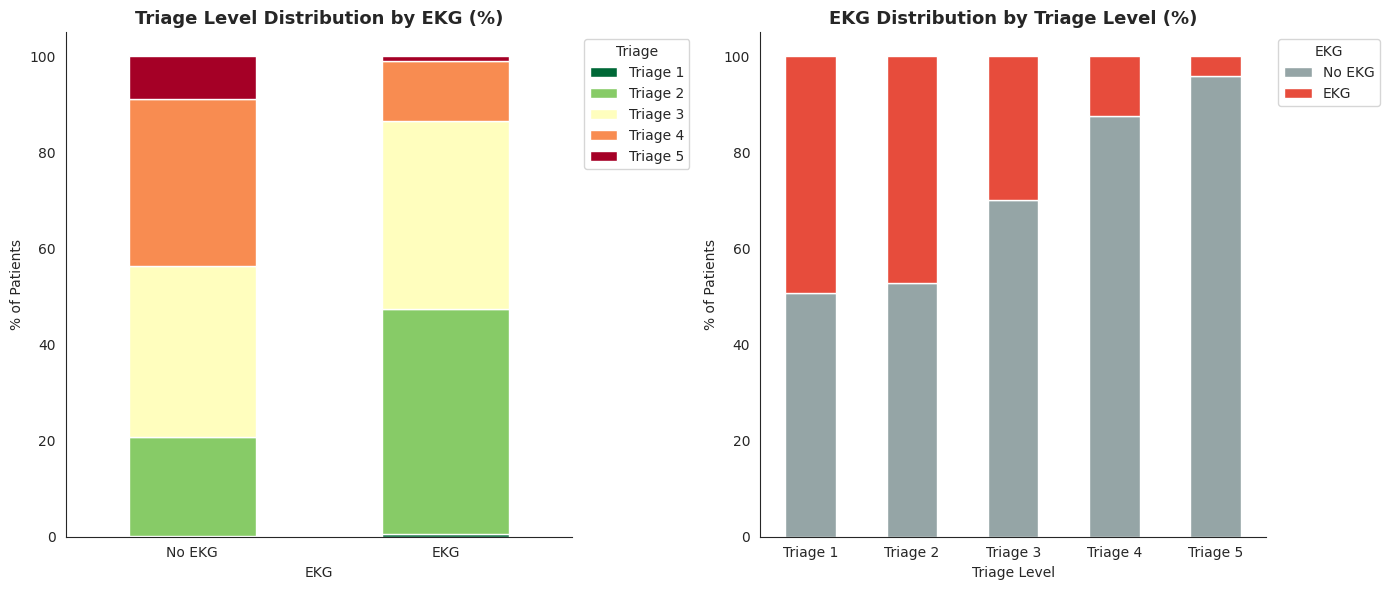

/tmp/ipykernel_937122/64300237.py:75: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_937122/64300237.py:85: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_937122/64300237.py:85: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



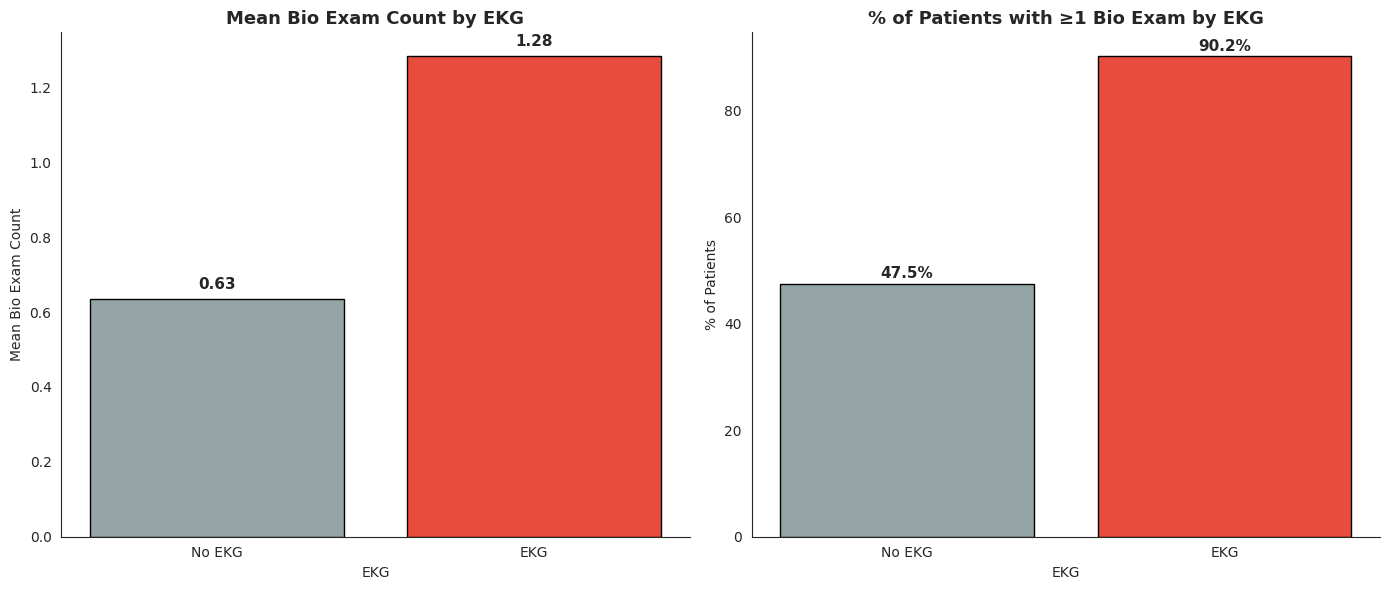

/tmp/ipykernel_937122/64300237.py:106: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_937122/64300237.py:116: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_937122/64300237.py:116: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



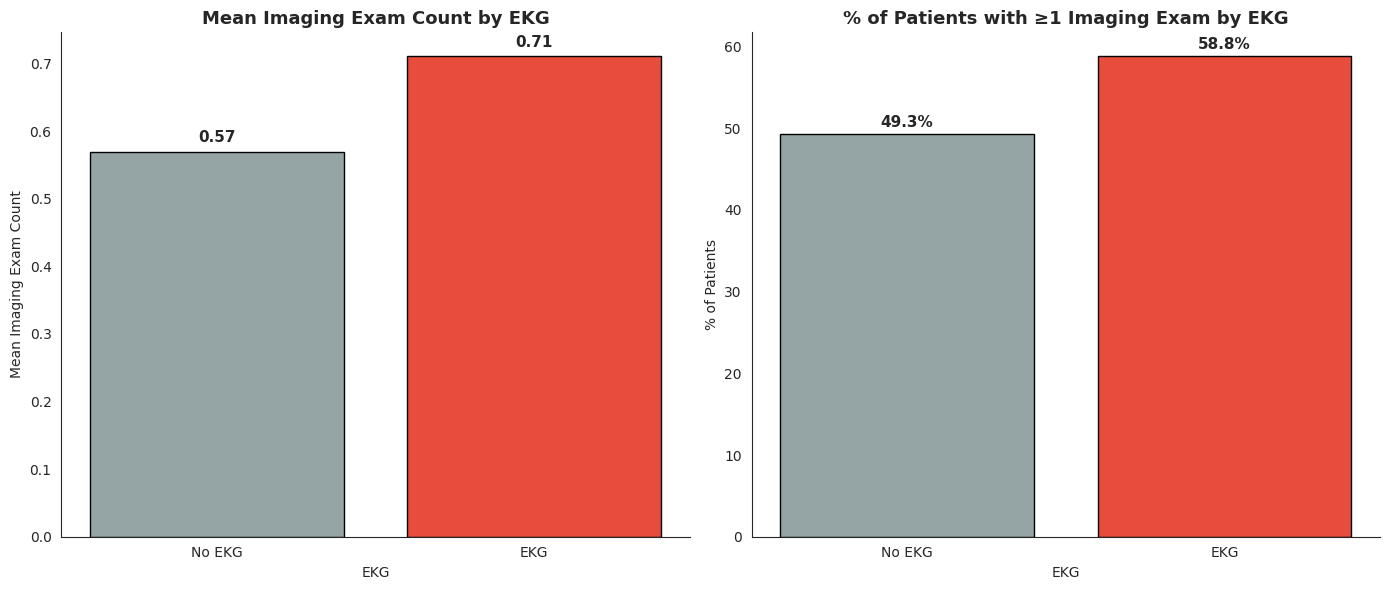

In [110]:
# ================================================================
# HAD_EKG — 4 PLOTS (même structure)
# ================================================================

ekg_col   = 'had_ekg'
ekg_order = [0, 1]
palette_ekg = ['#95a5a6', '#e74c3c']  # 0=gris, 1=rouge

# ================================================================
# PLOT 1 : Répartition seule de had_ekg
# ================================================================
fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')

counts = df[ekg_col].value_counts().reindex(ekg_order)
bars = ax.bar(['No EKG', 'EKG'], counts.values, color=palette_ekg, edgecolor='black')

for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('EKG Distribution', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('EKG')
ax.set_ylabel('Number of Patients')
sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/ekg_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# PLOT 2 : had_ekg vs triage (stacked bar 100%)
# ================================================================
df['ekg_label'] = df[ekg_col].map({0: 'No EKG', 1: 'EKG'})
ekg_label_order = ['No EKG', 'EKG']

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# Gauche : % triage par ekg
cross_pct = pd.crosstab(df['ekg_label'], df['triage_label'],
                         normalize='index') * 100
cross_pct = cross_pct.reindex(index=ekg_label_order).dropna(how='all')
cross_pct[[c for c in triage_order if c in cross_pct.columns]].plot(
    kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn_r', edgecolor='white'
)
axes[0].set_title('Triage Level Distribution by EKG (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('EKG')
axes[0].set_ylabel('% of Patients')
axes[0].legend(title='Triage', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Droite : % ekg par triage
cross_pct2 = pd.crosstab(df['triage_label'], df['ekg_label'],
                          normalize='index') * 100
cross_pct2 = cross_pct2.reindex(index=triage_order).dropna(how='all')
cross_pct2[[c for c in ekg_label_order if c in cross_pct2.columns]].plot(
    kind='bar', stacked=True, ax=axes[1], color=palette_ekg, edgecolor='white'
)
axes[1].set_title('EKG Distribution by Triage Level (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Triage Level')
axes[1].set_ylabel('% of Patients')
axes[1].legend(title='EKG', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/ekg_vs_triage.png", dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# PLOT 3 : had_ekg vs bio_exam_count
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# Gauche : moyenne
means_bio = df.groupby('ekg_label')['bio_exam_count'].mean().reindex(ekg_label_order)
bars = axes[0].bar(means_bio.index, means_bio.values, color=palette_ekg, edgecolor='black')
for bar, val in zip(bars, means_bio.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Mean Bio Exam Count by EKG', fontsize=13, fontweight='bold')
axes[0].set_xlabel('EKG')
axes[0].set_ylabel('Mean Bio Exam Count')

# Droite : % patients avec ≥1 bio exam
pct_bio = df.groupby('ekg_label').apply(
    lambda x: (x['bio_exam_count'] > 0).mean() * 100
).reindex(ekg_label_order)
bars = axes[1].bar(pct_bio.index, pct_bio.values, color=palette_ekg, edgecolor='black')
for bar, val in zip(bars, pct_bio.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('% of Patients with ≥1 Bio Exam by EKG', fontsize=13, fontweight='bold')
axes[1].set_xlabel('EKG')
axes[1].set_ylabel('% of Patients')

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/ekg_vs_bio_exam_count.png", dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# PLOT 4 : had_ekg vs imaging_exam_count
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
# Gauche : moyenne
means_img = df.groupby('ekg_label')['imaging_exam_count'].mean().reindex(ekg_label_order)
bars = axes[0].bar(means_img.index, means_img.values, color=palette_ekg, edgecolor='black')
for bar, val in zip(bars, means_img.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Mean Imaging Exam Count by EKG', fontsize=13, fontweight='bold')
axes[0].set_xlabel('EKG')
axes[0].set_ylabel('Mean Imaging Exam Count')

# Droite : % patients avec ≥1 imaging exam
pct_img = df.groupby('ekg_label').apply(
    lambda x: (x['imaging_exam_count'] > 0).mean() * 100
).reindex(ekg_label_order)
bars = axes[1].bar(pct_img.index, pct_img.values, color=palette_ekg, edgecolor='black')
for bar, val in zip(bars, pct_img.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('% of Patients with ≥1 Imaging Exam by EKG', fontsize=13, fontweight='bold')
axes[1].set_xlabel('EKG')
axes[1].set_ylabel('% of Patients')

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/ekg_vs_imaging_exam_count.png", dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_937122/3826634504.py:7: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



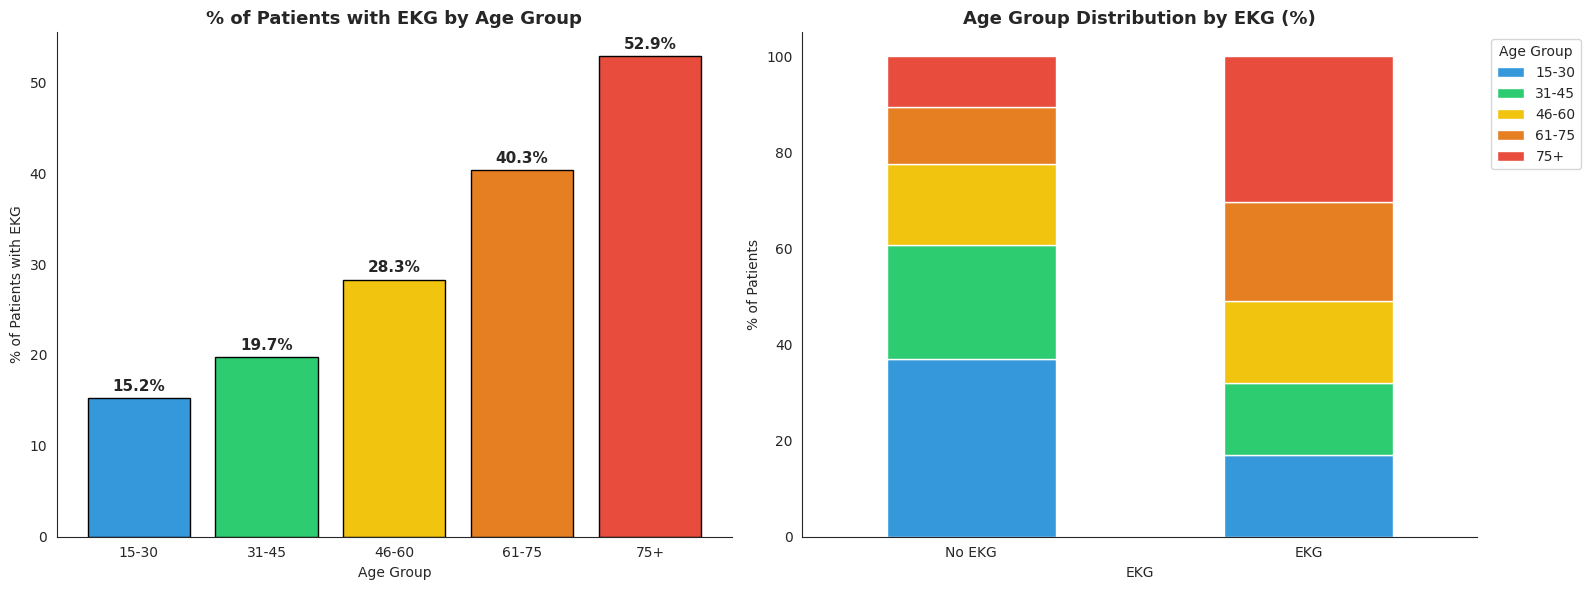

/tmp/ipykernel_937122/3826634504.py:43: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



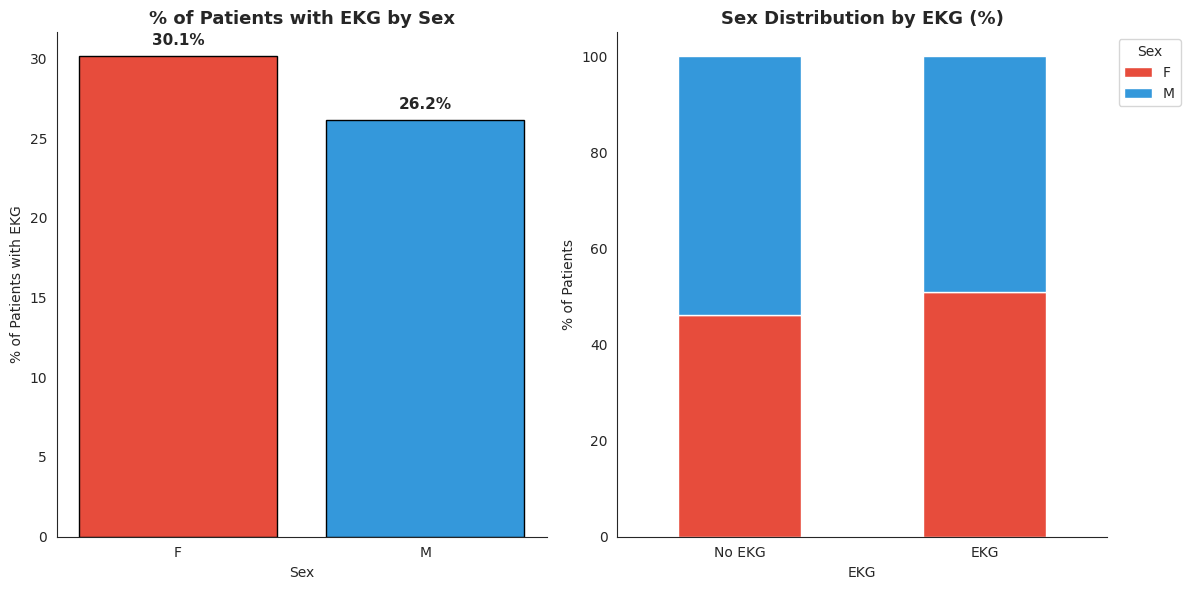

In [111]:
# ================================================================
# PLOT 5 : had_ekg vs age_group
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# Gauche : % EKG par age_group
pct_ekg_age = df.groupby('age_group', observed=True).apply(
    lambda x: (x[ekg_col] == 1).mean() * 100
).reindex(age_order)

bars = axes[0].bar(pct_ekg_age.index, pct_ekg_age.values, color=palette_age, edgecolor='black')
for bar, val in zip(bars, pct_ekg_age.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('% of Patients with EKG by Age Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('% of Patients with EKG')

# Droite : stacked bar age_group par ekg_label
cross_age = pd.crosstab(df['ekg_label'], df['age_group'].astype(str),
                         normalize='index') * 100
cross_age = cross_age.reindex(index=ekg_label_order).dropna(how='all')
cross_age[[c for c in age_order if c in cross_age.columns]].plot(
    kind='bar', stacked=True, ax=axes[1], color=palette_age, edgecolor='white'
)
axes[1].set_title('Age Group Distribution by EKG (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('EKG')
axes[1].set_ylabel('% of Patients')
axes[1].legend(title='Age Group', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/ekg_vs_age_group.png", dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# PLOT 6 : had_ekg vs sex
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6), facecolor='white')

# Gauche : % EKG par sex
pct_ekg_sex = df.groupby(sex_col).apply(
    lambda x: (x[ekg_col] == 1).mean() * 100
).reindex(sex_order)

bars = axes[0].bar(pct_ekg_sex.index, pct_ekg_sex.values, color=palette_sex, edgecolor='black')
for bar, val in zip(bars, pct_ekg_sex.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('% of Patients with EKG by Sex', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('% of Patients with EKG')

# Droite : stacked bar sex par ekg_label
cross_sex = pd.crosstab(df['ekg_label'], df[sex_col].astype(str),
                         normalize='index') * 100
cross_sex = cross_sex.reindex(index=ekg_label_order).dropna(how='all')
cross_sex[[c for c in sex_order if c in cross_sex.columns]].plot(
    kind='bar', stacked=True, ax=axes[1], color=palette_sex, edgecolor='white'
)
axes[1].set_title('Sex Distribution by EKG (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('EKG')
axes[1].set_ylabel('% of Patients')
axes[1].legend(title='Sex', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/ekg_vs_sex.png", dpi=150, bbox_inches='tight')
plt.show()

### hopsit and uhcd vs traige, age ans sex

/tmp/ipykernel_937122/2481689508.py:19: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



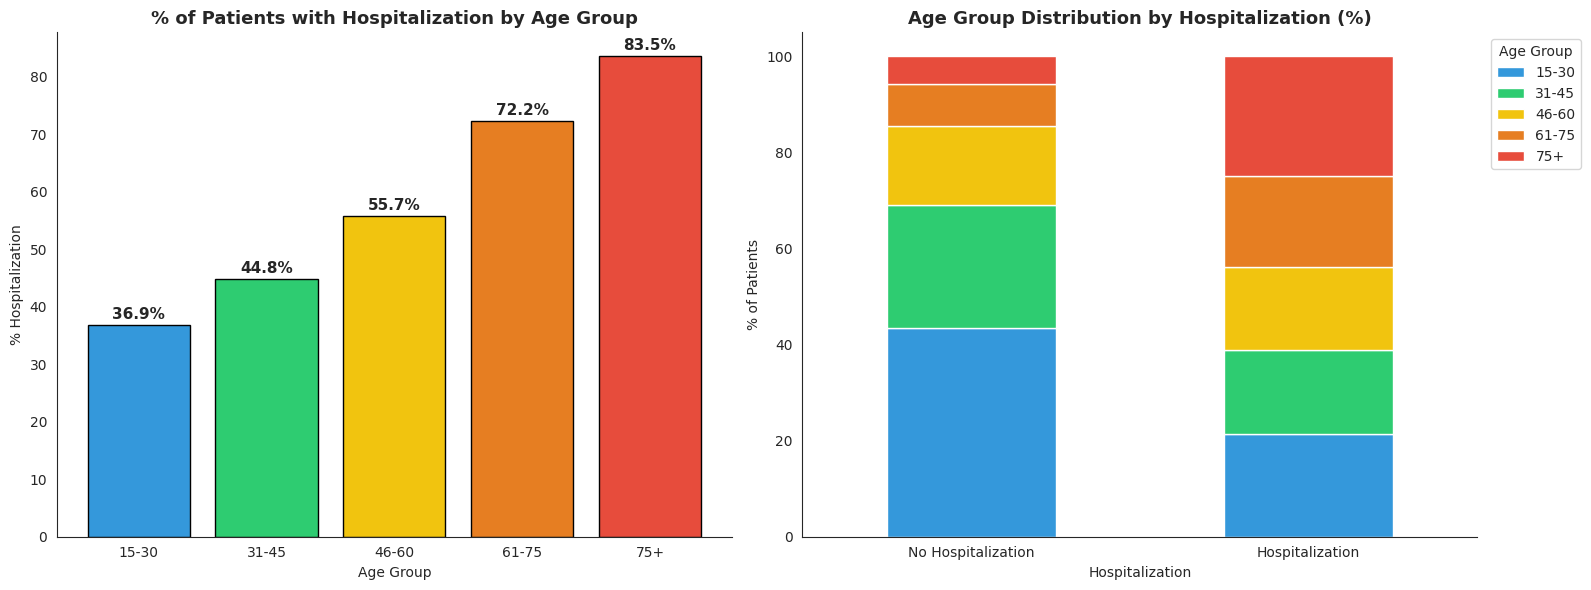

/tmp/ipykernel_937122/2481689508.py:57: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



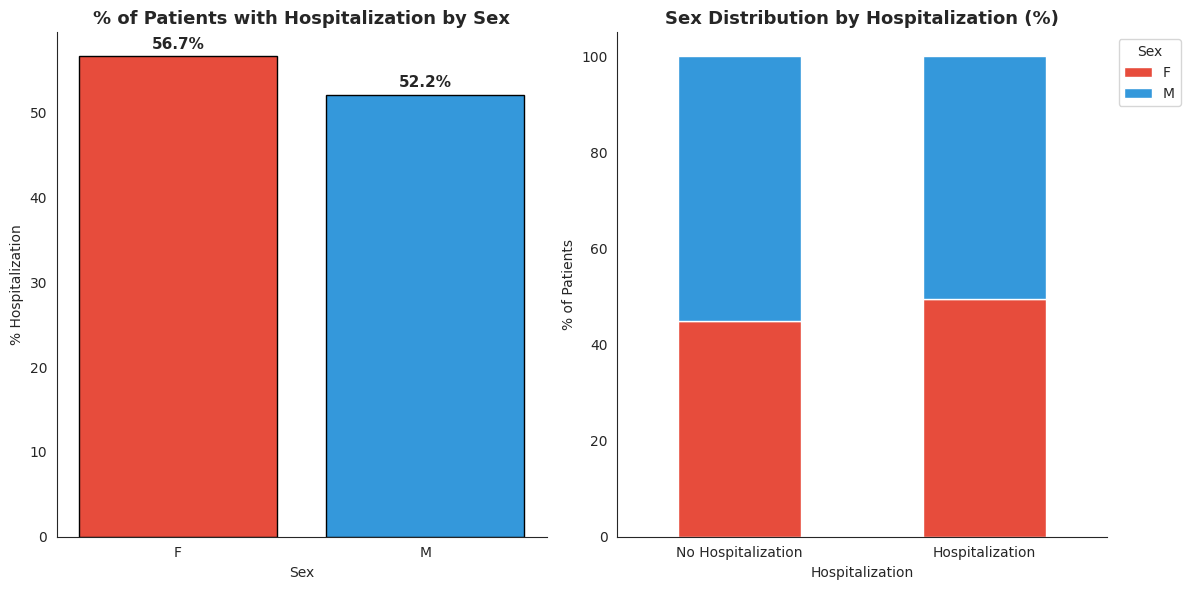

/tmp/ipykernel_937122/2481689508.py:95: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_937122/2481689508.py:109: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



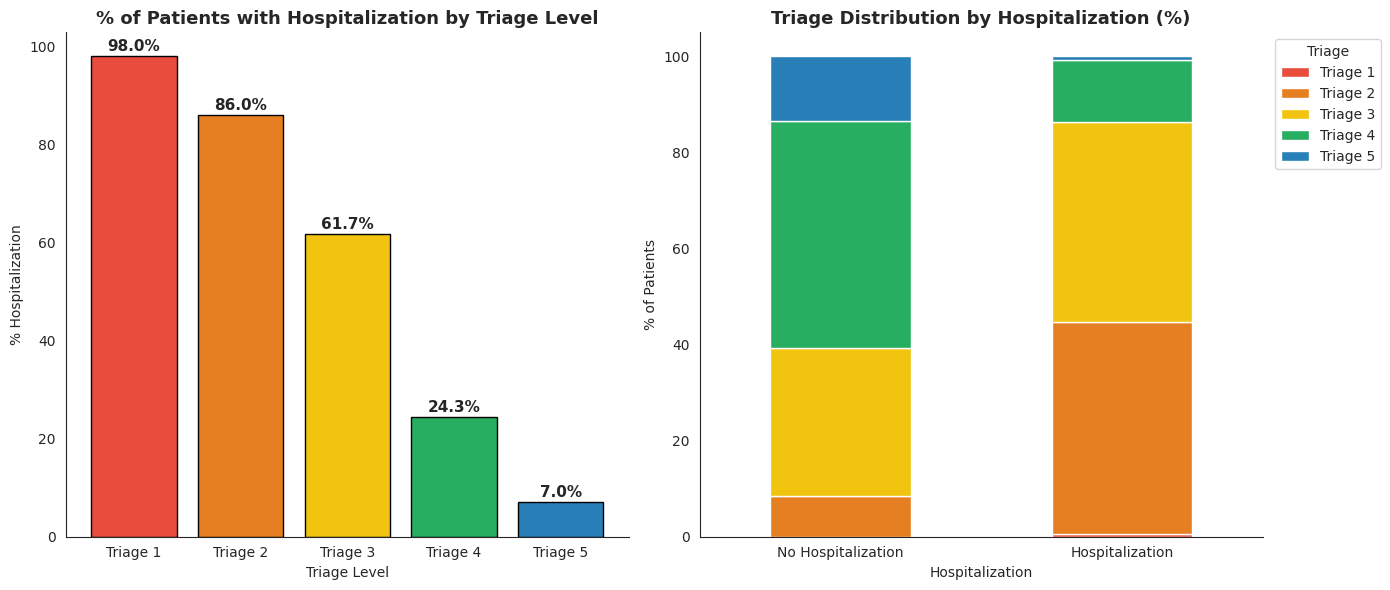

/tmp/ipykernel_937122/2481689508.py:19: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



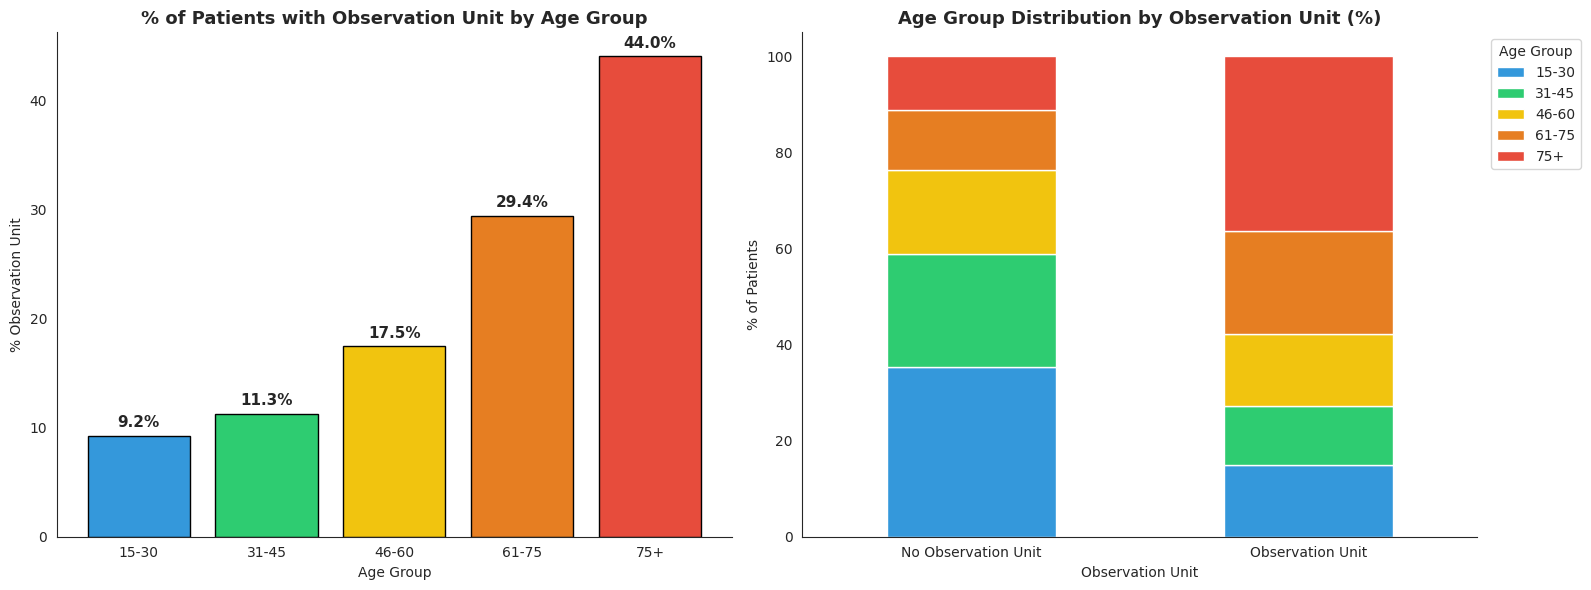

/tmp/ipykernel_937122/2481689508.py:57: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



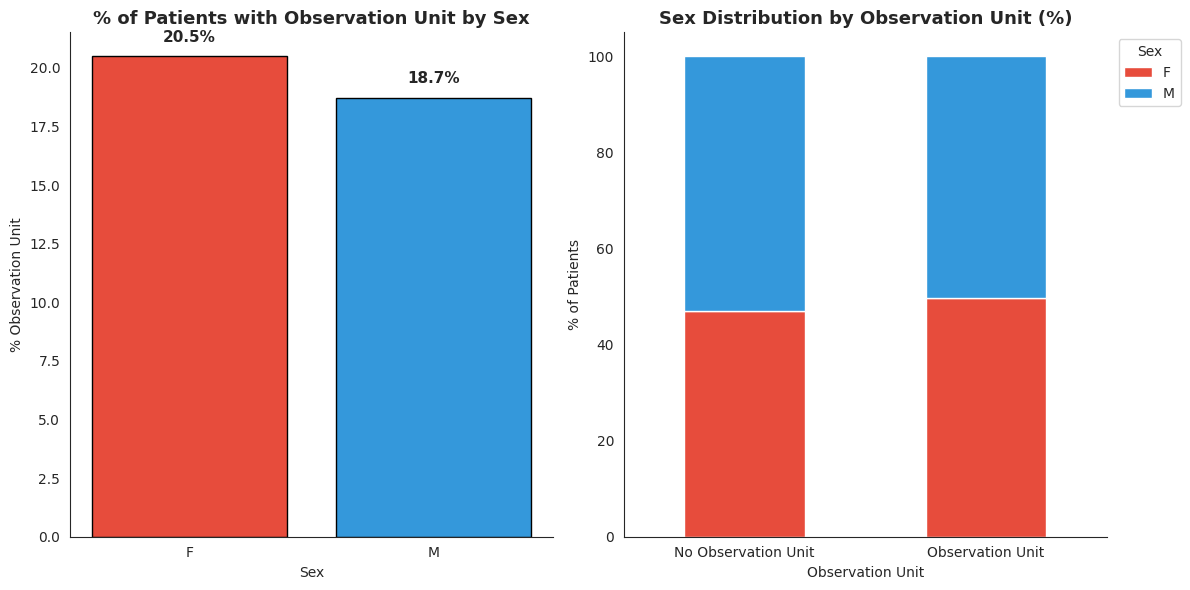

/tmp/ipykernel_937122/2481689508.py:95: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_937122/2481689508.py:109: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



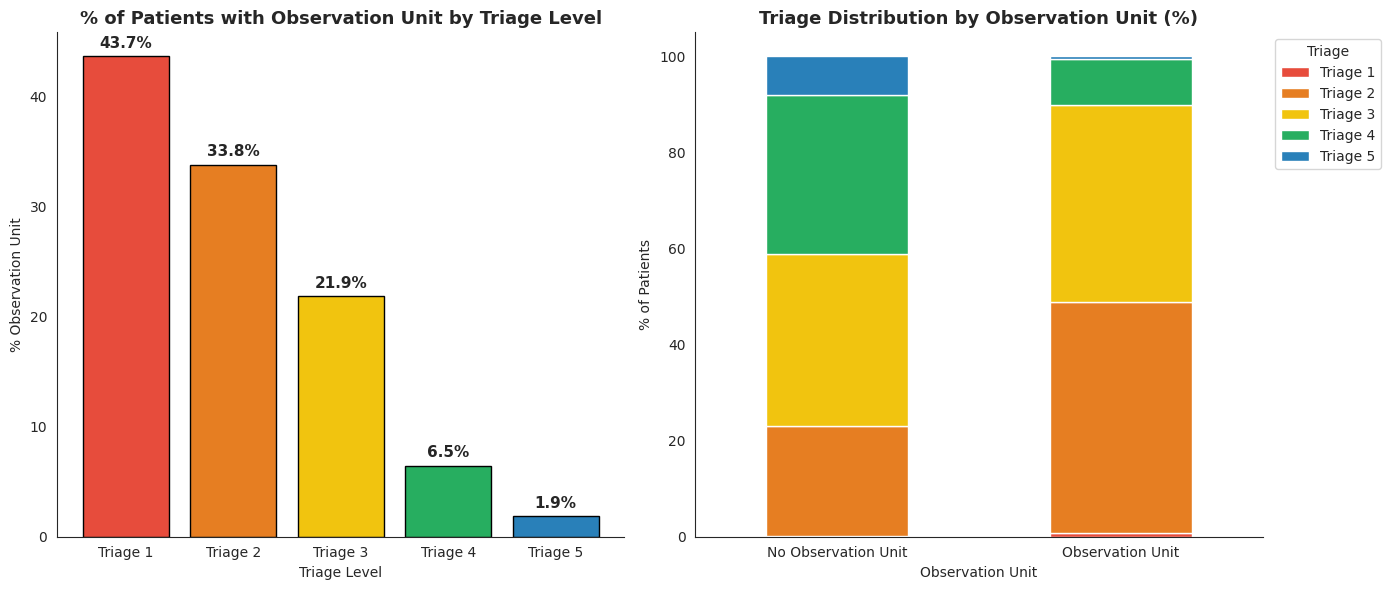

In [112]:
# ================================================================
# HOSPITALIZATION & OBSERVATION UNIT vs age_group / sex / triage
# ================================================================

for outcome_col, outcome_label, color_yes in [
    ('hospitalization',  'Hospitalization', '#e74c3c'),
    ('observation_unit', 'Observation Unit', '#f39c12'),
]:
    df[f'{outcome_col}_label'] = df[outcome_col].map({0: f'No {outcome_label}', 1: outcome_label})
    outcome_label_order = [f'No {outcome_label}', outcome_label]
    palette_outcome     = ['#95a5a6', color_yes]

    # ============================================================
    # PLOT 1 : vs age_group
    # ============================================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

    # Gauche : % outcome par age_group
    pct_age = df.groupby('age_group', observed=True).apply(
        lambda x: (x[outcome_col] == 1).mean() * 100
    ).reindex(age_order)

    bars = axes[0].bar(pct_age.index, pct_age.values, color=palette_age, edgecolor='black')
    for bar, val in zip(bars, pct_age.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    axes[0].set_title(f'% of Patients with {outcome_label} by Age Group',
                      fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Age Group')
    axes[0].set_ylabel(f'% {outcome_label}')

    # Droite : stacked bar age_group par outcome
    cross = pd.crosstab(df[f'{outcome_col}_label'], df['age_group'].astype(str),
                         normalize='index') * 100
    cross = cross.reindex(index=outcome_label_order).dropna(how='all')
    cross[[c for c in age_order if c in cross.columns]].plot(
        kind='bar', stacked=True, ax=axes[1], color=palette_age, edgecolor='white'
    )
    axes[1].set_title(f'Age Group Distribution by {outcome_label} (%)',
                      fontsize=13, fontweight='bold')
    axes[1].set_xlabel(outcome_label)
    axes[1].set_ylabel('% of Patients')
    axes[1].legend(title='Age Group', bbox_to_anchor=(1.01, 1), loc='upper left')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

    sns.despine()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{outcome_col}_vs_age_group.png", dpi=150, bbox_inches='tight')
    plt.show()

    # ============================================================
    # PLOT 2 : vs sex
    # ============================================================
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), facecolor='white')

    # Gauche : % outcome par sex
    pct_sex = df.groupby(sex_col).apply(
        lambda x: (x[outcome_col] == 1).mean() * 100
    ).reindex(sex_order)

    bars = axes[0].bar(pct_sex.index, pct_sex.values, color=palette_sex, edgecolor='black')
    for bar, val in zip(bars, pct_sex.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    axes[0].set_title(f'% of Patients with {outcome_label} by Sex',
                      fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Sex')
    axes[0].set_ylabel(f'% {outcome_label}')

    # Droite : stacked bar sex par outcome
    cross = pd.crosstab(df[f'{outcome_col}_label'], df[sex_col].astype(str),
                         normalize='index') * 100
    cross = cross.reindex(index=outcome_label_order).dropna(how='all')
    cross[[c for c in sex_order if c in cross.columns]].plot(
        kind='bar', stacked=True, ax=axes[1], color=palette_sex, edgecolor='white'
    )
    axes[1].set_title(f'Sex Distribution by {outcome_label} (%)',
                      fontsize=13, fontweight='bold')
    axes[1].set_xlabel(outcome_label)
    axes[1].set_ylabel('% of Patients')
    axes[1].legend(title='Sex', bbox_to_anchor=(1.01, 1), loc='upper left')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

    sns.despine()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{outcome_col}_vs_sex.png", dpi=150, bbox_inches='tight')
    plt.show()

    # ============================================================
    # PLOT 3 : vs triage
    # ============================================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

    # Gauche : % outcome par triage
    pct_triage = df.groupby('triage_label').apply(
        lambda x: (x[outcome_col] == 1).mean() * 100
    ).reindex(triage_order)

    palette_triage = ['#e74c3c', '#e67e22', '#f1c40f', '#27ae60', '#2980b9']
    bars = axes[0].bar(pct_triage.index, pct_triage.values,
                       color=palette_triage, edgecolor='black')
    for bar, val in zip(bars, pct_triage.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    axes[0].set_title(f'% of Patients with {outcome_label} by Triage Level',
                      fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Triage Level')
    axes[0].set_ylabel(f'% {outcome_label}')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

    # Droite : stacked bar triage par outcome
    cross = pd.crosstab(df[f'{outcome_col}_label'], df['triage_label'],
                         normalize='index') * 100
    cross = cross.reindex(index=outcome_label_order).dropna(how='all')
    cross[[c for c in triage_order if c in cross.columns]].plot(
        kind='bar', stacked=True, ax=axes[1], color=palette_triage, edgecolor='white'
    )
    axes[1].set_title(f'Triage Distribution by {outcome_label} (%)',
                      fontsize=13, fontweight='bold')
    axes[1].set_xlabel(outcome_label)
    axes[1].set_ylabel('% of Patients')
    axes[1].legend(title='Triage', bbox_to_anchor=(1.01, 1), loc='upper left')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

    sns.despine()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{outcome_col}_vs_triage.png", dpi=150, bbox_inches='tight')
    plt.show()

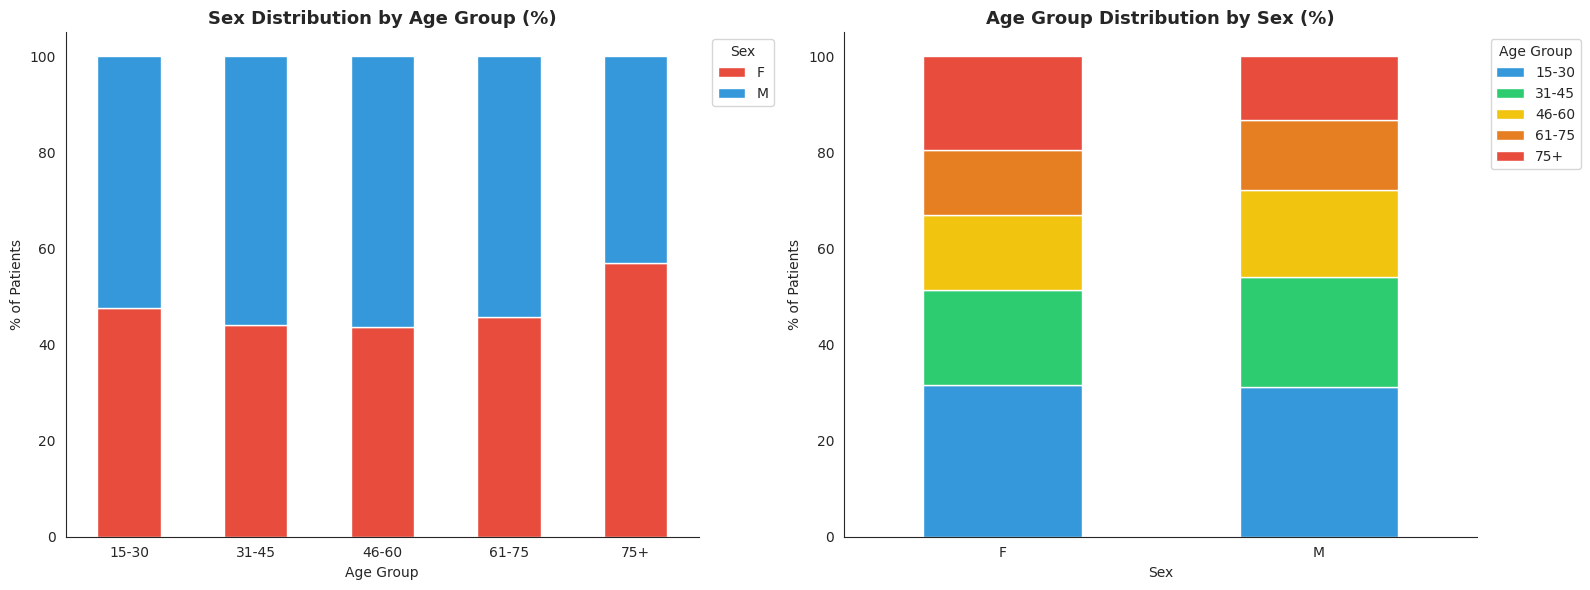

In [113]:
# ================================================================
# AGE GROUP vs SEX
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# Gauche : % sex par age_group
cross_pct = pd.crosstab(df['age_group'].astype(str), df[sex_col],
                         normalize='index') * 100
cross_pct = cross_pct.reindex(index=age_order).dropna(how='all')
cross_pct[[c for c in sex_order if c in cross_pct.columns]].plot(
    kind='bar', stacked=True, ax=axes[0], color=palette_sex, edgecolor='white'
)
axes[0].set_title('Sex Distribution by Age Group (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('% of Patients')
axes[0].legend(title='Sex', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Droite : % age_group par sex
cross_pct2 = pd.crosstab(df[sex_col], df['age_group'].astype(str),
                          normalize='index') * 100
cross_pct2 = cross_pct2.reindex(index=sex_order).dropna(how='all')
cross_pct2[[c for c in age_order if c in cross_pct2.columns]].plot(
    kind='bar', stacked=True, ax=axes[1], color=palette_age, edgecolor='white'
)
axes[1].set_title('Age Group Distribution by Sex (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('% of Patients')
axes[1].legend(title='Age Group', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/age_group_vs_sex.png", dpi=150, bbox_inches='tight')
plt.show()

Gros consommateurs (>= 3 examens) : 2663 (4.7%)
Reste : 54121 (95.3%)

=== Taux par variable binaire ===
                     reste  gros_conso  difference
has_culture          0.109       0.873       0.765
has_blood_gas        0.046       0.735       0.689
observation_unit     0.175       0.620       0.445
hospitalization      0.523       0.952       0.429
has_blood_test       0.566       0.969       0.403
had_ekg              0.265       0.592       0.327
has_ct_scan          0.242       0.430       0.188
has_lumbar_puncture  0.000       0.167       0.167
has_xray             0.225       0.323       0.098
has_mri              0.094       0.135       0.041
has_ultrasound       0.016       0.025       0.010


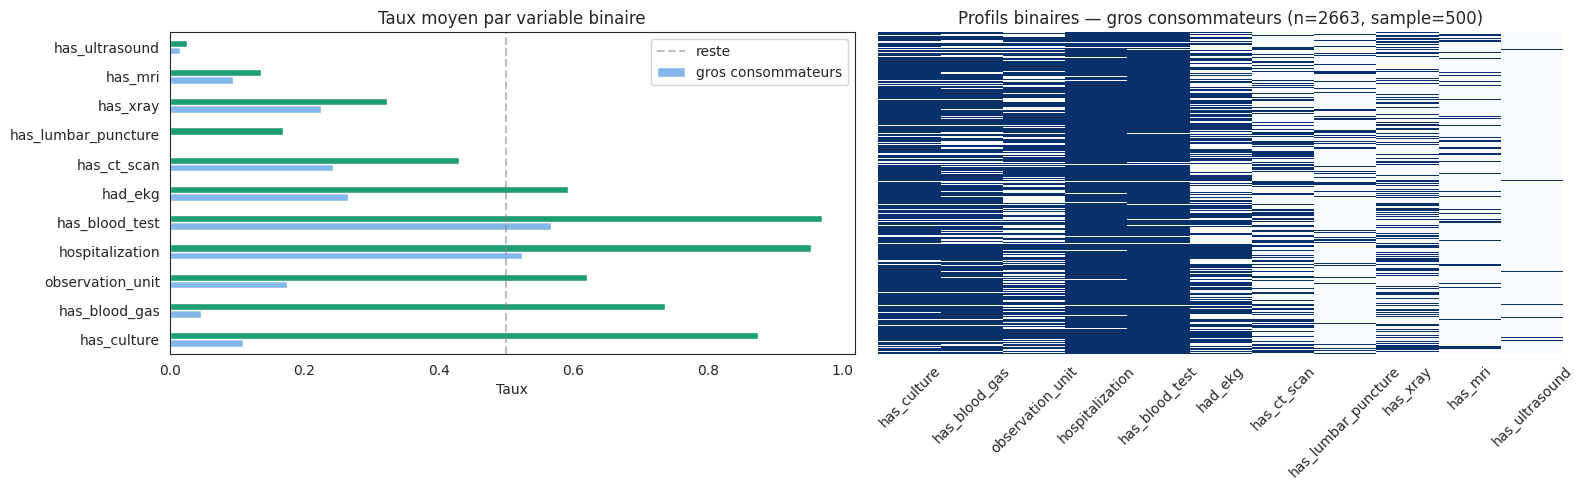


Variance moyenne binaires — gros conso : 0.146
Variance moyenne binaires — population : 0.138
→ Ratio : 1.05  (< 1 = plus homogène que la pop générale)

=== Tableau croisé imaging_exam_count x bio_exam_count ===
bio_exam_count          0      1     2     3   4    All
imaging_exam_count                                     
0                   13822   9029  3456   914  37  27258
1                    7993  12124  3749  1016  42  24924
2                    1126   2156   666   228  14   4190
3                      76    210    60    26   3    375
4                       6     21     5     3   1     36
5                       0      1     0     0   0      1
All                 23023  23541  7936  2187  97  56784


In [114]:
# ---- à adapter ----


VAR1 = "imaging_exam_count"
VAR2 = "bio_exam_count"
SEUIL = 3  # patients avec au moins 3 examens sur l'une des deux variables

VARS_BINAIRES = [
    # liste tes 12 colonnes binaires ici
    "has_ultrasound", "has_ct_scan", "has_xray", "has_mri", "has_blood_test", "has_culture", "has_lumbar_puncture", "has_blood_gas", "had_ekg", "hospitalization", "observation_unit"
]

df[VARS_BINAIRES] = df[VARS_BINAIRES].astype(int)
# -------------------

# Créer le groupe gros consommateurs vs reste
df["gros_conso"] = ((df[VAR1] >= SEUIL) | (df[VAR2] >= SEUIL)).astype(int)

n_gros = df["gros_conso"].sum()
n_total = len(df)
print(f"Gros consommateurs (>= {SEUIL} examens) : {n_gros} ({n_gros/n_total*100:.1f}%)")
print(f"Reste : {n_total - n_gros} ({(n_total-n_gros)/n_total*100:.1f}%)\n")

# ---- 1. Taux moyen de chaque variable binaire par groupe ----
means = df.groupby("gros_conso")[VARS_BINAIRES].mean().T
means.columns = ["reste", "gros_conso"]
means["difference"] = means["gros_conso"] - means["reste"]
means = means.sort_values("difference", ascending=False)

print("=== Taux par variable binaire ===")
print(means.round(3).to_string())

# ---- 2. Heatmap des variables binaires pour les gros consommateurs ----
gros = df[df["gros_conso"] == 1][VARS_BINAIRES]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='white')

# Barplot comparatif
means[["reste", "gros_conso"]].plot(kind="barh", ax=axes[0], color=["#85B7EB", "#1D9E75"])
axes[0].set_title("Taux moyen par variable binaire", fontsize=12)
axes[0].set_xlabel("Taux")
axes[0].axvline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[0].legend(["reste", "gros consommateurs"])

# Heatmap des gros consommateurs (échantillon si trop grand)
sample = gros.sample(min(500, len(gros)), random_state=42)
sns.heatmap(sample[means.index], ax=axes[1], cmap="Blues",
            cbar=False, yticklabels=False, xticklabels=True)
axes[1].set_title(f"Profils binaires — gros consommateurs (n={len(gros)}, sample={len(sample)})", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f"{output_dir}/profil_gros_conso.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 3. Homogénéité interne : variance moyenne des binaires ----
var_interne = gros[VARS_BINAIRES].var(axis=0).mean()
var_globale = df[VARS_BINAIRES].var(axis=0).mean()
print(f"\nVariance moyenne binaires — gros conso : {var_interne:.3f}")
print(f"Variance moyenne binaires — population : {var_globale:.3f}")
print(f"→ Ratio : {var_interne/var_globale:.2f}  (< 1 = plus homogène que la pop générale)")

# ---- 4. Distribution croisée des deux variables de count ----
cross = pd.crosstab(df[VAR1], df[VAR2], margins=True)
print(f"\n=== Tableau croisé {VAR1} x {VAR2} ===")
print(cross)

In [115]:
# ================================================================
# TAUX DE NaN — triage, chief complaint, *_status
# ================================================================

status_cols       = [c for c in df.columns if c.endswith('_status')]
cols_to_check     = ['triage', 'chief_complaint_en'] + status_cols

na_report = []
for col in cols_to_check:
    if col not in df.columns:
        continue
    n_na  = df[col].isna().sum()
    n_tot = len(df)
    na_report.append({
        'variable' : col,
        'n_total'  : n_tot,
        'n_na'     : n_na,
        'pct_na'   : round(n_na / n_tot * 100, 2),
        'n_valid'  : n_tot - n_na,
        'pct_valid': round((n_tot - n_na) / n_tot * 100, 2),
    })

df_na = pd.DataFrame(na_report).sort_values('pct_na', ascending=False)
display(df_na)

,variable,n_total,n_na,pct_na,n_valid,pct_valid
0,triage,56784,0,0.0,56784,100.0
1,chief_complaint,56784,0,0.0,56784,100.0
2,bp_status,56784,0,0.0,56784,100.0
3,hr_status,56784,0,0.0,56784,100.0
4,temp_status,56784,0,0.0,56784,100.0
5,sat_status,56784,0,0.0,56784,100.0
6,rr_status,56784,0,0.0,56784,100.0
7,o2_flow_status,56784,0,0.0,56784,100.0
8,gcs_status,56784,0,0.0,56784,100.0
9,cap_blood_sugar_status,56784,0,0.0,56784,100.0


# Table 1

In [116]:
import pandas as pd
from tableone import TableOne

# 1. On définit les colonnes à exclure (dates et temps)
cols_to_exclude = [c for c in df.columns if any(word in c.lower() for word in ['date', 'time', 'at'])]
cols_to_analyze = [c for c in df.columns if c not in cols_to_exclude]

# 2. Identification automatique et robuste des types
categorical = []
continuous = []

for col in cols_to_analyze:
    # Si c'est du texte ou des catégories, c'est catégoriel
    if df[col].dtype == 'object' or df[col].dtype == 'category' or df[col].dtype == 'bool':
        categorical.append(col)
    # Si c'est numérique
    else:
        # On vérifie si c'est vraiment numérique (sécurité pour les labos type '<0.05')
        if pd.api.types.is_numeric_dtype(df[col]):
            continuous.append(col)
        else:
            categorical.append(col)

# 3. Forcer en numérique les colonnes qui devraient l'être
# (évite l'erreur sur CRP, Troponine, etc. si elles contiennent du texte)
for col in ['age', 'sbp', 'dbp', 'hr', 'rr', 'temp', 'spo2', 'pain', 'crp', 'hemoglobine', 'troponine']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        if col not in continuous: continuous.append(col)
        if col in categorical: categorical.remove(col)

# 4. Définir les variables non-normales (Médiane [IQR])
nonnormal = [c for c in ['age', 'sbp', 'dbp', 'hr', 'rr', 'temp', 'spo2', 'pain'] if c in continuous]

# 5. Création de la Table 1
table1 = TableOne(
    df,
    columns=cols_to_analyze,
    categorical=categorical,
    nonnormal=nonnormal,
    missing=True,
    overall=True,
    label_suffix=True
)

# 6. Affichage et Export
print("✅ Table 1 générée avec succès.")
table1.to_excel("Results/Description/Table1_Complete_Description.xlsx")
print("💾 Fichier 'Table1_Complete_Description.xlsx' disponible.")

/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/tableone/tables.py:392: RuntimeWarning:

'axa_orgaran' has all non-numeric values. Consider including it in the list of categorical variables.

/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning:

Mean of empty slice

/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning:

Degrees of freedom <= 0 for slice.

/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning:

All-NaN slice encountered

/home/nadia/pycharm_project_nad/.venv/lib/python3.12/site-packages/tableone/tableone.py:598: RuntimeWarning:

Mean of empty slice



✅ Table 1 générée avec succès.
💾 Fichier 'Table1_Complete_Description.xlsx' disponible.


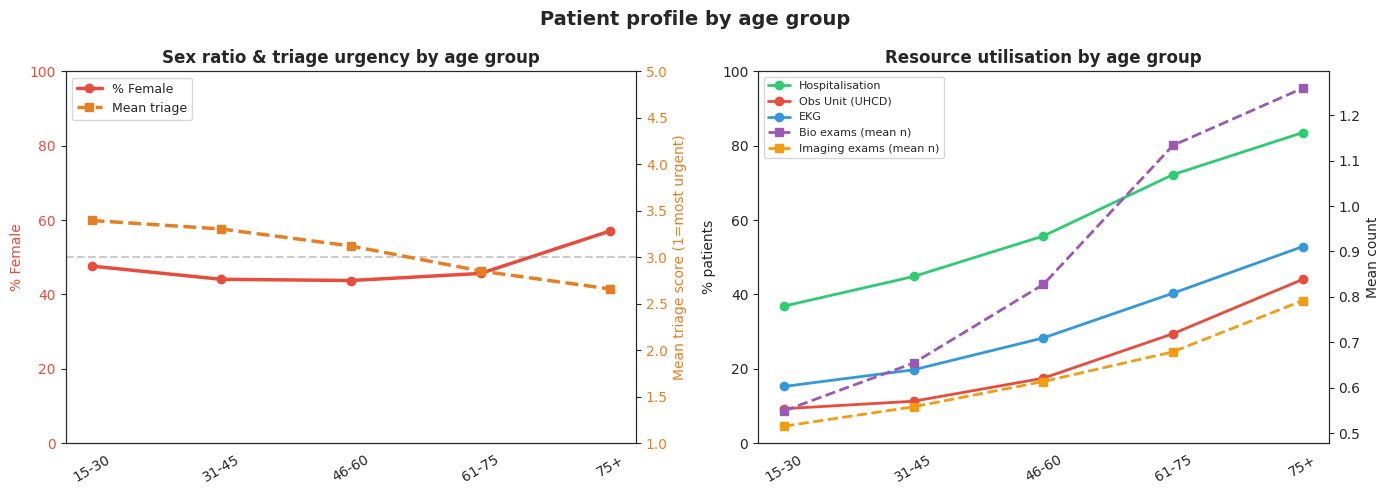

In [120]:
# =========================================================
# FIGURE GROUPÉE — COURBES PAR AGE GROUP
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# ── Panel 1 — % Female + Triage moyen (double axe) ───────
ax1 = axes[0]
ax1_right = ax1.twinx()

pct_female = df.groupby('age_group')['sex'].apply(
    lambda x: (x == 'F').mean() * 100
)
triage_age = df.groupby('age_group')['triage'].mean()

ax1.plot(pct_female.index, pct_female.values,
         marker='o', color='#e74c3c', linewidth=2.5, label='% Female')
ax1.axhline(50, color='grey', linestyle='--', alpha=0.4)
ax1.set_ylabel('% Female', color='#e74c3c')
ax1.set_ylim(0, 100)
ax1.tick_params(axis='y', labelcolor='#e74c3c')
ax1.tick_params(axis='x', rotation=30)

ax1_right.plot(triage_age.index, triage_age.values,
               marker='s', color='#e67e22', linewidth=2.5,
               linestyle='--', label='Mean triage')
ax1_right.set_ylabel('Mean triage score (1=most urgent)', color='#e67e22')
ax1_right.set_ylim(1, 5)
ax1_right.tick_params(axis='y', labelcolor='#e67e22')

ax1.set_title('Sex ratio & triage urgency by age group', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_right.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# ── Panel 2 — Ressources (plusieurs courbes) ──────────────
resource_vars = {
    'Hospitalisation'        : ('hospitalization', False),
    'Obs Unit (UHCD)'        : ('observation_unit', False),
    'EKG'                    : ('had_ekg', False),
    'Bio exams (mean n)'     : ('bio_exam_count', True),
    'Imaging exams (mean n)' : ('imaging_exam_count', True),
}

colors_res = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6', '#f39c12']

ax2 = axes[1]
ax2_right = ax2.twinx()

for i, (label, (col, is_count)) in enumerate(resource_vars.items()):
    if col not in df.columns:
        continue
    if is_count:
        rates = df.groupby('age_group')[col].mean()
        ax2_right.plot(rates.index, rates.values,
                       marker='s', linestyle='--',
                       color=colors_res[i], linewidth=2, label=label)
    else:
        rates = df.groupby('age_group')[col].apply(
            lambda x: x.astype(int).mean() * 100
        )
        ax2.plot(rates.index, rates.values,
                 marker='o', color=colors_res[i], linewidth=2, label=label)

ax2.set_title('Resource utilisation by age group', fontweight='bold')
ax2.set_ylabel('% patients')
ax2_right.set_ylabel('Mean count')
ax2.set_ylim(0, 100)
ax2.tick_params(axis='x', rotation=30)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_right.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.suptitle('Patient profile by age group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{output_dir}/age_group_curves.png", dpi=200, bbox_inches='tight')
plt.show()

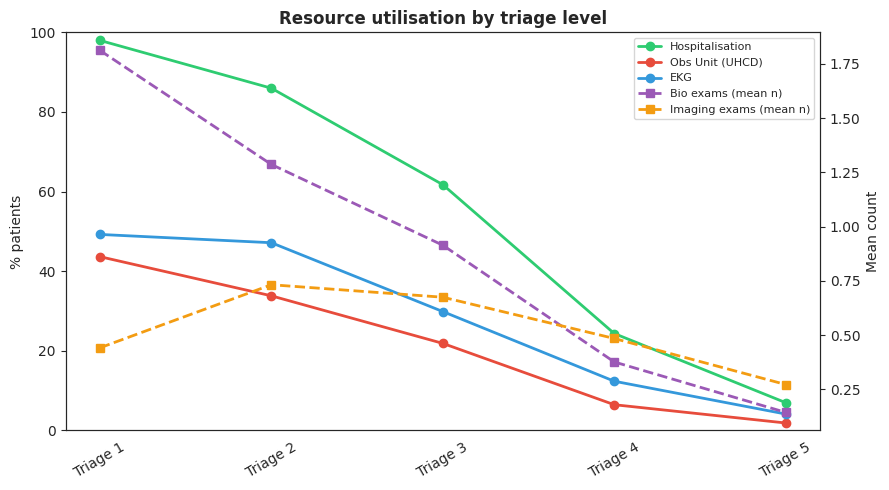

In [121]:
# ── Panel — Ressources par niveau de triage ───────────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax_right = ax.twinx()

resource_vars = {
    'Hospitalisation'        : ('hospitalization', False),
    'Obs Unit (UHCD)'        : ('observation_unit', False),
    'EKG'                    : ('had_ekg', False),
    'Bio exams (mean n)'     : ('bio_exam_count', True),
    'Imaging exams (mean n)' : ('imaging_exam_count', True),
}

colors_res = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6', '#f39c12']

for i, (label, (col, is_count)) in enumerate(resource_vars.items()):
    if col not in df.columns:
        continue
    if is_count:
        rates = df.groupby('triage_label')[col].mean().reindex(triage_order)
        ax_right.plot(rates.index, rates.values,
                      marker='s', linestyle='--',
                      color=colors_res[i], linewidth=2, label=label)
    else:
        rates = df.groupby('triage_label')[col].apply(
            lambda x: x.astype(int).mean() * 100
        ).reindex(triage_order)
        ax.plot(rates.index, rates.values,
                marker='o', color=colors_res[i], linewidth=2, label=label)

ax.set_title('Resource utilisation by triage level', fontweight='bold')
ax.set_ylabel('% patients')
ax_right.set_ylabel('Mean count')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=30)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_right.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(f"{output_dir}/triage_resource_curves.png", dpi=200, bbox_inches='tight')
plt.show()

In [124]:
print(df['bio_exam_count'].describe().round(2))
print(df['imaging_exam_count'].describe().round(2))

count    56784.00
mean         0.82
std          0.83
min          0.00
25%          0.00
50%          1.00
75%          1.00
max          4.00
Name: bio_exam_count, dtype: float64
count    56784.00
mean         0.61
std          0.66
min          0.00
25%          0.00
50%          1.00
75%          1.00
max          5.00
Name: imaging_exam_count, dtype: float64


In [125]:
mask_nothing = (
    (df['is_labo'].astype(int) == 0) &
    (df['has_imaging_any'].astype(int) == 0) &
    (df['had_ekg'].astype(int) == 0) &
    (df['observation_unit'].astype(int) == 0) &
    (df['hospitalization'].astype(int) == 0)
)

n_nothing = mask_nothing.sum()
pct_nothing = n_nothing / len(df) * 100

print(f"Patients with no investigation, no EKG, no obs unit, no hospitalisation : {n_nothing:,} ({pct_nothing:.1f}%)")

Patients with no investigation, no EKG, no obs unit, no hospitalisation : 11,633 (20.5%)


In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ================================================================
# OUTPUT DIR
# ================================================================
output_dir = "Results/Description"
OUTPUT_DIR = output_dir
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ================================================================
# PALETTE
# ================================================================
PALETTE_CAT = [
    '#2c7bb6', '#d7191c', '#1a9641', '#fdae61', '#756bb1',
    '#d94801', '#2ca25f', '#e31a1c', '#636363', '#8c510a',
    '#bf812d', '#74c476', '#9ecae1', '#fc8d59', '#c994c7',
]

# ================================================================
# FREQUENCY TABLE
# ================================================================
def freq_table(series):
    vc  = series.value_counts(dropna=False)
    pct = (vc / len(series) * 100).round(1)
    df_out = pd.DataFrame({'Category': vc.index.astype(str), 'N': vc.values, '%': pct.values})
    df_out['N (%)'] = df_out['N'].astype(str) + ' (' + df_out['%'].astype(str) + '%)'
    return df_out[['Category', 'N', '%', 'N (%)']]

tbl_cat   = freq_table(df['complaint_category'])
tbl_top10 = (
    df['chief_complaint_en']
    .value_counts(dropna=False)
    .head(10)
    .reset_index()
    .rename(columns={'chief_complaint_en': 'Chief complaint', 'count': 'N'})
)
tbl_top10['%']     = (tbl_top10['N'] / len(df) * 100).round(1)
tbl_top10['N (%)'] = tbl_top10['N'].astype(str) + ' (' + tbl_top10['%'].astype(str) + '%)'

# ================================================================
# HTML TABLE
# ================================================================
def df_to_html_table(df_in, title, subtitle=''):
    header_cells = ''.join(f'<th>{c}</th>' for c in df_in.columns)
    rows = ''
    for i, row in df_in.iterrows():
        tr_class = 'even' if i % 2 == 0 else 'odd'
        cells = ''.join(f'<td>{v}</td>' for v in row)
        rows += f'<tr class="{tr_class}">{cells}</tr>\n'
    sub_html = f'<p class="subtitle">{subtitle}</p>' if subtitle else ''
    return f'''
    <div class="table-block">
      <h2>{title}</h2>
      {sub_html}
      <table>
        <thead><tr>{header_cells}</tr></thead>
        <tbody>{rows}</tbody>
      </table>
    </div>'''

html_t1 = df_to_html_table(tbl_cat[['Category', 'N', 'N (%)']],
                            'complaint_category', f'N = {len(df):,} visits')
html_t3 = df_to_html_table(tbl_top10[['Chief complaint', 'N', 'N (%)']],
                            'Top 10 chief complaints (chief_complaint_en)',
                            f'Out of {df["chief_complaint_en"].nunique()} unique complaints')

html_full = f'''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Complaint Description</title>
<style>
  @import url('https://fonts.googleapis.com/css2?family=IBM+Plex+Sans:wght@300;400;600&family=IBM+Plex+Mono&display=swap');
  *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{ font-family: 'IBM Plex Sans', sans-serif; background: #f7f8fa;
          color: black; padding: 40px 60px; font-size: 13px; }}
  h1 {{ font-size: 22px; font-weight: 600; margin-bottom: 4px; color: black;
        border-bottom: 3px solid #2c7bb6; padding-bottom: 8px; }}
  .meta {{ font-size: 11px; color: #555; margin-bottom: 36px; }}
  .table-block {{ margin-bottom: 48px; }}
  .table-block h2 {{ font-size: 14px; font-weight: 600; color: #2c7bb6;
                     margin-bottom: 4px; font-family: 'IBM Plex Mono', monospace; }}
  .subtitle {{ font-size: 11px; color: #555; margin-bottom: 10px; }}
  table {{ width: 100%; border-collapse: collapse;
           box-shadow: 0 1px 4px rgba(0,0,0,0.08);
           background: white; border-radius: 6px; overflow: hidden; }}
  thead tr {{ background: #1a1a2e; color: white; }}
  th {{ padding: 10px 14px; text-align: left; font-size: 11px;
        font-weight: 600; letter-spacing: 0.06em; text-transform: uppercase; }}
  td {{ padding: 8px 14px; font-size: 12px; color: black; }}
  tr.even {{ background: #f0f4fa; }}
  tr.odd  {{ background: white; }}
  tr:hover {{ background: #dbeafe; transition: background 0.15s; }}
  td:nth-child(2), td:nth-child(3) {{
    font-family: 'IBM Plex Mono', monospace; font-size: 11px; }}
</style>
</head>
<body>
<h1>Chief complaint — descriptive summary</h1>
<p class="meta">Pellegrin Hospital ED · 2022–2023 · N = {len(df):,} visits</p>
{html_t1}
{html_t3}
</body>
</html>'''

html_path = os.path.join(OUTPUT_DIR, 'complaint_description.html')
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(html_full)
print(f"Saved: {html_path}")

# ================================================================
# BAR PLOT FUNCTION
# ================================================================
def barplot_category(series, title, fname, top_n=None):
    vc     = series.value_counts(dropna=False)
    if top_n:
        vc = vc.head(top_n)

    labels = vc.index.astype(str).tolist()   # ordre décroissant
    values = vc.values
    pcts   = values / len(series) * 100
    colors = [PALETTE_CAT[i % len(PALETTE_CAT)] for i in range(len(labels))]

    # figure large pour avoir la place pour la légende à droite
    fig, ax = plt.subplots(
        figsize=(13, max(5, len(labels) * 0.52)),
        facecolor='white'
    )
    ax.set_facecolor('white')

    # barres — on inverse pour avoir le plus grand en haut
    bars = ax.barh(
        range(len(labels)),          # positions numériques
        values[::-1],                # valeurs inversées (grand en haut)
        color=colors[::-1],
        edgecolor='white', linewidth=0.5, height=0.65
    )

    # labels Y = noms des catégories
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels[::-1], fontsize=10, color='black')

    # annotations N et %
    for bar, pct in zip(bars, pcts[::-1]):
        w = bar.get_width()
        ax.text(
            w + max(values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{w:,.0f}  ({pct:.1f}%)',
            va='center', ha='left', fontsize=9,
            color='black', fontfamily='monospace'
        )

    ax.set_xlabel('Number of visits', fontsize=11, labelpad=10, color='black')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=14, color='black')
    ax.set_xlim(0, max(values) * 1.25)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color('black')
    ax.tick_params(axis='x', labelsize=9, colors='black')
    ax.tick_params(axis='y', length=0)
    ax.xaxis.grid(True, linestyle='--', alpha=0.3, color='#aaa')
    ax.set_axisbelow(True)

    # # ── LÉGENDE à droite du graphe ──
    # legend_patches = [
    #     mpatches.Patch(facecolor=colors[i], edgecolor='white', label=labels[i])
    #     for i in range(len(labels))
    # ]
    # ax.legend(
    #     handles=legend_patches,
    #     title='Category',
    #     title_fontsize=9,
    #     fontsize=8,
    #     bbox_to_anchor=(1.02, 1),   # à droite, en haut
    #     loc='upper left',
    #     framealpha=0.95,
    #     edgecolor='#ccc',
    #     labelcolor='black',
    # )

    # footnote
    ax.text(
        0.99, -0.05,
        f'N = {len(series):,} visits' + (f' · top {top_n}' if top_n else ''),
        transform=ax.transAxes, ha='right', fontsize=8, color='black'
    )

    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, fname)
    # bbox_inches='tight' inclut la légende extérieure dans le PNG
    plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"Saved: {out}")

# ================================================================
# GENERATE PLOTS
# ================================================================
barplot_category(
    df['complaint_category'],
    'Distribution of complaint categories',
    'barplot_complaint_category.png'
)

barplot_category(
    df['chief_complaint_en'],
    'Top 10 chief complaints (chief_complaint_en)',
    'barplot_chief_complaint_en_top10.png',
    top_n=10
)

print("\nAll outputs saved.")

Saved: Results/Description/complaint_description.html
Saved: Results/Description/barplot_complaint_category.png
Saved: Results/Description/barplot_chief_complaint_en_top10.png

All outputs saved.
